<a href="https://colab.research.google.com/github/LatiefDataVisionary/DeepRice-Classifier-CNN/blob/main/Notebook_KP_Fixx_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **BAB 1: PERSIAPAN LINGKUNGAN DAN IMPOR PUSTAKA (*Environment Setup and Library Imports*)**


In [1]:
# Library Pemuatan Data
from google.colab import drive
drive.mount('/content/drive')

# Library Manipulasi Data
import pandas as pd
import numpy as np
import datetime as dt
from datetime import timedelta
import re

# Library Visualisasi Data
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Library Machine Learning (K-Means)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import scipy.stats as stats

# Pengaturan Konfigurasi Visual
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

# Konfigurasi parameter global untuk ukuran, resolusi (DPI), dan tipografi grafik Matplotlib.
# Pengaturan ini memastikan seluruh grafik yang diekspor memiliki standar kualitas publikasi/skripsi akademis.
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

Mounted at /content/drive


## **BAB 2: PEMUATAN DATA MENTAH (*RAW DATA LOADING*)**


### **2.1: Pembacaan File Data (*Data File Reading*)**


In [2]:
# Path file dataset di Google Drive
file_nov_jan = '/content/drive/MyDrive/Dataset/Data KP/data petcare Nov25-Jan26.xlsx'
file_feb = '/content/drive/MyDrive/Dataset/Data KP/data petcare-feb 2026.xlsx'

### **2.2: Fungsi Tinjauan Cepat Struktur Data (*Quick Data Structure Overview Function*)**

In [3]:
def data_overview(df, df_name="Dataset"):
  print(f"\n{'=' * 20} TINJAUAN DATA: {df_name.upper()} {'=' * 20}")

  # 1. Menampilkan cuplikan 5 baris pertama data untuk memastikan struktur kolom benar
  print(f"Tinjauan 5 baris teratas (Head) dari {df_name}:")
  display(df.head())

  # 2. Menampilkan cuplikan 5 baris terakhir data
  print(f"\nTinjauan 5 baris terbawah (Tail) dari {df_name}:")
  display(df.tail())

  # 3. Menampilkan informasi komprehensif mengenai tipe data (Dtype) dan deteksi nilai Null awal
  print(f"\nInformasi Struktur DataFrame ({df_name}.info):")
  print("=" * 70)
  df.info()
  print("=" * 70)

  # 4. Melakukan kalkulasi awal jumlah nilai kosong (Missing Values) absolut dan persentase pada setiap kolom
  print(f"\nJumlah dan Persentase Nilai Kosong Per Kolom di {df_name}:")
  print("-" * 40)
  missing_values_count = df.isnull().sum()
  missing_values_percent = (df.isnull().sum() / len(df) * 100).round(2)

  # Hanya menampilkan kolom yang memiliki nilai kosong (jumlah > 0)
  kolom_kosong = missing_values_count[missing_values_count > 0]
  if not kolom_kosong.empty:
      missing_info = pd.DataFrame({
          'Total Kosong (Baris)': kolom_kosong,
          'Persentase Kosong (%)': missing_values_percent[missing_values_percent > 0]
      })
      display(missing_info)
  else:
      print("[INFO] Tidak ditemukan nilai kosong pada tahap pemuatan awal. Data tampak solid!")

  # 5. Cek Duplikasi
  print(f"\n[5] Cek Duplikasi Data di {df_name}:")
  print("-" * 40)
  total_duplicates = df.duplicated().sum()

  if total_duplicates > 0:
      print(f"-> Ditemukan {total_duplicates:,} baris data duplikat.")
      print("-> Berikut adalah 5 baris duplikat pertama:")
      display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head())
  else:
      print("[INFO] Tidak ditemukan baris data duplikat. Data bersih!")
  print(f"\n{'=' * 20} AKHIR TINJAUAN DATA: {df_name.upper()} {'=' * 20}\n")

### **2.3: Melakukan penggabungan (*Concatenation*) kedua dataset menjadi satu DataFrame utama**

In [4]:
try:
    # Memuat dataset bulan November hingga Januari ke dalam DataFrame
    print(f"Sedang memuat dataset: '{file_nov_jan}'...")
    df_nov_jan = pd.read_excel(file_nov_jan)

    # Memuat dataset bulan Februari ke dalam DataFrame
    print(f"Sedang memuat dataset: '{file_feb}'...")
    df_feb = pd.read_excel(file_feb)

    # Melakukan penggabungan (Concatenation) kedua dataset menjadi satu DataFrame utama.
    # Parameter ignore_index=True memastikan nomor indeks disusun ulang secara berurutan dari 0.
    df_raw = pd.concat([df_nov_jan, df_feb], ignore_index=True)

    print("\n[SUKSES] Kedua dataset berhasil dibaca dan digabungkan menjadi objek 'df_raw'!")
    print(f"-> Total baris data gabungan   : {df_raw.shape[0]:,} baris")
    print(f"-> Total kolom data gabungan   : {df_raw.shape[1]} kolom")

except FileNotFoundError as e:
    print(f"\n[ERROR FATAL] File dataset tidak ditemukan. Pastikan Anda telah mengunggah file \n'{file_nov_jan}' dan '{file_feb}' ke panel Files di sebelah kiri Google Colab.")
    print(f"Detail error: {e}")

Sedang memuat dataset: '/content/drive/MyDrive/Dataset/Data KP/data petcare Nov25-Jan26.xlsx'...
Sedang memuat dataset: '/content/drive/MyDrive/Dataset/Data KP/data petcare-feb 2026.xlsx'...

[SUKSES] Kedua dataset berhasil dibaca dan digabungkan menjadi objek 'df_raw'!
-> Total baris data gabungan   : 2,066 baris
-> Total kolom data gabungan   : 10 kolom


### **2.4: Tinjauan Cepat Struktur Data Dataset Bulan November 2025 - Januari 2026**

In [5]:
data_overview(df_nov_jan, "Dataset November - Januari")


==================== TINJAUAN DATA: DATASET NOVEMBER - JANUARI ====================
Tinjauan 5 baris teratas (Head) dari Dataset November - Januari:


,TGL. INVOICE,PASIEN,SPESIES,RAS,PEMILIK,POLIKLINIK,TOTAL TAGIHAN (Rp),STATUS TAGIHAN
0,2025-11-01,KIMMY,Kucing,Mixed Breed,PUTRA PANGESTU,Poli Grooming,56000.0,Lunas
1,2025-11-01,MIMI,Kucing,Mixed Breed,SANDER EVERASE,Poli Grooming,165000.0,Lunas
2,2025-11-01,MIMI,Kucing,Mixed Breed,SANDER EVERASE,Poli Umum,1484000.0,Lunas
3,2025-11-01,Sopyan,Kucing,NaN,Trifia Dewi,Poli Umum,110000.0,Lunas
4,2025-11-01,Furry,Kucing,Bengal,Trifia Dewi,Poli Umum,110000.0,Lunas



Tinjauan 5 baris terbawah (Tail) dari Dataset November - Januari:


,TGL. INVOICE,PASIEN,SPESIES,RAS,PEMILIK,POLIKLINIK,TOTAL TAGIHAN (Rp),STATUS TAGIHAN
1549,2026-01-31,syepy,Kucing,Persia,sabila,Poli Umum,140000.0,Lunas
1550,2026-01-31,mechil,Kucing,Mixed Breed,lindu cita,Rawat Inap,340000.0,Lunas
1551,2026-01-31,Ridwania,Kucing,Unknown,Dani,Poli Umum,85000.0,Lunas
1552,2026-01-31,Udin,Kucing,Mixed Breed,Tommy Rinda,Poli Umum,85000.0,Lunas
1553,2026-01-31,Feline,Kucing,Mixed Breed,Tommy Rinda,Poli Umum,85000.0,Lunas



Informasi Struktur DataFrame (Dataset November - Januari.info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1554 entries, 0 to 1553
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TGL. INVOICE        1554 non-null   object 
 1   PASIEN              1554 non-null   object 
 2   SPESIES             1554 non-null   object 
 3   RAS                 1385 non-null   object 
 4   PEMILIK             1554 non-null   object 
 5   POLIKLINIK          1554 non-null   object 
 6   TOTAL TAGIHAN (Rp)  1554 non-null   float64
 7   STATUS TAGIHAN      1554 non-null   object 
dtypes: float64(1), object(7)
memory usage: 97.3+ KB

Jumlah dan Persentase Nilai Kosong Per Kolom di Dataset November - Januari:
----------------------------------------


,Total Kosong (Baris),Persentase Kosong (%)
RAS,169,10.88



[5] Cek Duplikasi Data di Dataset November - Januari:
----------------------------------------
[INFO] Tidak ditemukan baris data duplikat. Data bersih!

==================== AKHIR TINJAUAN DATA: DATASET NOVEMBER - JANUARI ====================



### **2.5: Tinjauan Cepat Struktur Data Dataset Bulan Februari 2026**

In [6]:
data_overview(df_feb, "Dataset Februari")


==================== TINJAUAN DATA: DATASET FEBRUARI ====================
Tinjauan 5 baris teratas (Head) dari Dataset Februari:


,TGL. INVOICE,PASIEN,SPESIES,RAS,PEMILIK,POLIKLINIK,TOTAL TAGIHAN (Rp),TGL. TRANSAKSI,TGL. LUNAS,STATUS TAGIHAN
0,2026-02-28,Queen,Kucing,NaN,Reny Clara,Poli Umum,54000.0,2026-02-28 16:42:58,2026-02-28 17:02:32,Lunas
1,2026-02-28,King,Kucing,Persia,Reny Clara,Poli Umum,54000.0,2026-02-28 16:40:41,2026-02-28 17:02:39,Lunas
2,2026-02-28,BOMA,Kucing,Mixed Breed,RIZKY KARISMA,Poli Umum,420000.0,2026-02-28 16:37:26,2026-02-28 18:44:25,Lunas
3,2026-02-28,BOMA,Kucing,Mixed Breed,RIZKY KARISMA,Poli Grooming,85000.0,2026-02-28 15:50:36,2026-02-28 18:43:59,Lunas
4,2026-02-28,King,Kucing,Persia,Reny Clara,Poli Grooming,63000.0,2026-02-28 15:23:52,2026-02-28 17:03:19,Lunas



Tinjauan 5 baris terbawah (Tail) dari Dataset Februari:


,TGL. INVOICE,PASIEN,SPESIES,RAS,PEMILIK,POLIKLINIK,TOTAL TAGIHAN (Rp),TGL. TRANSAKSI,TGL. LUNAS,STATUS TAGIHAN
507,2026-02-01,Heidi,Anjing,French Bulldog,Ao,Poli Grooming,85000.0,2026-02-01 14:22:17,2026-02-01 17:05:53,Lunas
508,2026-02-01,Lulu,Anjing,Mixed Breed,Ao,Poli Grooming,85000.0,2026-02-01 14:22:10,2026-02-01 17:05:23,Lunas
509,2026-02-01,SOJU,Anjing,Poodle,Rosa,Poli Umum,125000.0,2026-02-01 12:41:36,2026-02-01 12:46:08,Lunas
510,2026-02-01,Alex Farentheit,Kucing,Persia,Twista Gilang,Rawat Inap,786000.0,2026-02-01 11:29:46,2026-02-01 13:43:03,Lunas
511,2026-02-01,soli,Anjing,Poodle,esti dwi susilo,Poli Umum,200000.0,2026-02-01 11:13:05,2026-02-01 19:53:20,Lunas



Informasi Struktur DataFrame (Dataset Februari.info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TGL. INVOICE        512 non-null    object 
 1   PASIEN              512 non-null    object 
 2   SPESIES             512 non-null    object 
 3   RAS                 468 non-null    object 
 4   PEMILIK             512 non-null    object 
 5   POLIKLINIK          512 non-null    object 
 6   TOTAL TAGIHAN (Rp)  512 non-null    float64
 7   TGL. TRANSAKSI      512 non-null    object 
 8   TGL. LUNAS          512 non-null    object 
 9   STATUS TAGIHAN      512 non-null    object 
dtypes: float64(1), object(9)
memory usage: 40.1+ KB

Jumlah dan Persentase Nilai Kosong Per Kolom di Dataset Februari:
----------------------------------------


,Total Kosong (Baris),Persentase Kosong (%)
RAS,44,8.59



[5] Cek Duplikasi Data di Dataset Februari:
----------------------------------------
[INFO] Tidak ditemukan baris data duplikat. Data bersih!

==================== AKHIR TINJAUAN DATA: DATASET FEBRUARI ====================



### **2.6: Tinjauan Cepat Struktur Data (*Quick Data Structure Overview*)**

In [7]:
data_overview(df_raw, "Dataset Gabungan (df_raw)")


==================== TINJAUAN DATA: DATASET GABUNGAN (DF_RAW) ====================
Tinjauan 5 baris teratas (Head) dari Dataset Gabungan (df_raw):


,TGL. INVOICE,PASIEN,SPESIES,RAS,PEMILIK,POLIKLINIK,TOTAL TAGIHAN (Rp),STATUS TAGIHAN,TGL. TRANSAKSI,TGL. LUNAS
0,2025-11-01,KIMMY,Kucing,Mixed Breed,PUTRA PANGESTU,Poli Grooming,56000.0,Lunas,NaN,NaN
1,2025-11-01,MIMI,Kucing,Mixed Breed,SANDER EVERASE,Poli Grooming,165000.0,Lunas,NaN,NaN
2,2025-11-01,MIMI,Kucing,Mixed Breed,SANDER EVERASE,Poli Umum,1484000.0,Lunas,NaN,NaN
3,2025-11-01,Sopyan,Kucing,NaN,Trifia Dewi,Poli Umum,110000.0,Lunas,NaN,NaN
4,2025-11-01,Furry,Kucing,Bengal,Trifia Dewi,Poli Umum,110000.0,Lunas,NaN,NaN



Tinjauan 5 baris terbawah (Tail) dari Dataset Gabungan (df_raw):


,TGL. INVOICE,PASIEN,SPESIES,RAS,PEMILIK,POLIKLINIK,TOTAL TAGIHAN (Rp),STATUS TAGIHAN,TGL. TRANSAKSI,TGL. LUNAS
2061,2026-02-01,Heidi,Anjing,French Bulldog,Ao,Poli Grooming,85000.0,Lunas,2026-02-01 14:22:17,2026-02-01 17:05:53
2062,2026-02-01,Lulu,Anjing,Mixed Breed,Ao,Poli Grooming,85000.0,Lunas,2026-02-01 14:22:10,2026-02-01 17:05:23
2063,2026-02-01,SOJU,Anjing,Poodle,Rosa,Poli Umum,125000.0,Lunas,2026-02-01 12:41:36,2026-02-01 12:46:08
2064,2026-02-01,Alex Farentheit,Kucing,Persia,Twista Gilang,Rawat Inap,786000.0,Lunas,2026-02-01 11:29:46,2026-02-01 13:43:03
2065,2026-02-01,soli,Anjing,Poodle,esti dwi susilo,Poli Umum,200000.0,Lunas,2026-02-01 11:13:05,2026-02-01 19:53:20



Informasi Struktur DataFrame (Dataset Gabungan (df_raw).info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2066 entries, 0 to 2065
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TGL. INVOICE        2066 non-null   object 
 1   PASIEN              2066 non-null   object 
 2   SPESIES             2066 non-null   object 
 3   RAS                 1853 non-null   object 
 4   PEMILIK             2066 non-null   object 
 5   POLIKLINIK          2066 non-null   object 
 6   TOTAL TAGIHAN (Rp)  2066 non-null   float64
 7   STATUS TAGIHAN      2066 non-null   object 
 8   TGL. TRANSAKSI      512 non-null    object 
 9   TGL. LUNAS          512 non-null    object 
dtypes: float64(1), object(9)
memory usage: 161.5+ KB

Jumlah dan Persentase Nilai Kosong Per Kolom di Dataset Gabungan (df_raw):
----------------------------------------


,Total Kosong (Baris),Persentase Kosong (%)
RAS,213,10.31
TGL. TRANSAKSI,1554,75.22
TGL. LUNAS,1554,75.22



[5] Cek Duplikasi Data di Dataset Gabungan (df_raw):
----------------------------------------
[INFO] Tidak ditemukan baris data duplikat. Data bersih!

==================== AKHIR TINJAUAN DATA: DATASET GABUNGAN (DF_RAW) ====================



## **BAB 3: PEMAHAMAN DAN PEMBERSIHAN DATA AWAL (*Data Understanding and Initial Cleaning*)**


### **3.1: Penghapusan Kolom Redundan dan Filter Data Valid**


In [8]:
print("[1] Memulai pembersihan tahap awal...")
print(f"Total baris awal: {df_raw.shape[0]}")

# Menghapus kolom 'Unnamed: 0', karena merupakan artefak index dari file sumber
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop(columns=['Unnamed: 0'])
    print("- Kolom 'Unnamed: 0' berhasil dihapus.")

# Memastikan kita hanya mengambil transaksi yang sudah lunas untuk perhitungan Monetary yang valid
# Menggunakan str.strip() dan str.lower() untuk mengantisipasi spasi ekstra atau perbedaan huruf besar/kecil
if 'STATUS TAGIHAN' in df_raw.columns:
    # Buat salinan sementara dari kolom STATUS TAGIHAN yang sudah dibersihkan untuk perhitungan
    cleaned_status = df_raw['STATUS TAGIHAN'].astype(str).str.strip().str.lower()

    total_initial_rows = df_raw.shape[0]
    lunas_count = (cleaned_status == 'lunas').sum()
    belum_lunas_count = total_initial_rows - lunas_count
    lunas_percentage = (lunas_count / total_initial_rows) * 100 if total_initial_rows > 0 else 0
    belum_lunas_percentage = (belum_lunas_count / total_initial_rows) * 100 if total_initial_rows > 0 else 0

    # Buat tabel ringkasan untuk tampilan
    summary_data = {
        'Status': ['Total Transaksi Awal', 'Transaksi Lunas', 'Transaksi Belum Lunas'],
        'Jumlah (Baris)': [total_initial_rows, lunas_count, belum_lunas_count],
        'Persentase (%)': [100.00, round(lunas_percentage, 2), round(belum_lunas_percentage, 2)]
    }
    summary_df = pd.DataFrame(summary_data)

    print("\n--- Ringkasan Status Tagihan Sebelum Filter ---")
    display(summary_df.set_index('Status'))
    print("\n")

    # Tambahkan kode ini untuk menampilkan sampel transaksi 'belum lunas'
    if belum_lunas_count > 0:
        print("--- 10 Baris Sampel Transaksi Belum Lunas ---")
        # Filter df_raw asli (belum difilter) berdasarkan cleaned_status
        display(df_raw[cleaned_status != 'lunas'].head(10))
        print("\n")
    else:
        print("[INFO] Tidak ada transaksi dengan status 'Belum Lunas' yang ditemukan pada tahap awal.")
        print("\n")

    # Terapkan pembersihan status dan filter data secara permanen
    df_raw['STATUS TAGIHAN'] = cleaned_status
    df_raw = df_raw[df_raw['STATUS TAGIHAN'] == 'lunas'].copy()
    print("- Filter transaksi diterapkan: Hanya menyimpan data dengan status 'Lunas'.")

print(f"Total baris setelah filter: {df_raw.shape[0]}")

[1] Memulai pembersihan tahap awal...
Total baris awal: 2066

--- Ringkasan Status Tagihan Sebelum Filter ---


,Jumlah (Baris),Persentase (%)
Status,,
Total Transaksi Awal,2066,100.00
Transaksi Lunas,2029,98.21
Transaksi Belum Lunas,37,1.79




--- 10 Baris Sampel Transaksi Belum Lunas ---


,TGL. INVOICE,PASIEN,SPESIES,RAS,PEMILIK,POLIKLINIK,TOTAL TAGIHAN (Rp),STATUS TAGIHAN,TGL. TRANSAKSI,TGL. LUNAS
23,2025-11-02,OVO,Kucing,Mixed Breed,TIKA HASDINI,Poli Grooming,56000.0,Proses,NaN,NaN
112,2025-11-08,Cita,Kucing,Unknown,Dea Elmira,Poli Umum,40000.0,Belum Lunas,NaN,NaN
129,2025-11-09,Tere,Anjing,Chihuahua,ANITA SUSANTI,Poli Umum,120000.0,Belum Lunas,NaN,NaN
233,2025-11-14,ADAM,Kucing,Domestic,Ari Wanti,Poli Umum,170000.0,Proses,NaN,NaN
234,2025-11-14,Guning,Kucing,NaN,Ari Wanti,Poli Umum,85000.0,Proses,NaN,NaN
243,2025-11-14,ADAM,Kucing,Domestic,Ari Wanti,Poli Grooming,240000.0,Proses,NaN,NaN
266,2025-11-16,CASAVA,Anjing,Golden Retriever,nina,Poli Umum,1175000.0,Belum Lengkap,NaN,NaN
327,2025-11-19,PUTIH,Kucing,Domestic,Robin,Poli Umum,150000.0,Proses,NaN,NaN
335,2025-11-19,PUTIH,Kucing,Domestic,Robin,Poli Grooming,70000.0,Proses,NaN,NaN
386,2025-11-24,TAMPAN,Kucing,Domestic,NARULITA,Poli Umum,540573.0,Proses,NaN,NaN




- Filter transaksi diterapkan: Hanya menyimpan data dengan status 'Lunas'.
Total baris setelah filter: 2029


### **3.2: Penyatuan dan Standardisasi Kolom Waktu**


In [9]:
print("[AUDIT DATA] Memeriksa Penyelarasan Tanggal Transaksi...\n")

# 1. Menyiapkan metrik kelengkapan
total_rows = len(df_raw)
inv_terisi = df_raw['TGL. INVOICE'].notnull().sum()
tra_terisi = df_raw['TGL. TRANSAKSI'].notnull().sum()

# 2. Analisis Sinkronisasi (Hanya untuk baris yang punya kedua data)
both_not_null = df_raw[df_raw['TGL. INVOICE'].notnull() & df_raw['TGL. TRANSAKSI'].notnull()]
sama_persis = (both_not_null['TGL. INVOICE'].astype(str) == both_not_null['TGL. TRANSAKSI'].astype(str)).sum()
berbeda_nilai = len(both_not_null) - sama_persis

# 3. Visualisasi Tabel Kelengkapan yang Lebih Manusiawi
summary_quality = pd.DataFrame({
    'Informasi': ['Total Seluruh Transaksi', 'Data Tanggal Invoice Tersedia', 'Data Tanggal Transaksi Tersedia'],
    'Jumlah': [f"{total_rows:,} Baris", f"{inv_terisi:,} Baris", f"{tra_terisi:,} Baris"],
    'Tingkat Kelengkapan': ['100%', f"{(inv_terisi/total_rows*100):.1f}%", f"{(tra_terisi/total_rows*100):.1f}%"]
})

print("--- LAPORAN 1: KELENGKAPAN SUMBER DATA ---")
display(summary_quality.set_index('Informasi'))

# 4. Tabel Sinkronisasi Antar Kolom
sync_report = pd.DataFrame({
    'Status Sinkronisasi': ['Total Baris Pembanding', 'Data Sesuai (Match)', 'Data Berbeda (Mismatch)'],
    'Jumlah Baris': [len(both_not_null), sama_persis, berbeda_nilai],
    'Persentase': ["100%", f"{(sama_persis/len(both_not_null)*100 if len(both_not_null) > 0 else 0):.1f}%", f"{(berbeda_nilai/len(both_not_null)*100 if len(both_not_null) > 0 else 0):.1f}%"]
})

print("\n--- LAPORAN 2: ANALISIS PENYELARASAN TANGGAL ---")
display(sync_report.set_index('Status Sinkronisasi'))

# 5. Interpretasi Bisnis untuk User
print("\n" + "="*70)
print("KESIMPULAN AUDIT UNTUK LAPORAN:")
print("-"*70)
if berbeda_nilai > 0:
    print(f"[!] Terdeteksi {berbeda_nilai} baris dengan format tanggal berbeda antara kolom Invoice dan Transaksi.")
    print("[*] PENJELASAN: Hal ini WAJAR karena data Februari memiliki detail jam (timestamp) sementara")
    print("    data Nov-Jan hanya tanggal saja. Sistem akan melakukan 'Harmonisasi' pada tahap berikutnya")
    print("    untuk menyatukan kedua kolom ini menjadi satu standar tanggal yang valid.")
else:
    print("[OK] Semua data tanggal sudah selaras dan siap digunakan.")
print("="*70)

[AUDIT DATA] Memeriksa Penyelarasan Tanggal Transaksi...

--- LAPORAN 1: KELENGKAPAN SUMBER DATA ---


,Jumlah,Tingkat Kelengkapan
Informasi,,
Total Seluruh Transaksi,"2,029 Baris",100%
Data Tanggal Invoice Tersedia,"2,029 Baris",100.0%
Data Tanggal Transaksi Tersedia,501 Baris,24.7%



--- LAPORAN 2: ANALISIS PENYELARASAN TANGGAL ---


,Jumlah Baris,Persentase
Status Sinkronisasi,,
Total Baris Pembanding,501,100%
Data Sesuai (Match),0,0.0%
Data Berbeda (Mismatch),501,100.0%



KESIMPULAN AUDIT UNTUK LAPORAN:
----------------------------------------------------------------------
[!] Terdeteksi 501 baris dengan format tanggal berbeda antara kolom Invoice dan Transaksi.
[*] PENJELASAN: Hal ini WAJAR karena data Februari memiliki detail jam (timestamp) sementara
    data Nov-Jan hanya tanggal saja. Sistem akan melakukan 'Harmonisasi' pada tahap berikutnya
    untuk menyatukan kedua kolom ini menjadi satu standar tanggal yang valid.


In [10]:
print("[2] Melakukan harmonisasi kolom waktu...")

# Menggabungkan nilai dari 'TGL. INVOICE' dan 'TGL. TRANSAKSI' ke dalam satu kolom baru
# df_raw['TGL. INVOICE'] akan diisi oleh nilai dari 'TGL. TRANSAKSI' jika nilainya kosong (NaN)
if 'TGL. INVOICE' in df_raw.columns and 'TGL. TRANSAKSI' in df_raw.columns:
    df_raw['Tanggal_Transaksi_Gabungan'] = df_raw['TGL. INVOICE'].fillna(df_raw['TGL. TRANSAKSI'])
    print("- Kolom 'TGL. INVOICE' dan 'TGL. TRANSAKSI' berhasil disatukan.")
elif 'TGL. INVOICE' in df_raw.columns:
    df_raw['Tanggal_Transaksi_Gabungan'] = df_raw['TGL. INVOICE']
elif 'TGL. TRANSAKSI' in df_raw.columns:
    df_raw['Tanggal_Transaksi_Gabungan'] = df_raw['TGL. TRANSAKSI']

# Mengonversi kolom gabungan menjadi format datetime Pandas
df_raw['Tanggal_Transaksi_Gabungan'] = pd.to_datetime(df_raw['Tanggal_Transaksi_Gabungan'], errors='coerce')

# Membuang elemen jam, menit, dan detik (menyisakan YYYY-MM-DD saja) untuk perhitungan Recency
df_raw['Tanggal_Transaksi_Gabungan'] = df_raw['Tanggal_Transaksi_Gabungan'].dt.normalize()

# Menghapus baris yang tanggal transaksinya tidak valid atau kosong setelah digabung
df_raw = df_raw.dropna(subset=['Tanggal_Transaksi_Gabungan'])

print("- Format waktu berhasil distandarisasi menjadi YYYY-MM-DD (tanpa jam).")

[2] Melakukan harmonisasi kolom waktu...
- Kolom 'TGL. INVOICE' dan 'TGL. TRANSAKSI' berhasil disatukan.
- Format waktu berhasil distandarisasi menjadi YYYY-MM-DD (tanpa jam).


### **3.3: Seleksi Kolom Esensial dan Penanganan Nilai Kosong**

In [11]:
print("[3] Menyeleksi kolom esensial dan menangani nilai kosong...")

# Mendefinisikan kolom-kolom yang relevan untuk EDA dan ekstraksi fitur RFM
# Sesuaikan nama kolom di bawah ini dengan nama kolom asli di output df_raw.info() Bab 2
kolom_esensial = [
    'Tanggal_Transaksi_Gabungan',
    'PEMILIK',
    'PASIEN',
    'SPESIES',
    'RAS',
    'POLIKLINIK',
    'TOTAL TAGIHAN (Rp)'
]

# Hanya menyimpan kolom yang ada dalam daftar dan membuang sisanya (seperti TGL. LUNAS, dll)
kolom_tersedia = [col for col in kolom_esensial if col in df_raw.columns]
df_clean = df_raw[kolom_tersedia].copy()

# Mengganti nama kolom agar lebih standar dan mudah dipanggil saat coding
df_clean.rename(columns={
    'Tanggal_Transaksi_Gabungan': 'Tanggal_Transaksi',
    'PEMILIK': 'NAMA PELANGGAN',
    'PASIEN': 'NAMA HEWAN',
    'TOTAL TAGIHAN (Rp)': 'TOTAL TAGIHAN'
}, inplace=True)

# Menangani nilai kosong pada kolom kategorikal (mengisi dengan label default)
kolom_kategorikal = ['NAMA HEWAN', 'SPESIES', 'RAS', 'POLIKLINIK']
for col in kolom_kategorikal:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Tidak Diketahui')

# Menghapus baris jika ada nilai kosong pada kolom krusial untuk RFM
kolom_krusial_rfm = ['NAMA PELANGGAN', 'TOTAL TAGIHAN']
df_clean = df_clean.dropna(subset=[col for col in kolom_krusial_rfm if col in df_clean.columns])

print("- Seleksi kolom selesai. Kolom yang tidak relevan telah dibuang.")
print("- Nilai kosong pada data kategorikal telah ditangani.")

[3] Menyeleksi kolom esensial dan menangani nilai kosong...
- Seleksi kolom selesai. Kolom yang tidak relevan telah dibuang.
- Nilai kosong pada data kategorikal telah ditangani.


### **3.4: Pengecekan dan Penghapusan Data Duplikat**


In [12]:
print("[4] Memeriksa duplikasi data pada dataset bersih...")

# Menghitung jumlah baris duplikat identik di seluruh kolom
total_duplikat = df_clean.duplicated().sum()
print(f"Ditemukan {total_duplikat} baris data duplikat.")

if total_duplikat > 0:
    # Menghapus data duplikat dan hanya mempertahankan kemunculan pertama
    df_clean = df_clean.drop_duplicates(keep='first')
    print("- Data duplikat berhasil dihapus.")
else:
    print("- Tidak ada tindakan penghapusan duplikat yang diperlukan.")

print(f"Total baris data saat ini: {df_clean.shape[0]}")

[4] Memeriksa duplikasi data pada dataset bersih...
Ditemukan 0 baris data duplikat.
- Tidak ada tindakan penghapusan duplikat yang diperlukan.
Total baris data saat ini: 2029


### **3.5: Inspeksi Akhir Struktur Data Bersih**


In [13]:
print("[5] Tinjauan Akhir Data Bersih (df_clean):")
print("=" * 70)

# Menampilkan informasi ringkas dataset yang sudah bersih
df_clean.info()
print("=" * 70)

# Verifikasi akhir jumlah nilai kosong
print("\nVerifikasi Nilai Kosong Akhir:")
missing_final = df_clean.isnull().sum()
if missing_final.sum() == 0:
    print("Bersih! Tidak ada nilai kosong tersisa.")
else:
    display(missing_final[missing_final > 0].to_frame(name='Total Kosong'))

print("\nCuplikan 5 baris pertama data bersih:")
display(df_clean.head())

[5] Tinjauan Akhir Data Bersih (df_clean):
<class 'pandas.core.frame.DataFrame'>
Index: 2029 entries, 0 to 2065
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Tanggal_Transaksi  2029 non-null   datetime64[ns]
 1   NAMA PELANGGAN     2029 non-null   object        
 2   NAMA HEWAN         2029 non-null   object        
 3   SPESIES            2029 non-null   object        
 4   RAS                2029 non-null   object        
 5   POLIKLINIK         2029 non-null   object        
 6   TOTAL TAGIHAN      2029 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 126.8+ KB

Verifikasi Nilai Kosong Akhir:
Bersih! Tidak ada nilai kosong tersisa.

Cuplikan 5 baris pertama data bersih:


,Tanggal_Transaksi,NAMA PELANGGAN,NAMA HEWAN,SPESIES,RAS,POLIKLINIK,TOTAL TAGIHAN
0,2025-11-01,PUTRA PANGESTU,KIMMY,Kucing,Mixed Breed,Poli Grooming,56000.0
1,2025-11-01,SANDER EVERASE,MIMI,Kucing,Mixed Breed,Poli Grooming,165000.0
2,2025-11-01,SANDER EVERASE,MIMI,Kucing,Mixed Breed,Poli Umum,1484000.0
3,2025-11-01,Trifia Dewi,Sopyan,Kucing,Tidak Diketahui,Poli Umum,110000.0
4,2025-11-01,Trifia Dewi,Furry,Kucing,Bengal,Poli Umum,110000.0


### **3.6: Penyamaran Data Pribadi (*Data Masking*) dan Pembuatan Kamus Pemetaan**


In [14]:
print("[6] Memulai proses Data Masking dan Pencadangan Identitas Asli...")

# Langkah 1: Menyeragamkan format string untuk mencegah duplikasi akibat salah ketik
df_clean['NAMA PELANGGAN'] = df_clean['NAMA PELANGGAN'].astype(str).str.strip().str.upper()
df_clean['NAMA HEWAN'] = df_clean['NAMA HEWAN'].astype(str).str.strip().str.upper()

# Langkah 2: Membuat kode unik yang konsisten untuk setiap entitas
df_clean['KODE_PELANGGAN'] = 'PLG-' + (df_clean.groupby('NAMA PELANGGAN').ngroup() + 1).astype(str).str.zfill(4)
df_clean['KODE_HEWAN'] = 'HWN-' + (df_clean.groupby('NAMA HEWAN').ngroup() + 1).astype(str).str.zfill(4)

# Langkah 3: Mengekstrak kombinasi unik antara nama asli dan kodenya untuk dijadikan kamus pemetaan
df_mapping_pelanggan = df_clean[['KODE_PELANGGAN', 'NAMA PELANGGAN']].drop_duplicates().sort_values('KODE_PELANGGAN')
df_mapping_hewan = df_clean[['KODE_HEWAN', 'NAMA HEWAN']].drop_duplicates().sort_values('KODE_HEWAN')

# Langkah 4: Mengekspor dan menyimpan kamus pemetaan ke dalam file Excel terpisah
# File ini menjadi dokumen rahasia yang hanya dipegang oleh analis dan pihak manajemen klinik
path_simpan_mapping = 'Kamus_Mapping_Identitas_Klinik.xlsx'

with pd.ExcelWriter(path_simpan_mapping) as writer:
    df_mapping_pelanggan.to_excel(writer, sheet_name='Mapping_Pelanggan', index=False)
    df_mapping_hewan.to_excel(writer, sheet_name='Mapping_Hewan', index=False)

print(f"- Kamus pemetaan berhasil dibuat dan disimpan dengan nama file: {path_simpan_mapping}")

# Langkah 5: Menimpa kolom asli dengan kode samaran di dalam DataFrame utama
df_clean['NAMA PELANGGAN'] = df_clean['KODE_PELANGGAN']
df_clean['NAMA HEWAN'] = df_clean['KODE_HEWAN']

# Langkah 6: Membuang kolom bantuan agar struktur data kembali bersih
df_clean = df_clean.drop(columns=['KODE_PELANGGAN', 'KODE_HEWAN'])

print("- Identitas di data utama (df_clean) telah berhasil disamarkan sepenuhnya.")
print("\nCuplikan 5 baris pertama setelah proses Data Masking:")
display(df_clean.head())

[6] Memulai proses Data Masking dan Pencadangan Identitas Asli...
- Kamus pemetaan berhasil dibuat dan disimpan dengan nama file: Kamus_Mapping_Identitas_Klinik.xlsx
- Identitas di data utama (df_clean) telah berhasil disamarkan sepenuhnya.

Cuplikan 5 baris pertama setelah proses Data Masking:


,Tanggal_Transaksi,NAMA PELANGGAN,NAMA HEWAN,SPESIES,RAS,POLIKLINIK,TOTAL TAGIHAN
0,2025-11-01,PLG-0386,HWN-0292,Kucing,Mixed Breed,Poli Grooming,56000.0
1,2025-11-01,PLG-0440,HWN-0392,Kucing,Mixed Breed,Poli Grooming,165000.0
2,2025-11-01,PLG-0440,HWN-0392,Kucing,Mixed Breed,Poli Umum,1484000.0
3,2025-11-01,PLG-0480,HWN-0568,Kucing,Tidak Diketahui,Poli Umum,110000.0
4,2025-11-01,PLG-0480,HWN-0197,Kucing,Bengal,Poli Umum,110000.0


In [15]:
print("Cuplikan 5 baris data acak (df_clean):")
display(df_clean.sample(7))

Cuplikan 5 baris data acak (df_clean):


,Tanggal_Transaksi,NAMA PELANGGAN,NAMA HEWAN,SPESIES,RAS,POLIKLINIK,TOTAL TAGIHAN
1980,2026-02-08,PLG-0385,HWN-0641,Kucing,Domestic,Poli Grooming,65000.0
881,2025-12-23,PLG-0123,HWN-0157,Kucing,Unknown,Poli Umum,215000.0
2042,2026-02-02,PLG-0435,HWN-0215,Kucing,Domestic,Poli Umum,235000.0
1975,2026-02-08,PLG-0110,HWN-0097,Kucing,Mixed Breed,Poli Umum,515000.0
301,2025-11-17,PLG-0291,HWN-0502,Kucing,Domestic,Poli Umum,340000.0
701,2025-12-11,PLG-0049,HWN-0373,Kucing,Domestic,Poli Umum,155000.0
533,2025-12-03,PLG-0228,HWN-0176,Kucing,Domestic,Poli Umum,111500.0


In [16]:
import random
import pandas as pd

# 1. Mengambil pelanggan berdasarkan jumlah kunjungan yang spesifik
counts = df_clean['NAMA PELANGGAN'].value_counts()

plg_unique = counts[counts == 1].sample(3).index
plg_double = counts[counts == 2].sample(2).index
plg_triple = counts[counts == 3].sample(2).index

# 2. Menggabungkan semua pelanggan terpilih
selected_plg = list(plg_unique) + list(plg_double) + list(plg_triple)
df_sample_manual = df_clean[df_clean['NAMA PELANGGAN'].isin(selected_plg)].copy()

# 3. Fungsi Helper untuk Randomisasi
start_date = df_clean['Tanggal_Transaksi'].min()
end_date = df_clean['Tanggal_Transaksi'].max()
days_range = (end_date - start_date).days

def randomize_data(df):
    new_rows = []
    for _, row in df.iterrows():
        row['TOTAL TAGIHAN'] = random.randrange(50000, 1500000, 5000)
        random_days = random.randint(0, days_range)
        row['Tanggal_Transaksi'] = start_date + pd.Timedelta(days=random_days)
        new_rows.append(row)
    return pd.DataFrame(new_rows)

# Terapkan randomisasi
df_sample_manual = randomize_data(df_sample_manual)

# 4. Urutkan agar rapi (Unique -> Double -> Triple)
df_sample_manual['Freq_Group'] = df_sample_manual.groupby('NAMA PELANGGAN')['NAMA PELANGGAN'].transform('count')
df_sample_manual = df_sample_manual.sort_values(by=['Freq_Group', 'NAMA PELANGGAN', 'Tanggal_Transaksi'])
df_sample_manual = df_sample_manual.drop(columns=['Freq_Group'])

print(f"--- DATA MANUAL (Total: {len(df_sample_manual)} Baris) ---")
print("Komposisi: 3 Unique, 2 Double (4 baris), 2 Triple (6 baris)")
display(df_sample_manual)

--- DATA MANUAL (Total: 13 Baris) ---
Komposisi: 3 Unique, 2 Double (4 baris), 2 Triple (6 baris)


,Tanggal_Transaksi,NAMA PELANGGAN,NAMA HEWAN,SPESIES,RAS,POLIKLINIK,TOTAL TAGIHAN
1239,2025-12-31,PLG-0104,HWN-0450,Kucing,Domestic,Poli Umum,1405000
794,2025-11-20,PLG-0207,HWN-0121,Kucing,Mixed Breed,Poli Umum,770000
684,2025-11-09,PLG-0237,HWN-0622,Anjing,Herder / German Shepherd,Poli Grooming,890000
1972,2025-11-18,PLG-0093,HWN-0007,Kucing,Domestic,Poli Grooming,140000
1421,2025-11-22,PLG-0093,HWN-0007,Kucing,Domestic,Poli Umum,1280000
1830,2025-11-29,PLG-0290,HWN-0002,Kucing,Persia,Poli Umum,1355000
1829,2025-12-06,PLG-0290,HWN-0557,Kucing,Persia,Poli Umum,1025000
385,2025-12-21,PLG-0187,HWN-0101,Kucing,Domestic,Poli Umum,1410000
656,2026-01-11,PLG-0187,HWN-0238,Kucing,Mixed Breed,Poli Umum,295000
309,2026-01-29,PLG-0187,HWN-0101,Kucing,Domestic,Poli Umum,1280000


In [17]:
import random
import pandas as pd

# 1. Mengambil pelanggan berdasarkan jumlah kunjungan yang spesifik
counts = df_clean['NAMA PELANGGAN'].value_counts()

plg_unique = counts[counts == 1].sample(3).index
plg_double = counts[counts == 2].sample(2).index
plg_triple = counts[counts == 3].sample(2).index

# 2. Menggabungkan semua pelanggan terpilih
selected_plg = list(plg_unique) + list(plg_double) + list(plg_triple)
df_sample_manual = df_clean[df_clean['NAMA PELANGGAN'].isin(selected_plg)].copy()

# 3. Fungsi Helper untuk Randomisasi
start_date = df_clean['Tanggal_Transaksi'].min()
end_date = df_clean['Tanggal_Transaksi'].max()
days_range = (end_date - start_date).days

def randomize_data(df):
    new_rows = []
    for _, row in df.iterrows():
        # Randomisasi Total Tagihan (Kelipatan 5000 agar mudah dihitung manual)
        row['TOTAL TAGIHAN'] = random.randrange(50000, 1500000, 5000)
        # Randomisasi Tanggal agar merata di sepanjang rentang data
        random_days = random.randint(0, days_range)
        row['Tanggal_Transaksi'] = start_date + pd.Timedelta(days=random_days)
        new_rows.append(row)
    return pd.DataFrame(new_rows)

# Terapkan randomisasi
df_sample_manual = randomize_data(df_sample_manual)

# 4. Urutkan agar rapi (Unique -> Double -> Triple)
df_sample_manual['Freq_Group'] = df_sample_manual.groupby('NAMA PELANGGAN')['NAMA PELANGGAN'].transform('count')
df_sample_manual = df_sample_manual.sort_values(by=['Freq_Group', 'NAMA PELANGGAN', 'Tanggal_Transaksi'])
df_sample_manual = df_sample_manual.drop(columns=['Freq_Group'])

print(f"--- DATA MANUAL UNTUK LAPORAN (Total: {len(df_sample_manual)} Baris) ---")
print("Komposisi: 3 Unique, 2 Double (4 baris), 2 Triple (6 baris)")
display(df_sample_manual)

--- DATA MANUAL UNTUK LAPORAN (Total: 13 Baris) ---
Komposisi: 3 Unique, 2 Double (4 baris), 2 Triple (6 baris)


,Tanggal_Transaksi,NAMA PELANGGAN,NAMA HEWAN,SPESIES,RAS,POLIKLINIK,TOTAL TAGIHAN
887,2025-12-12,PLG-0109,HWN-0410,Kucing,Domestic,Poli Umum,585000
1080,2026-02-02,PLG-0144,HWN-0386,Anjing,Poodle,Poli Umum,725000
1082,2025-11-02,PLG-0161,HWN-0478,Lainnya,Unknown,Poli Umum,1205000
1806,2026-02-08,PLG-0095,HWN-0117,Kucing,Persia,Poli Umum,510000
1805,2026-02-16,PLG-0095,HWN-0594,Kucing,Persia,Poli Umum,895000
2052,2025-12-15,PLG-0124,HWN-0394,Kucing,Persia,Poli Umum,1180000
1327,2026-02-11,PLG-0124,HWN-0394,Kucing,Persia,Poli Umum,760000
139,2026-01-07,PLG-0331,HWN-0493,Kucing,Mixed Breed,Poli Umum,1345000
1876,2026-02-09,PLG-0331,HWN-0493,Kucing,Mixed Breed,Poli Grooming,430000
140,2026-02-17,PLG-0331,HWN-0028,Kucing,Mixed Breed,Poli Umum,770000


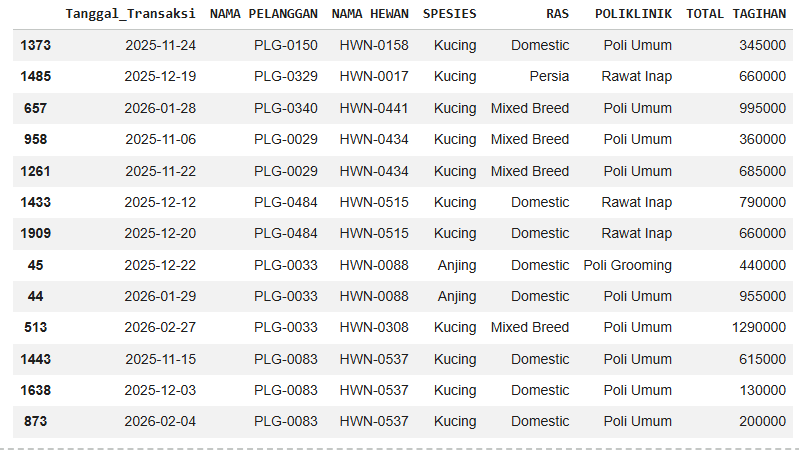

## **BAB 4: ANALISIS DATA EKSPLORATIF (*EXPLORATORY DATA ANALYSIS - EDA*)**


### **4.1: Persiapan Fitur Tambahan untuk Analisis Waktu**

In [18]:
print("[1] Mengekstrak fitur waktu tambahan untuk analisis tren...")

# Membuat salinan data khusus untuk kebutuhan visualisasi EDA agar tidak merusak data utama
df_eda = df_clean.copy()

# Mengekstrak komponen periode (Bulan-Tahun) untuk mempermudah agregasi waktu
df_eda['Bulan_Tahun'] = df_eda['Tanggal_Transaksi'].dt.to_period('M').astype(str)

# Mengekstrak nama hari untuk melihat tren keramaian harian
nama_hari = {0: 'Senin', 1: 'Selasa', 2: 'Rabu', 3: 'Kamis', 4: 'Jumat', 5: 'Sabtu', 6: 'Minggu'}
df_eda['Hari'] = df_eda['Tanggal_Transaksi'].dt.dayofweek.map(nama_hari)

# Menentukan urutan hari agar grafik terurut dengan benar
kategori_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
df_eda['Hari'] = pd.Categorical(df_eda['Hari'], categories=kategori_hari, ordered=True)

print("- Fitur 'Bulan_Tahun' dan 'Hari' berhasil ditambahkan ke DataFrame EDA.")
display(df_eda[['Tanggal_Transaksi', 'Bulan_Tahun', 'Hari']].head())

[1] Mengekstrak fitur waktu tambahan untuk analisis tren...
- Fitur 'Bulan_Tahun' dan 'Hari' berhasil ditambahkan ke DataFrame EDA.


,Tanggal_Transaksi,Bulan_Tahun,Hari
0,2025-11-01,2025-11,Sabtu
1,2025-11-01,2025-11,Sabtu
2,2025-11-01,2025-11,Sabtu
3,2025-11-01,2025-11,Sabtu
4,2025-11-01,2025-11,Sabtu


### **4.2: Analisis Tren Kunjungan dan Pendapatan Bulanan**

[2] Menjalankan analisis mendalam tren dan proporsi bulanan...

--- TABEL ANALISIS PERFORMA & KONTRIBUSI BULANAN ---


,Bulan_Tahun_Label,Total_Kunjungan,Total_Pendapatan,Pertumbuhan_Kunjungan_%,Pertumbuhan_Pendapatan_%,%_Kontribusi_Kunjungan,%_Kontribusi_Pendapatan
0,November 2025,483,"Rp 125,387,158",+nan%,+nan%,23.80%,24.32%
1,December 2025,542,"Rp 119,318,025",+12.22%,-4.84%,26.71%,23.15%
2,January 2026,503,"Rp 152,730,420",-7.20%,+28.00%,24.79%,29.63%
3,February 2026,501,"Rp 118,057,726",-0.40%,-22.70%,24.69%,22.90%


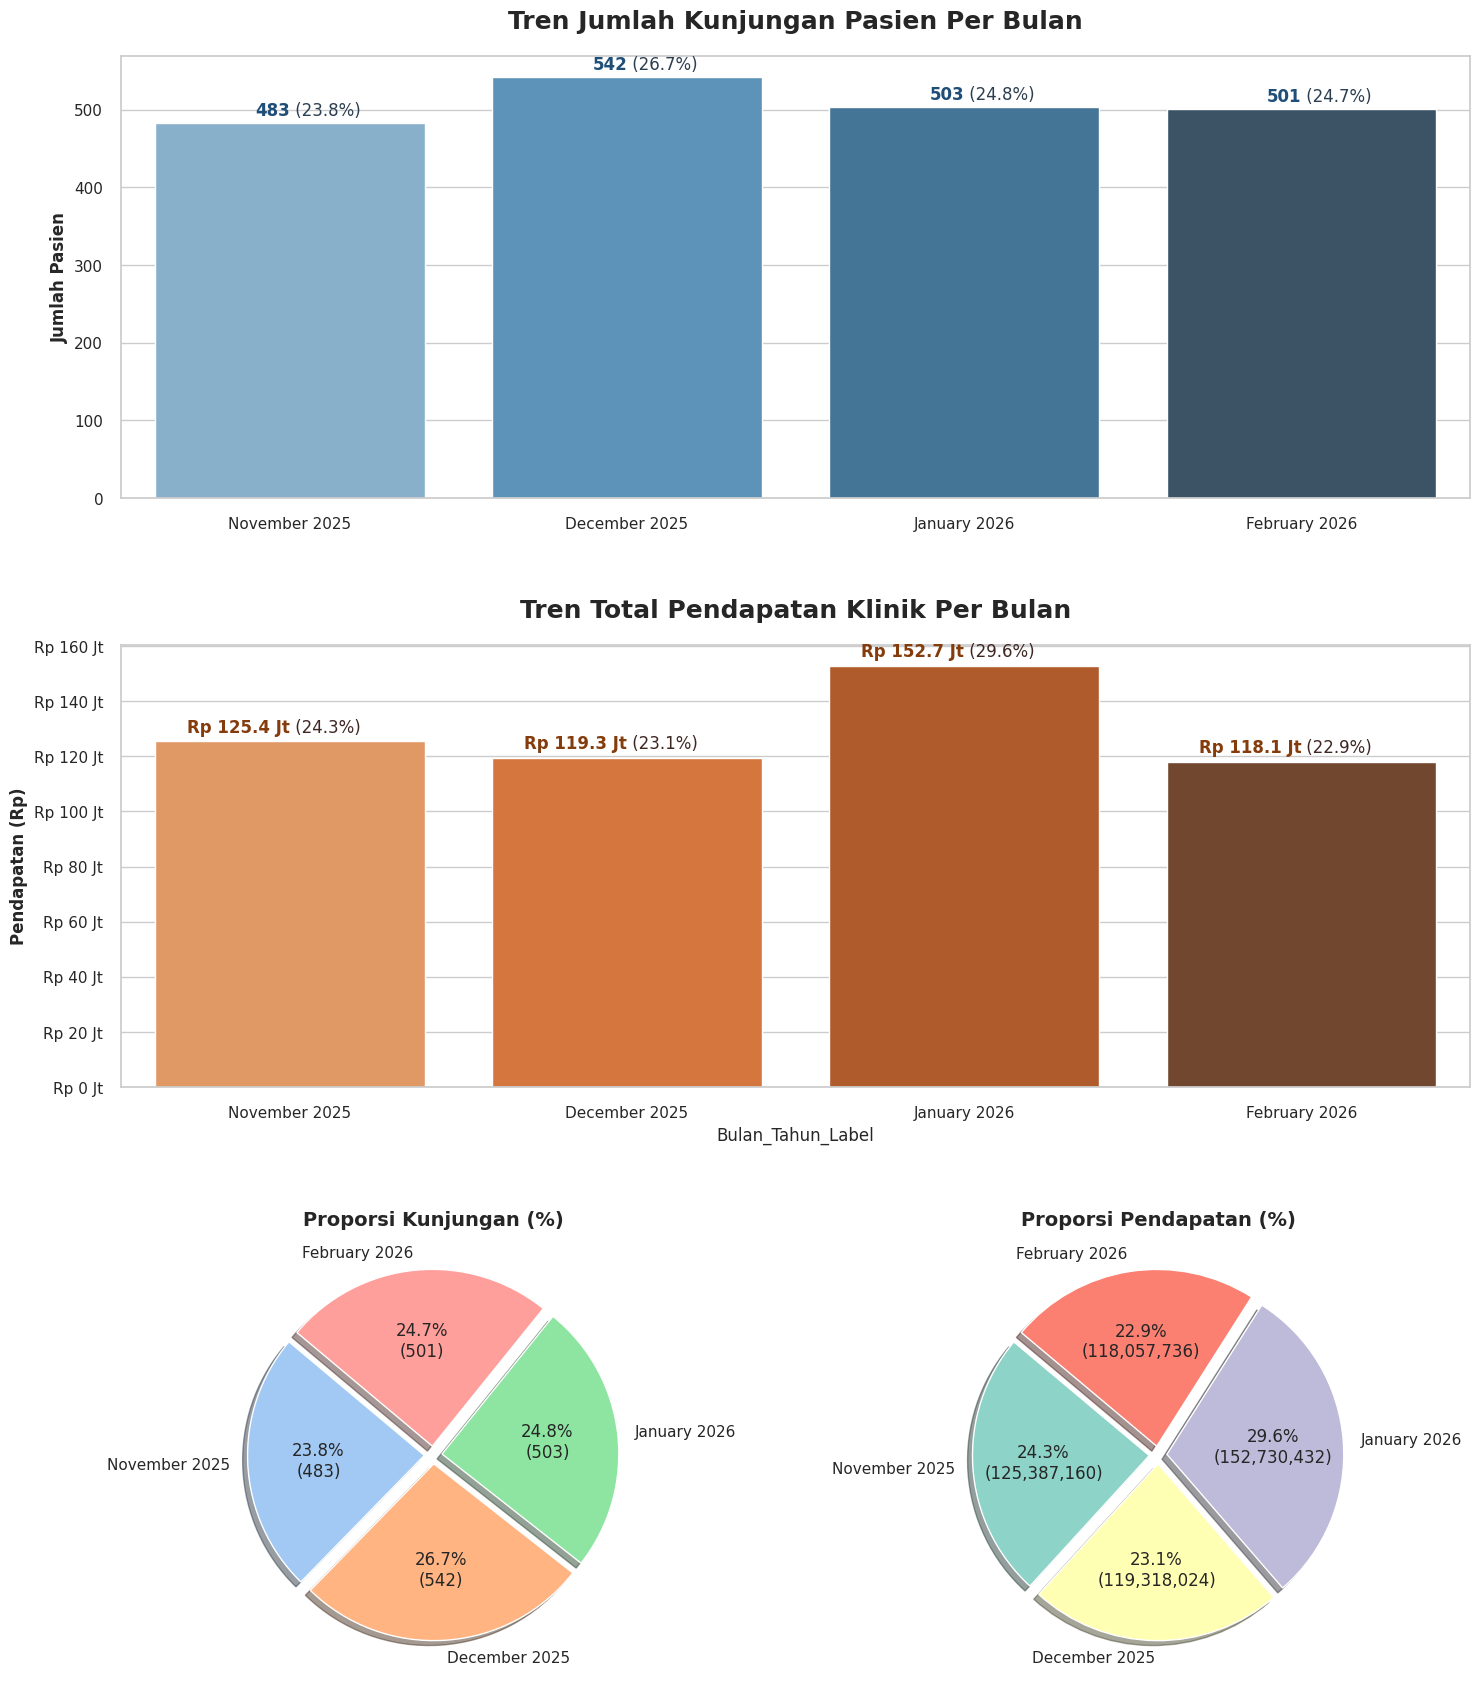

In [19]:
print("[2] Menjalankan analisis mendalam tren dan proporsi bulanan...")

# 1. Agregasi Data Dasar
tren_bulanan = df_eda.groupby('Bulan_Tahun').agg(
    Total_Kunjungan=('NAMA PELANGGAN', 'count'),
    Total_Pendapatan=('TOTAL TAGIHAN', 'sum')
).reset_index()

# 2. Transformasi Label Tanggal (YYYY-MM -> Nama Bulan YYYY)
tren_bulanan['Bulan_Tahun_Label'] = pd.to_datetime(tren_bulanan['Bulan_Tahun']).dt.strftime('%B %Y')

# 3. Kalkulasi Metrik Persentase
total_kunjungan_all = tren_bulanan['Total_Kunjungan'].sum()
total_pendapatan_all = tren_bulanan['Total_Pendapatan'].sum()

# Persentase Pertumbuhan (MoM)
tren_bulanan['Pertumbuhan_Kunjungan_%'] = tren_bulanan['Total_Kunjungan'].pct_change() * 100
tren_bulanan['Pertumbuhan_Pendapatan_%'] = tren_bulanan['Total_Pendapatan'].pct_change() * 100

# Persentase Kontribusi terhadap Total (Share)
tren_bulanan['%_Kontribusi_Kunjungan'] = (tren_bulanan['Total_Kunjungan'] / total_kunjungan_all) * 100
tren_bulanan['%_Kontribusi_Pendapatan'] = (tren_bulanan['Total_Pendapatan'] / total_pendapatan_all) * 100

# 4. Menampilkan Tabel Tanpa Highlight Warna
print("\n--- TABEL ANALISIS PERFORMA & KONTRIBUSI BULANAN ---")
display(tren_bulanan[['Bulan_Tahun_Label', 'Total_Kunjungan', 'Total_Pendapatan', 'Pertumbuhan_Kunjungan_%', 'Pertumbuhan_Pendapatan_%', '%_Kontribusi_Kunjungan', '%_Kontribusi_Pendapatan']].style.format({
    'Total_Kunjungan': '{:,}',
    'Total_Pendapatan': 'Rp {:,.0f}',
    'Pertumbuhan_Kunjungan_%': '{:+.2f}%',
    'Pertumbuhan_Pendapatan_%': '{:+.2f}%',
    '%_Kontribusi_Kunjungan': '{:.2f}%',
    '%_Kontribusi_Pendapatan': '{:.2f}%'
}).set_properties(**{'text-align': 'center'}))

# 5. Visualisasi Utama: Dua Bar Chart Terpisah yang Profesional
fig = plt.figure(figsize=(16, 18))
gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1])

# Grafik A: Bar Chart Kunjungan
ax1 = fig.add_subplot(gs[0, :])
sns.barplot(data=tren_bulanan, x='Bulan_Tahun_Label', y='Total_Kunjungan', palette='Blues_d', ax=ax1)
ax1.set_title('Tren Jumlah Kunjungan Pasien Per Bulan', fontsize=18, fontweight='bold', pad=20)
ax1.set_ylabel('Jumlah Pasien', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
for i, row in tren_bulanan.iterrows():
    # Menampilkan teks di satu baris: Jumlah (Bold) + Persentase (Normal)
    jumlah_val = f"{int(row['Total_Kunjungan']):,}"
    persen_val = f" ({row['%_Kontribusi_Kunjungan']:.1f}%)"

    # Gunakan gabungan string untuk satu baris, atau dua pemanggilan text jika ingin styling berbeda di satu baris
    ax1.text(i, row['Total_Kunjungan'] + 5, jumlah_val, ha='right', va='bottom', fontsize=12, fontweight='bold', color='#1f4e79')
    ax1.text(i, row['Total_Kunjungan'] + 5, persen_val, ha='left', va='bottom', fontsize=12, fontweight='normal', color='#2c3e50')

# Grafik B: Bar Chart Pendapatan
ax2 = fig.add_subplot(gs[1, :])
sns.barplot(data=tren_bulanan, x='Bulan_Tahun_Label', y='Total_Pendapatan', palette='Oranges_d', ax=ax2)
ax2.set_title('Tren Total Pendapatan Klinik Per Bulan', fontsize=18, fontweight='bold', pad=20)
ax2.set_ylabel('Pendapatan (Rp)', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'Rp {x*1e-6:,.0f} Jt'))
for i, row in tren_bulanan.iterrows():
    jumlah_val = f"Rp {row['Total_Pendapatan']*1e-6:,.1f} Jt"
    persen_val = f" ({row['%_Kontribusi_Pendapatan']:.1f}%)"

    ax2.text(i, row['Total_Pendapatan'] + 2000000, jumlah_val, ha='right', va='bottom', fontsize=12, fontweight='bold', color='#843c0c')
    ax2.text(i, row['Total_Pendapatan'] + 2000000, persen_val, ha='left', va='bottom', fontsize=12, fontweight='normal', color='#3e2723')

# 6. Subplot Proporsi (Pie Charts)
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.1f}%\n({v:,.0f})'.format(p=pct, v=val)
    return my_autopct

ax3 = fig.add_subplot(gs[2, 0])
ax3.pie(tren_bulanan['Total_Kunjungan'], labels=tren_bulanan['Bulan_Tahun_Label'],
        autopct=make_autopct(tren_bulanan['Total_Kunjungan']), startangle=140,
        colors=sns.color_palette("pastel"), explode=[0.05]*len(tren_bulanan), shadow=True)
ax3.set_title('Proporsi Kunjungan (%)', fontsize=14, fontweight='bold')

ax4 = fig.add_subplot(gs[2, 1])
ax4.pie(tren_bulanan['Total_Pendapatan'], labels=tren_bulanan['Bulan_Tahun_Label'],
        autopct=make_autopct(tren_bulanan['Total_Pendapatan']), startangle=140,
        colors=sns.color_palette("Set3"), explode=[0.05]*len(tren_bulanan), shadow=True)
ax4.set_title('Proporsi Pendapatan (%)', fontsize=14, fontweight='bold')

plt.tight_layout(pad=4.0)
plt.show()

### **4.3: Profiling Demografi Pasien (Spesies dan Ras)**

[3] Menjalankan analisis demografi pasien (Spesies dan Ras)...

--- TABEL PROFIL SPESIES PASIEN ---


,Spesies,Jumlah_Kunjungan,%_Kontribusi
0,Kucing,"1,656",81.62%
1,Anjing,339,16.71%
2,Lainnya,12,0.59%
3,Binatang Kecil,10,0.49%
4,Kelinci,6,0.30%
5,Reptil,5,0.25%
6,Monyet,1,0.05%


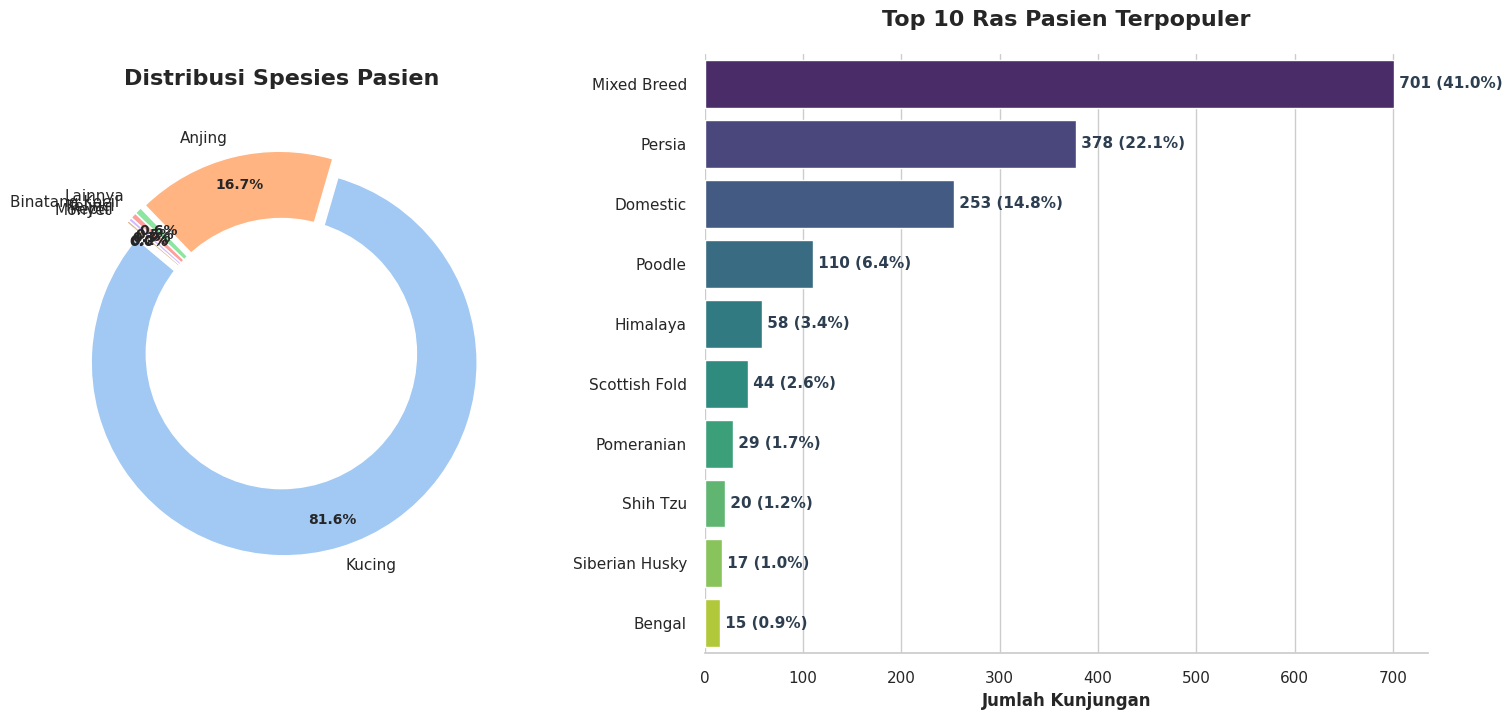

In [20]:
print("[3] Menjalankan analisis demografi pasien (Spesies dan Ras)...\n")

# 1. Agregasi Data Spesies
profil_spesies = df_eda['SPESIES'].value_counts().reset_index()
profil_spesies.columns = ['Spesies', 'Jumlah_Kunjungan']
total_kunjungan = profil_spesies['Jumlah_Kunjungan'].sum()
profil_spesies['%_Kontribusi'] = (profil_spesies['Jumlah_Kunjungan'] / total_kunjungan) * 100

# 2. Menampilkan Tabel Ringkasan Spesies
print("--- TABEL PROFIL SPESIES PASIEN ---")
display(profil_spesies.style.format({
    'Jumlah_Kunjungan': '{:,}',
    '%_Kontribusi': '{:.2f}%'
}).set_properties(**{'text-align': 'center'}))

# 3. Visualisasi Profesional
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(1, 2, width_ratios=[1, 1.5])

# Grafik A: Donut Chart Spesies
ax0 = fig.add_subplot(gs[0])
# Membuat Donut Chart
wedges, texts, autotexts = ax0.pie(profil_spesies['Jumlah_Kunjungan'],
                                  labels=profil_spesies['Spesies'],
                                  autopct='%1.1f%%',
                                  startangle=140,
                                  colors=sns.color_palette("pastel"),
                                  pctdistance=0.85,
                                  explode=[0.05]*len(profil_spesies))
# Menambahkan lingkaran di tengah untuk efek donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax0.set_title('Distribusi Spesies Pasien', fontsize=16, fontweight='bold', pad=20)
plt.setp(autotexts, size=10, weight="bold")

# Grafik B: Top 10 Ras Pasien
ax1 = fig.add_subplot(gs[1])
df_ras_valid = df_eda[~df_eda['RAS'].str.contains('TIDAK DIKETAHUI|UNKNOWN', case=False, na=False)]
top_10_ras = df_ras_valid['RAS'].value_counts().head(10).reset_index()
top_10_ras.columns = ['Ras', 'Count']
total_ras_valid = df_ras_valid.shape[0]

sns.barplot(data=top_10_ras, x='Count', y='Ras', palette='viridis', ax=ax1)
ax1.set_title('Top 10 Ras Pasien Terpopuler', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Jumlah Kunjungan', fontsize=12, fontweight='bold')
ax1.set_ylabel('')

# Menambahkan Label di Samping Bar (Jumlah + %)
for i, row in top_10_ras.iterrows():
    pct = (row['Count'] / total_ras_valid) * 100
    label = f" {int(row['Count']):,} ({pct:.1f}%)"
    ax1.text(row['Count'], i, label, va='center', fontsize=11, fontweight='bold', color='#2c3e50')

sns.despine(left=True, bottom=False)
plt.tight_layout(pad=3.0)
plt.show()

### **4.4: Analisis Popularitas Layanan dan Kontribusi Pendapatan Poliklinik**

[4] Menjalankan visualisasi performa tiap layanan poliklinik...


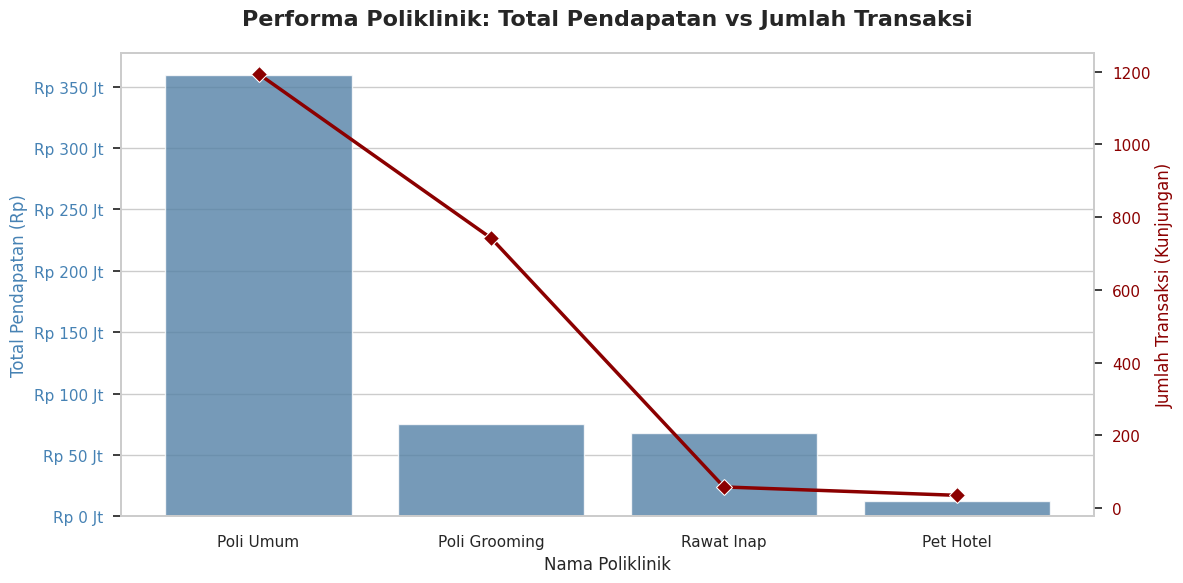

In [21]:
print("[4] Menjalankan visualisasi performa tiap layanan poliklinik...")

# Agregasi data berdasarkan poliklinik
performa_poli = df_eda.groupby('POLIKLINIK').agg(
    Jumlah_Transaksi=('NAMA PELANGGAN', 'count'),
    Total_Pendapatan=('TOTAL TAGIHAN', 'sum')
).reset_index().sort_values(by='Total_Pendapatan', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Membuat grafik batang untuk Total Pendapatan
sns.barplot(data=performa_poli, x='POLIKLINIK', y='Total_Pendapatan', color='steelblue', ax=ax1, alpha=0.8)
ax1.set_title('Performa Poliklinik: Total Pendapatan vs Jumlah Transaksi', fontsize=16, pad=20)
ax1.set_xlabel('Nama Poliklinik', fontsize=12)
ax1.set_ylabel('Total Pendapatan (Rp)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'Rp {x*1e-6:,.0f} Jt'))

# Membuat sumbu Y sekunder (Twin Axes) untuk Jumlah Transaksi
ax2 = ax1.twinx()
sns.lineplot(data=performa_poli, x='POLIKLINIK', y='Jumlah_Transaksi', color='darkred',
             marker='D', markersize=8, linewidth=2.5, ax=ax2)
ax2.set_ylabel('Jumlah Transaksi (Kunjungan)', fontsize=12, color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.grid(False)

plt.tight_layout()
plt.show()

### **4.5: Analisis Distribusi Nilai Transaksi (Total Tagihan)**

[5] Menjalankan analisis sebaran statistik nilai transaksi...


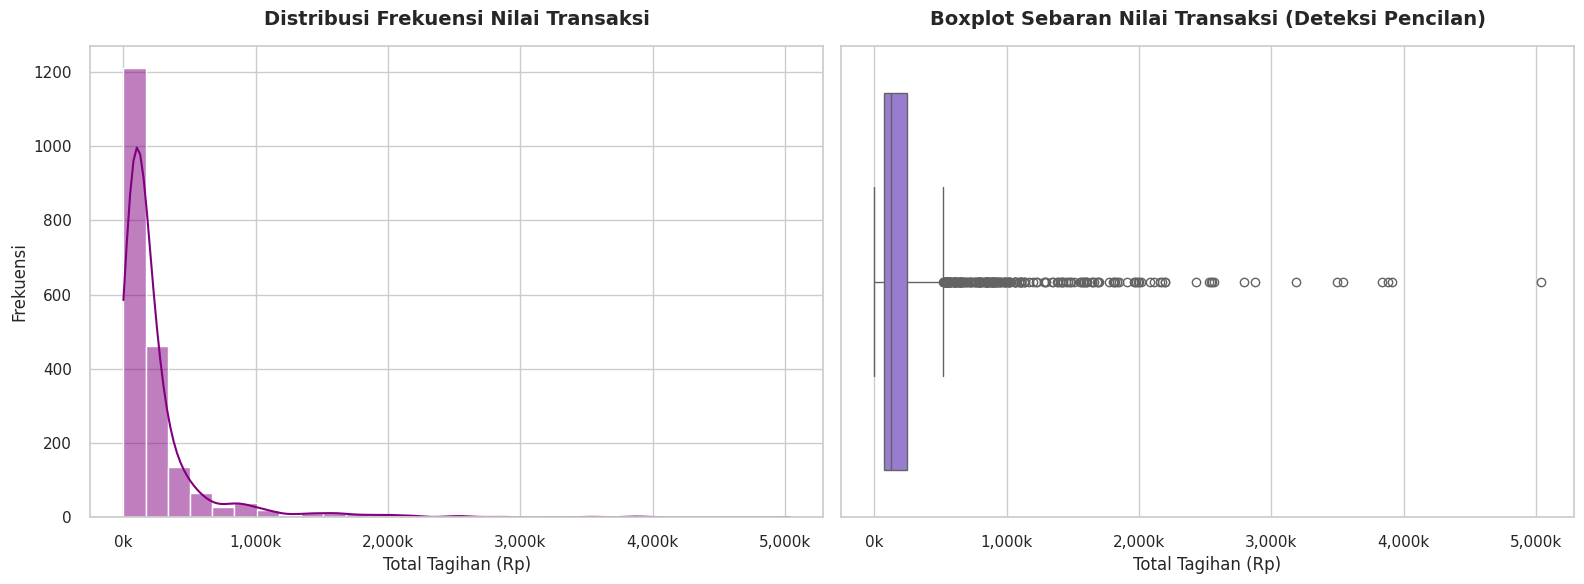


Statistik Deskriptif Nilai Transaksi (TOTAL TAGIHAN):


,count,mean,std,min,25%,50%,75%,max
TOTAL TAGIHAN,2029.0,254062.754534,398590.387361,0.0,70000.0,125000.0,250000.0,5035000.0


In [22]:
print("[5] Menjalankan analisis sebaran statistik nilai transaksi...")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Histogram dan Kurva Distribusi Kepadatan (KDE)
sns.histplot(df_eda['TOTAL TAGIHAN'], bins=30, kde=True, color='purple', ax=ax[0])
ax[0].set_title('Distribusi Frekuensi Nilai Transaksi', fontsize=14, pad=15)
ax[0].set_xlabel('Total Tagihan (Rp)', fontsize=12)
ax[0].set_ylabel('Frekuensi', fontsize=12)
ax[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:,.0f}k'))

# Grafik 2: Boxplot untuk mendeteksi pencilan (Outlier) secara visual
sns.boxplot(x=df_eda['TOTAL TAGIHAN'], color='mediumpurple', ax=ax[1])
ax[1].set_title('Boxplot Sebaran Nilai Transaksi (Deteksi Pencilan)', fontsize=14, pad=15)
ax[1].set_xlabel('Total Tagihan (Rp)', fontsize=12)
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:,.0f}k'))

plt.tight_layout()
plt.show()

# Menampilkan statistik deskriptif numerik
print("\nStatistik Deskriptif Nilai Transaksi (TOTAL TAGIHAN):")
display(df_eda['TOTAL TAGIHAN'].describe().to_frame().T)

### **4.6: Identifikasi Pelanggan Teratas (*Top Customers - Pre RFM*)**

[6] Mengidentifikasi pelanggan VIP berdasarkan frekuensi dan monetary...



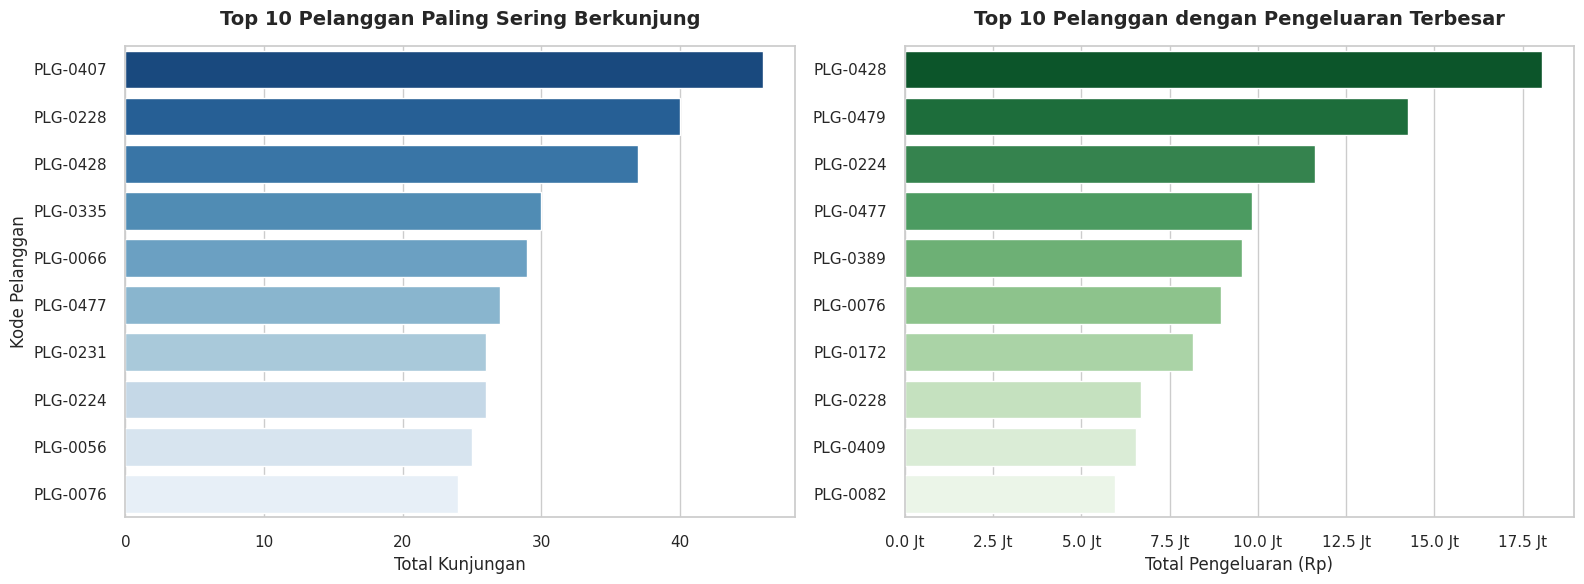


--- TABEL TOP 10 PELANGGAN: FREKUENSI TERTINGGI ---


,NAMA PELANGGAN,Frekuensi_Kunjungan,%_Kunjungan
406,PLG-0407,46,2.27%
227,PLG-0228,40,1.97%
427,PLG-0428,37,1.82%
334,PLG-0335,30,1.48%
65,PLG-0066,29,1.43%
476,PLG-0477,27,1.33%
230,PLG-0231,26,1.28%
223,PLG-0224,26,1.28%
55,PLG-0056,25,1.23%
75,PLG-0076,24,1.18%



--- TABEL TOP 10 PELANGGAN: PENGELUARAN TERBESAR (MONETARY) ---


,NAMA PELANGGAN,Total_Pengeluaran,%_Pengeluaran
427,PLG-0428,"Rp 18,051,700",3.50%
478,PLG-0479,"Rp 14,247,500",2.76%
223,PLG-0224,"Rp 11,608,750",2.25%
476,PLG-0477,"Rp 9,845,500",1.91%
388,PLG-0389,"Rp 9,560,500",1.85%
75,PLG-0076,"Rp 8,965,350",1.74%
171,PLG-0172,"Rp 8,166,700",1.58%
227,PLG-0228,"Rp 6,693,500",1.30%
408,PLG-0409,"Rp 6,560,000",1.27%
81,PLG-0082,"Rp 5,945,000",1.15%


In [23]:
print("[6] Mengidentifikasi pelanggan VIP berdasarkan frekuensi dan monetary...\n")

# Agregasi data pelanggan
profil_pelanggan = df_eda.groupby('NAMA PELANGGAN').agg(
    Frekuensi_Kunjungan=('Tanggal_Transaksi', 'count'),
    Total_Pengeluaran=('TOTAL TAGIHAN', 'sum')
).reset_index()

# Hitung total untuk persentase
total_kunjungan_all = profil_pelanggan['Frekuensi_Kunjungan'].sum()
total_pengeluaran_all = profil_pelanggan['Total_Pengeluaran'].sum()

# 1. Mengambil Top 10 Pelanggan berdasarkan Frekuensi
top_10_freq = profil_pelanggan.sort_values(by='Frekuensi_Kunjungan', ascending=False).head(10).copy()
top_10_freq['%_Kunjungan'] = (top_10_freq['Frekuensi_Kunjungan'] / total_kunjungan_all) * 100

# 2. Mengambil Top 10 Pelanggan berdasarkan Monetary (Pengeluaran)
top_10_monetary = profil_pelanggan.sort_values(by='Total_Pengeluaran', ascending=False).head(10).copy()
top_10_monetary['%_Pengeluaran'] = (top_10_monetary['Total_Pengeluaran'] / total_pengeluaran_all) * 100

# --- VISUALISASI ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Top 10 Frekuensi
sns.barplot(data=top_10_freq, x='Frekuensi_Kunjungan', y='NAMA PELANGGAN', palette='Blues_r', ax=ax[0])
ax[0].set_title('Top 10 Pelanggan Paling Sering Berkunjung', fontsize=14, pad=15)
ax[0].set_xlabel('Total Kunjungan', fontsize=12)
ax[0].set_ylabel('Kode Pelanggan', fontsize=12)

# Grafik 2: Top 10 Monetary
sns.barplot(data=top_10_monetary, x='Total_Pengeluaran', y='NAMA PELANGGAN', palette='Greens_r', ax=ax[1])
ax[1].set_title('Top 10 Pelanggan dengan Pengeluaran Terbesar', fontsize=14, pad=15)
ax[1].set_xlabel('Total Pengeluaran (Rp)', fontsize=12)
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:,.1f} Jt'))

plt.tight_layout()
plt.show()

# --- TABEL RINGKASAN ---
print("\n--- TABEL TOP 10 PELANGGAN: FREKUENSI TERTINGGI ---")
display(top_10_freq[['NAMA PELANGGAN', 'Frekuensi_Kunjungan', '%_Kunjungan']].style.format({
    'Frekuensi_Kunjungan': '{:,}',
    '%_Kunjungan': '{:.2f}%'
}).set_properties(**{'text-align': 'center'}))

print("\n--- TABEL TOP 10 PELANGGAN: PENGELUARAN TERBESAR (MONETARY) ---")
display(top_10_monetary[['NAMA PELANGGAN', 'Total_Pengeluaran', '%_Pengeluaran']].style.format({
    'Total_Pengeluaran': 'Rp {:,.0f}',
    '%_Pengeluaran': '{:.2f}%'
}).set_properties(**{'text-align': 'center'}))

### **4.7: Identifikasi Pelanggan Terendah (*Bottom Customers - Pre RFM*)**

[7] Mengidentifikasi pelanggan dengan metrik terendah (Bottom Customers)...



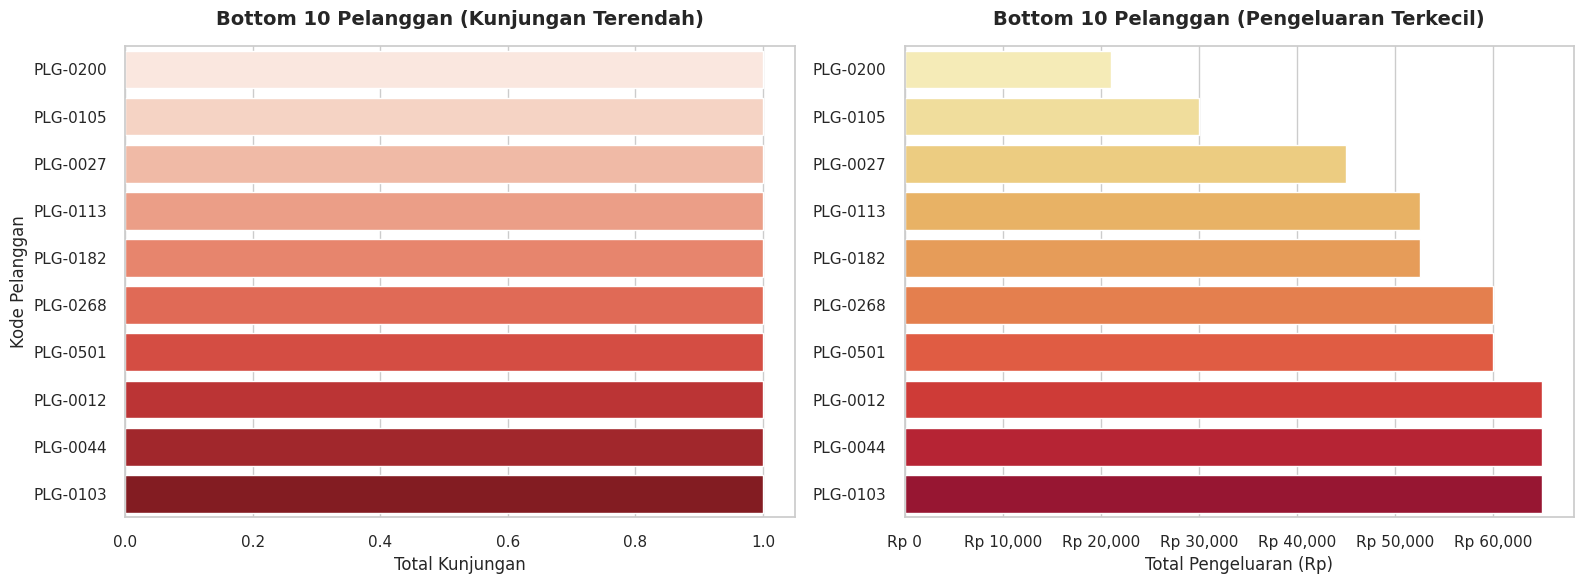


--- TABEL 10 PELANGGAN: FREKUENSI TERENDAH ---


,NAMA PELANGGAN,Frekuensi_Kunjungan,%_Kunjungan
199,PLG-0200,1,0.0493%
104,PLG-0105,1,0.0493%
26,PLG-0027,1,0.0493%
112,PLG-0113,1,0.0493%
181,PLG-0182,1,0.0493%
267,PLG-0268,1,0.0493%
500,PLG-0501,1,0.0493%
11,PLG-0012,1,0.0493%
43,PLG-0044,1,0.0493%
102,PLG-0103,1,0.0493%



--- TABEL 10 PELANGGAN: PENGELUARAN TERKECIL (MONETARY) ---


,NAMA PELANGGAN,Total_Pengeluaran,%_Pengeluaran
199,PLG-0200,"Rp 21,001",0.0041%
104,PLG-0105,"Rp 30,000",0.0058%
26,PLG-0027,"Rp 45,000",0.0087%
112,PLG-0113,"Rp 52,500",0.0102%
181,PLG-0182,"Rp 52,500",0.0102%
267,PLG-0268,"Rp 60,000",0.0116%
500,PLG-0501,"Rp 60,000",0.0116%
11,PLG-0012,"Rp 65,000",0.0126%
43,PLG-0044,"Rp 65,000",0.0126%
102,PLG-0103,"Rp 65,000",0.0126%



[8] Analisis Distribusi Frekuensi Kunjungan (1-10 Kali)...

--- TABEL DISTRIBUSI FREKUENSI KUNJUNGAN (1-10 KALI) ---


,Jumlah Kunjungan,Jumlah Pelanggan,%_Total Pelanggan
0,1,186,36.19%
1,2,109,21.21%
2,3,50,9.73%
3,4,45,8.75%
4,5,20,3.89%
5,6,25,4.86%
6,7,12,2.33%
7,8,15,2.92%
8,9,9,1.75%
9,10,9,1.75%


In [24]:
print("[7] Mengidentifikasi pelanggan dengan metrik terendah (Bottom Customers)...\n")

# Mengambil 10 Pelanggan berdasarkan Frekuensi Terendah (Bottom 10)
# Kita urutkan ascending (terkecil ke terbesar)
bottom_10_freq = profil_pelanggan.sort_values(by=['Frekuensi_Kunjungan', 'Total_Pengeluaran'], ascending=True).head(10).copy()
bottom_10_freq['%_Kunjungan'] = (bottom_10_freq['Frekuensi_Kunjungan'] / total_kunjungan_all) * 100

# Mengambil 10 Pelanggan berdasarkan Monetary Terendah (Bottom 10)
bottom_10_monetary = profil_pelanggan.sort_values(by=['Total_Pengeluaran', 'Frekuensi_Kunjungan'], ascending=True).head(10).copy()
bottom_10_monetary['%_Pengeluaran'] = (bottom_10_monetary['Total_Pengeluaran'] / total_pengeluaran_all) * 100

# --- VISUALISASI ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Bottom 10 Frekuensi
sns.barplot(data=bottom_10_freq, x='Frekuensi_Kunjungan', y='NAMA PELANGGAN', palette='Reds', ax=ax[0])
ax[0].set_title('Bottom 10 Pelanggan (Kunjungan Terendah)', fontsize=14, pad=15)
ax[0].set_xlabel('Total Kunjungan', fontsize=12)
ax[0].set_ylabel('Kode Pelanggan', fontsize=12)

# Grafik 2: Bottom 10 Monetary
sns.barplot(data=bottom_10_monetary, x='Total_Pengeluaran', y='NAMA PELANGGAN', palette='YlOrRd', ax=ax[1])
ax[1].set_title('Bottom 10 Pelanggan (Pengeluaran Terkecil)', fontsize=14, pad=15)
ax[1].set_xlabel('Total Pengeluaran (Rp)', fontsize=12)
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'Rp {x:,.0f}'))

plt.tight_layout()
plt.show()

# --- TABEL RINGKASAN ---
print("\n--- TABEL 10 PELANGGAN: FREKUENSI TERENDAH ---")
display(bottom_10_freq[['NAMA PELANGGAN', 'Frekuensi_Kunjungan', '%_Kunjungan']].style.format({
    'Frekuensi_Kunjungan': '{:,}',
    '%_Kunjungan': '{:.4f}%'
}).set_properties(**{'text-align': 'center'}))

print("\n--- TABEL 10 PELANGGAN: PENGELUARAN TERKECIL (MONETARY) ---")
display(bottom_10_monetary[['NAMA PELANGGAN', 'Total_Pengeluaran', '%_Pengeluaran']].style.format({
    'Total_Pengeluaran': 'Rp {:,.0f}',
    '%_Pengeluaran': '{:.4f}%'
}).set_properties(**{'text-align': 'center'}))

print("\n[8] Analisis Distribusi Frekuensi Kunjungan (1-10 Kali)...\n")

# Agregasi jumlah pelanggan per frekuensi kunjungan
frekuensi_distribusi = profil_pelanggan['Frekuensi_Kunjungan'].value_counts().sort_index().reset_index()
frekuensi_distribusi.columns = ['Jumlah Kunjungan', 'Jumlah Pelanggan']

# Filter untuk frekuensi 1 sampai 10 kali
frekuensi_distribusi_filtered = frekuensi_distribusi[frekuensi_distribusi['Jumlah Kunjungan'].isin(range(1, 11))].copy()

# Hitung total pelanggan untuk persentase
total_pelanggan_all = profil_pelanggan['NAMA PELANGGAN'].nunique()
frekuensi_distribusi_filtered['%_Total Pelanggan'] = (frekuensi_distribusi_filtered['Jumlah Pelanggan'] / total_pelanggan_all) * 100

print("--- TABEL DISTRIBUSI FREKUENSI KUNJUNGAN (1-10 KALI) ---")
display(frekuensi_distribusi_filtered.style.format({
    'Jumlah Pelanggan': '{:,}',
    '%_Total Pelanggan': '{:.2f}%'
}).set_properties(**{'text-align': 'center'}))

### **4.7: Identifikasi dan Penanganan Anomali Transaksi (*Outlier & Zero Values*)**

In [25]:
# # Identifikasi dan pembersihan anomali transaksi dengan nilai tagihan Rp 0 atau negatif
# jumlah_nol = (df_clean['TOTAL TAGIHAN'] <= 0).sum()
# print(f"[INFO] Ditemukan {jumlah_nol} baris dengan TOTAL TAGIHAN bernilai 0 atau negatif.")

# if jumlah_nol > 0:
#     print("\n--- 5 Baris Sampel Data dengan TOTAL TAGIHAN <= 0 ---")
#     display(df_clean[df_clean['TOTAL TAGIHAN'] <= 0][['TOTAL TAGIHAN']].head())
#     print("\n")

# # Melakukan filter hanya pada data yang memiliki nilai transaksi valid
# df_clean = df_clean[df_clean['TOTAL TAGIHAN'] > 0].copy()
# print(f"Jumlah baris data final setelah pembersihan: {df_clean.shape[0]} baris.")

In [26]:
# Identifikasi dan pembersihan anomali transaksi dengan nilai tagihan Rp 0 atau negatif
jumlah_nol = (df_clean['TOTAL TAGIHAN'] <= 0).sum()
print(f"[INFO] Ditemukan {jumlah_nol} baris dengan TOTAL TAGIHAN bernilai 0 atau negatif.")

if jumlah_nol > 0:
    print("\n--- 5 Baris Sampel Data dengan TOTAL TAGIHAN <= 0 ---")
    display(df_clean[df_clean['TOTAL TAGIHAN'] <= 0].head())
    print("\n")

# Melakukan filter hanya pada data yang memiliki nilai transaksi valid
df_clean = df_clean[df_clean['TOTAL TAGIHAN'] > 0].copy()
print(f"Total baris data setelah pembersihan: {df_clean.shape[0]}")

[INFO] Ditemukan 5 baris dengan TOTAL TAGIHAN bernilai 0 atau negatif.

--- 5 Baris Sampel Data dengan TOTAL TAGIHAN <= 0 ---


,Tanggal_Transaksi,NAMA PELANGGAN,NAMA HEWAN,SPESIES,RAS,POLIKLINIK,TOTAL TAGIHAN
956,2025-12-27,PLG-0432,HWN-0386,Anjing,Poodle,Poli Umum,0.0
1610,2026-02-25,PLG-0210,HWN-0348,Anjing,Poodle,Poli Umum,0.0
1702,2026-02-20,PLG-0440,HWN-0392,Kucing,Mixed Breed,Poli Grooming,0.0
1706,2026-02-20,PLG-0112,HWN-0062,Anjing,Poodle,Poli Umum,0.0
1707,2026-02-20,PLG-0112,HWN-0062,Anjing,Poodle,Poli Grooming,0.0




Total baris data setelah pembersihan: 2024


## **BAB 5: EKSTRAKSI FITUR RFM (*RFM FEATURE EXTRACTION*)**


### **5.1: Penentuan Titik Waktu Referensi (*Reference Time Point Determination*)**

In [27]:
print("[1] Menetapkan titik waktu referensi untuk perhitungan Recency...")

# Mencari tanggal transaksi paling terakhir (paling baru) di seluruh dataset
tanggal_terakhir = df_clean['Tanggal_Transaksi'].max()

# Menambahkan 1 hari dari tanggal transaksi terakhir sebagai "Hari Ini" (Reference Date)
titik_referensi = tanggal_terakhir + dt.timedelta(days=1)

print(f"- Tanggal transaksi terakhir di data  : {tanggal_terakhir.strftime('%Y-%m-%d')}")
print(f"- Titik waktu referensi (Snapshot)    : {titik_referensi.strftime('%Y-%m-%d')}")

[1] Menetapkan titik waktu referensi untuk perhitungan Recency...
- Tanggal transaksi terakhir di data  : 2026-02-28
- Titik waktu referensi (Snapshot)    : 2026-03-01


### **5.2: Kalkulasi Nilai *Recency*, *Frequency*, dan *Monetary***


In [28]:
print("[2] Melakukan kalkulasi nilai R, F, dan M secara terpisah...")

# 1. Kalkulasi Recency (R)
# Mencari tanggal kedatangan terakhir untuk setiap pelanggan, lalu dihitung selisih harinya
df_recency = df_clean.groupby('NAMA PELANGGAN')['Tanggal_Transaksi'].max().reset_index()
df_recency['Recency'] = (titik_referensi - df_recency['Tanggal_Transaksi']).dt.days
# Membuang kolom tanggal karena sudah digantikan oleh nilai hari (Recency)
df_recency = df_recency[['NAMA PELANGGAN', 'Recency']]

# 2. Kalkulasi Frequency (F)
# Menghitung jumlah kedatangan (jumlah baris transaksi) per pelanggan
df_frequency = df_clean.groupby('NAMA PELANGGAN')['Tanggal_Transaksi'].count().reset_index()
df_frequency.columns = ['NAMA PELANGGAN', 'Frequency']

# 3. Kalkulasi Monetary (M)
# Menjumlahkan total tagihan yang pernah dibayarkan oleh masing-masing pelanggan
df_monetary = df_clean.groupby('NAMA PELANGGAN')['TOTAL TAGIHAN'].sum().reset_index()
df_monetary.columns = ['NAMA PELANGGAN', 'Monetary']

print("- Tabel Recency, Frequency, dan Monetary berhasil dikalkulasi secara independen.")

[2] Melakukan kalkulasi nilai R, F, dan M secara terpisah...
- Tabel Recency, Frequency, dan Monetary berhasil dikalkulasi secara independen.


### **5.3: Penggabungan dan Pembuatan DataFrame RFM**

In [29]:
print("[3] Menggabungkan ketiga metrik menjadi satu DataFrame RFM yang utuh...")

# Menggabungkan (Merging) df_recency dan df_frequency berdasarkan NAMA PELANGGAN
df_rfm = df_recency.merge(df_frequency, on='NAMA PELANGGAN')

# Menggabungkan hasilnya dengan df_monetary
df_rfm = df_rfm.merge(df_monetary, on='NAMA PELANGGAN')

# Mengganti nama kolom agar sesuai dengan standar
df_rfm.columns = ['Kode_Pelanggan', 'Recency', 'Frequency', 'Monetary']

print("- [SUKSES] Penggabungan selesai. DataFrame RFM berhasil dibuat!")
print(f"- Total profil pelanggan yang diekstrak: {df_rfm.shape[0]:,} baris")

print("\nCuplikan 5 baris pertama DataFrame RFM:")
print("=" * 60)
display(df_rfm.head())

print("\nStatistik Deskriptif Matriks RFM:")
print("-" * 60)
display(df_rfm.describe().T)

print("\Informasi Matriks RFM:")
print("-" * 60)
df_rfm.info()

[3] Menggabungkan ketiga metrik menjadi satu DataFrame RFM yang utuh...
- [SUKSES] Penggabungan selesai. DataFrame RFM berhasil dibuat!
- Total profil pelanggan yang diekstrak: 514 baris

Cuplikan 5 baris pertama DataFrame RFM:


,Kode_Pelanggan,Recency,Frequency,Monetary
0,PLG-0001,4,2,445000.0
1,PLG-0002,56,2,250000.0
2,PLG-0003,27,2,760000.0
3,PLG-0004,22,3,310000.0
4,PLG-0005,96,1,175000.0



Statistik Deskriptif Matriks RFM:
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Recency,514.0,4.289494e+01,3.222552e+01,1.0,15.0,36.0,64.75,120.0
Frequency,514.0,3.937743e+00,5.254907e+00,1.0,1.0,2.0,4.00,46.0
Monetary,514.0,1.002905e+06,1.640753e+06,21001.0,230000.0,506223.5,1081250.00,18051700.0


\Informasi Matriks RFM:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Kode_Pelanggan  514 non-null    object 
 1   Recency         514 non-null    int64  
 2   Frequency       514 non-null    int64  
 3   Monetary        514 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 16.2+ KB


## **BAB 6: PRA-PEMROSESAN DATA UNTUK KLASTERING**


### **6.1: Analisis Distribusi *Skewness* (Kemiringan Data)**

[1] Menganalisis tingkat kemiringan (Skewness) pada fitur RFM...


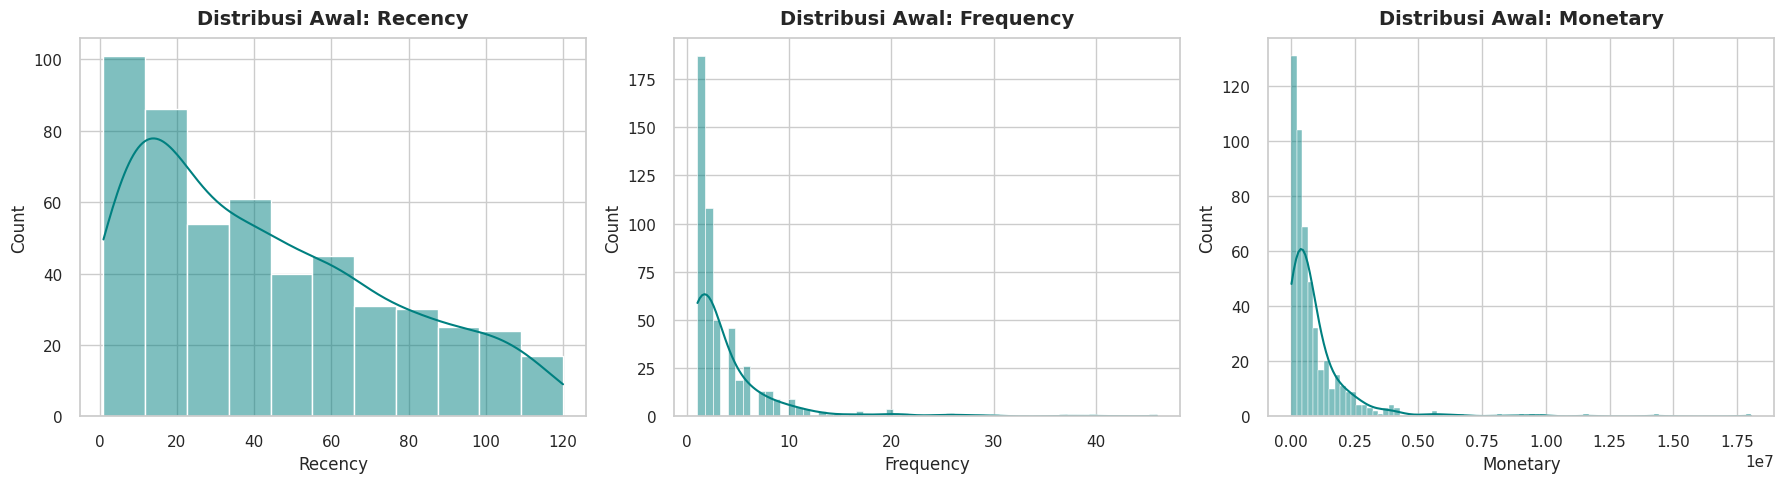


Nilai Skewness Statistik (Standar Normal mendekati 0):
------------------------------------------------------------


,Skor Skewness
Recency,0.611342
Frequency,3.837795
Monetary,5.229734



[Kesimpulan]:
Jika skor skewness > 1 atau < -1, data sangat miring (highly skewed).
Terlihat bahwa Frequency dan Monetary memiliki kemiringan positif yang sangat ekstrem.


In [30]:
print("[1] Menganalisis tingkat kemiringan (Skewness) pada fitur RFM...")

# Menyimpan kolom fitur numerik yang akan dianalisis
fitur_rfm = ['Recency', 'Frequency', 'Monetary']

# Membuat grafik distribusi untuk melihat skewness secara visual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(fitur_rfm):
    sns.histplot(df_rfm[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribusi Awal: {col}', fontsize=14, pad=10)

plt.tight_layout()
plt.show()

# Menghitung dan menampilkan nilai Skewness secara statistik
print("\nNilai Skewness Statistik (Standar Normal mendekati 0):")
print("-" * 60)
skewness_stats = df_rfm[fitur_rfm].skew().to_frame(name='Skor Skewness')
display(skewness_stats)

print("\n[Kesimpulan]:")
print("Jika skor skewness > 1 atau < -1, data sangat miring (highly skewed).")
print("Terlihat bahwa Frequency dan Monetary memiliki kemiringan positif yang sangat ekstrem.")

### **6.2: Transformasi Logaritmik (*Log Transform*)**

[2] Melakukan Transformasi Logaritmik untuk menormalkan distribusi data...


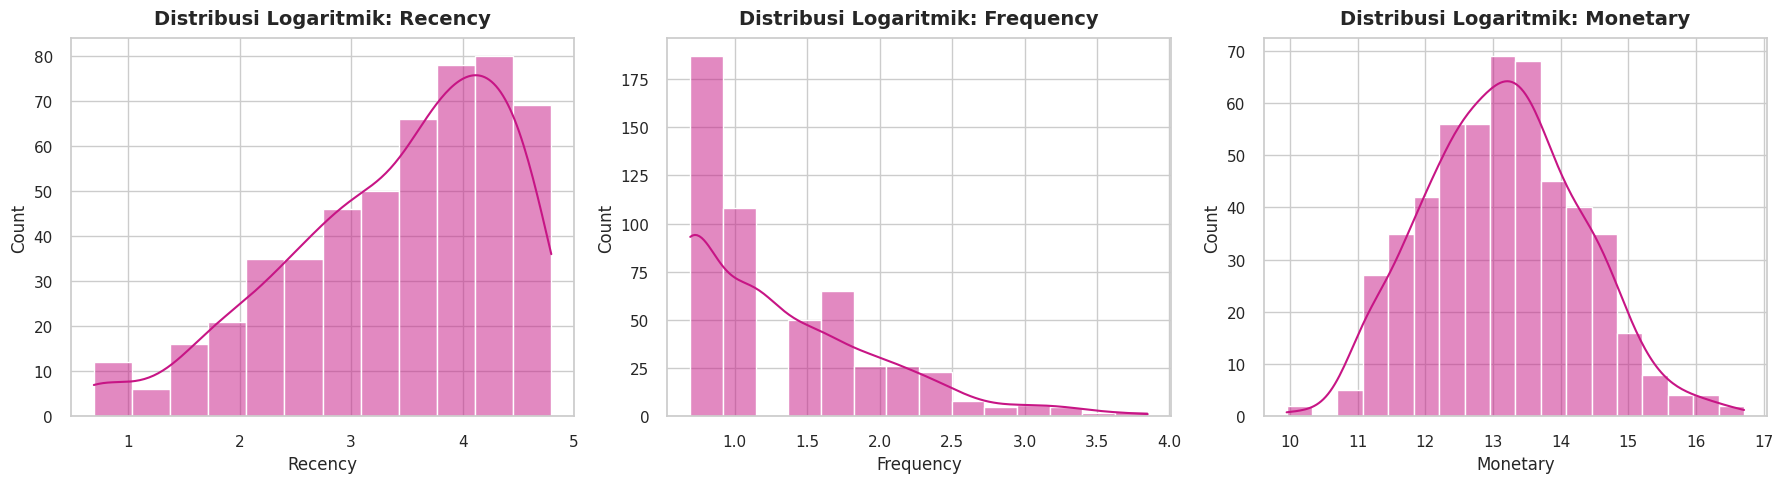


Nilai Skewness Setelah Transformasi Logaritmik:
------------------------------------------------------------


,Skor Skewness Log
Recency,-0.767558
Frequency,1.146473
Monetary,0.169487



[Kesimpulan]:
Distribusi data kini jauh lebih simetris dan ramah terhadap algoritma K-Means.


In [31]:
print("[2] Melakukan Transformasi Logaritmik untuk menormalkan distribusi data...")

# Membuat salinan DataFrame untuk menyimpan hasil transformasi
# Kita menggunakan np.log1p() alih-alih np.log() untuk menghindari error jika ada nilai 0
df_rfm_log = df_rfm.copy()

for col in fitur_rfm:
    # Transformasi Logaritmik
    df_rfm_log[col] = np.log1p(df_rfm[col])

# Visualisasi perbandingan setelah transformasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(fitur_rfm):
    sns.histplot(df_rfm_log[col], kde=True, ax=axes[i], color='mediumvioletred')
    axes[i].set_title(f'Distribusi Logaritmik: {col}', fontsize=14, pad=10)

plt.tight_layout()
plt.show()

print("\nNilai Skewness Setelah Transformasi Logaritmik:")
print("-" * 60)
skewness_log_stats = df_rfm_log[fitur_rfm].skew().to_frame(name='Skor Skewness Log')
display(skewness_log_stats)

print("\n[Kesimpulan]:")
print("Distribusi data kini jauh lebih simetris dan ramah terhadap algoritma K-Means.")

### **6.3: Deteksi dan Penanganan Pencilan (*Outlier*) - Evaluasi Pasca Transformasi**

[4] Mengevaluasi keberadaan pencilan (Outlier) pada matriks yang telah ditransformasi Log...


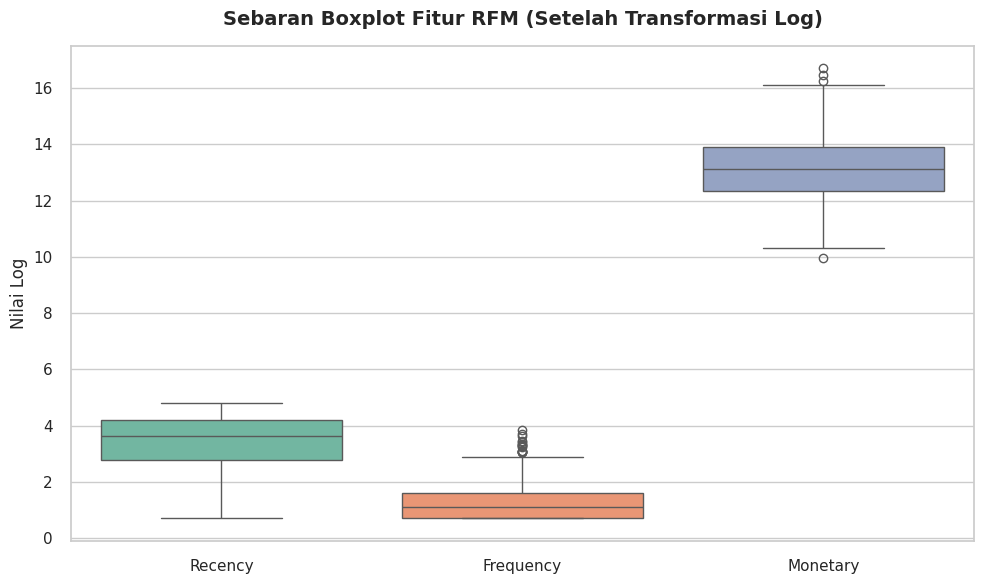


[CATATAN STRATEGIS]:
Boxplot di atas menunjukkan sebaran data setelah Log Transform.
Jika masih terlihat titik-titik di luar whiskers, maka kita perlu melakukan
Winsorization pada tahap berikutnya (6.4) sebelum akhirnya melakukan scaling.



In [32]:
print("[4] Mengevaluasi keberadaan pencilan (Outlier) pada matriks yang telah ditransformasi Log...")

# Visualisasi Boxplot menggunakan df_rfm_log untuk melihat sisa outlier sebelum penanganan
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_rfm_log[fitur_rfm], palette='Set2', ax=ax)
ax.set_title('Sebaran Boxplot Fitur RFM (Setelah Transformasi Log)', fontsize=14, pad=15)
ax.set_ylabel('Nilai Log', fontsize=12)

plt.tight_layout()
plt.show()

print("""
[CATATAN STRATEGIS]:
Boxplot di atas menunjukkan sebaran data setelah Log Transform.
Jika masih terlihat titik-titik di luar whiskers, maka kita perlu melakukan
Winsorization pada tahap berikutnya (6.4) sebelum akhirnya melakukan scaling.
""")

### **6.4 Penanganan Outlier dengan Winsorization**

[5] Menangani Outlier menggunakan Teknik Winsorization (Capping)... 

[INFO] Nilai ekstrem di atas persentil ke-95 telah disesuaikan (capped).


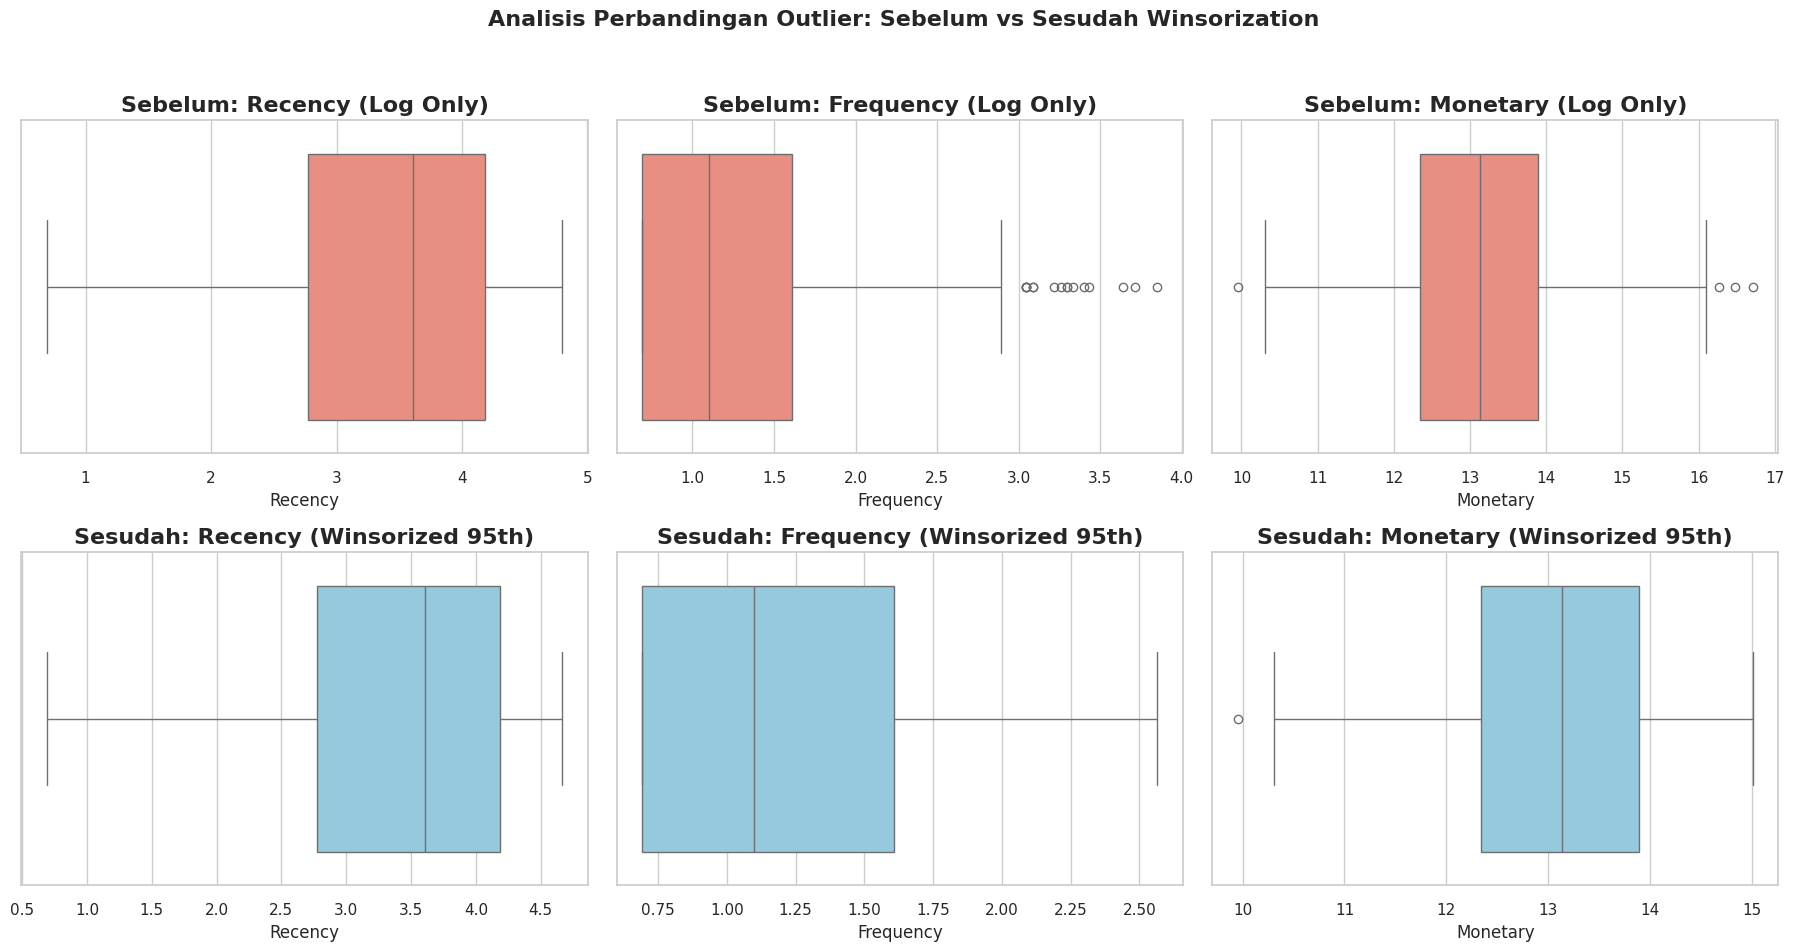


[INFO] Perbandingan Skewness:


,Skewness Sebelum,Skewness Sesudah
Recency,-0.767558,-0.783781
Frequency,1.146473,0.716732
Monetary,0.169487,-0.095336


In [33]:
print("[5] Menangani Outlier menggunakan Teknik Winsorization (Capping)... \n")

# Membuat salinan dataframe untuk proses Winsorization dari data log
df_rfm_winsorized = df_rfm_log.copy()

# Menentukan kolom yang akan di-winsorize
cols_to_winsorize = ['Recency', 'Frequency', 'Monetary']

# Menerapkan Winsorization: Membatasi nilai ekstrem ke persentil ke-95 (Upper Tail)
for col in cols_to_winsorize:
    upper_limit = df_rfm_winsorized[col].quantile(0.95)
    df_rfm_winsorized[col] = df_rfm_winsorized[col].clip(upper=upper_limit)

print(f"[INFO] Nilai ekstrem di atas persentil ke-95 telah disesuaikan (capped).")

# --- VISUALISASI PERBANDINGAN SEBELUM & SESUDAH ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analisis Perbandingan Outlier: Sebelum vs Sesudah Winsorization', fontsize=16, fontweight='bold')

# Plot Baris 1: Sebelum Winsorization (Hanya Log)
for i, col in enumerate(cols_to_winsorize):
    sns.boxplot(data=df_rfm_log, x=col, ax=axes[0, i], color='salmon')
    axes[0, i].set_title(f'Sebelum: {col} (Log Only)')

# Plot Baris 2: Sesudah Winsorization (Log + Winsorized)
for i, col in enumerate(cols_to_winsorize):
    sns.boxplot(data=df_rfm_winsorized, x=col, ax=axes[1, i], color='skyblue')
    axes[1, i].set_title(f'Sesudah: {col} (Winsorized 95th)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- VALIDASI STATISTIK SKEWNESS ---
print("\n[INFO] Perbandingan Skewness:")
skew_before = df_rfm_log[cols_to_winsorize].skew()
skew_after = df_rfm_winsorized[cols_to_winsorize].skew()

skew_comp = pd.DataFrame({
    'Skewness Sebelum': skew_before,
    'Skewness Sesudah': skew_after
})
display(skew_comp)

### **6.5: Standarisasi Skala Fitur Menggunakan Z-Score (*Feature Scaling*)**

In [34]:
print("[3] Menyamakan skala penggaris (Standarisasi) untuk R, F, dan M...")

# Menginisialisasi objek StandardScaler dari Scikit-Learn
scaler = StandardScaler()

# Melakukan standarisasi (Z-Score) pada data yang SUDAH di-Winsorize (df_rfm_winsorized)
df_rfm_scaled_array = scaler.fit_transform(df_rfm_winsorized[fitur_rfm])

# Mengubah hasil array NumPy kembali menjadi Pandas DataFrame
df_rfm_scaled = pd.DataFrame(df_rfm_scaled_array, columns=fitur_rfm)

# Memasukkan kembali kolom Kode_Pelanggan sebagai identitas baris
df_rfm_scaled.insert(0, 'Kode_Pelanggan', df_rfm['Kode_Pelanggan'])

print("- Standarisasi skala (Z-Score) berhasil dieksekusi menggunakan data Winsorized.")

print("\nValidasi Matematis Standarisasi (Mean ≈ 0, Std ≈ 1):")
print("-" * 70)
display(df_rfm_scaled[fitur_rfm].describe().round(3).T[['mean', 'std', 'min', 'max']])

print("\nCuplikan 5 baris pertama data setelah Scaling (df_rfm_scaled):")
display(df_rfm_scaled.head())

[3] Menyamakan skala penggaris (Standarisasi) untuk R, F, dan M...
- Standarisasi skala (Z-Score) berhasil dieksekusi menggunakan data Winsorized.

Validasi Matematis Standarisasi (Mean ≈ 0, Std ≈ 1):
----------------------------------------------------------------------


,mean,std,min,max
Recency,0.0,1.001,-2.742,1.277
Frequency,0.0,1.001,-0.988,2.132
Monetary,-0.0,1.001,-2.926,1.752



Cuplikan 5 baris pertama data setelah Scaling (df_rfm_scaled):


,Kode_Pelanggan,Recency,Frequency,Monetary
0,PLG-0001,-1.814666,-0.312178,-0.100710
1,PLG-0002,0.649077,-0.312178,-0.634266
2,PLG-0003,-0.070571,-0.312178,0.394566
3,PLG-0004,-0.269716,0.167286,-0.435218
4,PLG-0005,1.187319,-0.987945,-0.964306


## **BAB 7: PEMODELAN K-MEANS CLUSTERING**

### **7.1: Penentuan Jumlah Klaster Optimal: Metode Elbow**

[1] Menganalisis jumlah klaster optimal menggunakan Metode Elbow...


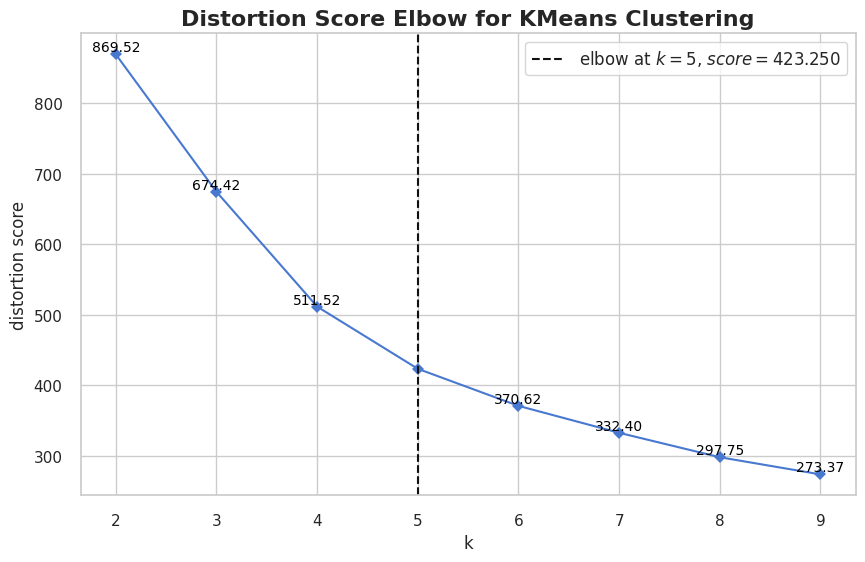

- Rekomendasi matematis jumlah klaster (k) berdasarkan Metode Elbow: 5


In [35]:
print("[1] Menganalisis jumlah klaster optimal menggunakan Metode Elbow...")

# Mengisolasi fitur yang akan digunakan untuk pemodelan dari data yang sudah distandarisasi
X = df_rfm_scaled[['Recency', 'Frequency', 'Monetary']]

# Menginisialisasi model K-Means dasar untuk evaluasi
model_elbow = KMeans(random_state=42, init='k-means++', n_init=10)

# Menggunakan KElbowVisualizer dari Yellowbrick untuk komputasi dan visualisasi otomatis
visualizer_elbow = KElbowVisualizer(model_elbow, k=(2, 10), metric='distortion', timings=False)

plt.figure(figsize=(10, 6))
visualizer_elbow.fit(X)

# Annotate each point with its distortion score, excluding k=5
ax = visualizer_elbow.ax
# Yellowbrick uses k_scores_ to store the metric values for each k
for k_val, score in zip(visualizer_elbow.k_values_, visualizer_elbow.k_scores_):
    if k_val != 5: # Exclude cluster 5 as requested
        ax.text(k_val, score, f'{score:.2f}', ha='center', va='bottom', fontsize=10, color='black')

visualizer_elbow.show()

print(f"- Rekomendasi matematis jumlah klaster (k) berdasarkan Metode Elbow: {visualizer_elbow.elbow_value_}")

### **7.2: Validasi Struktur Klaster: Silhouette Score**

[2] Memvalidasi kualitas kepadatan klaster menggunakan Silhouette Score...
- Rata-rata Silhouette Score untuk k=2 : 0.3808
- Rata-rata Silhouette Score untuk k=3 : 0.3102
- Rata-rata Silhouette Score untuk k=4 : 0.3347
- Rata-rata Silhouette Score untuk k=5 : 0.3058
- Rata-rata Silhouette Score untuk k=6 : 0.2990


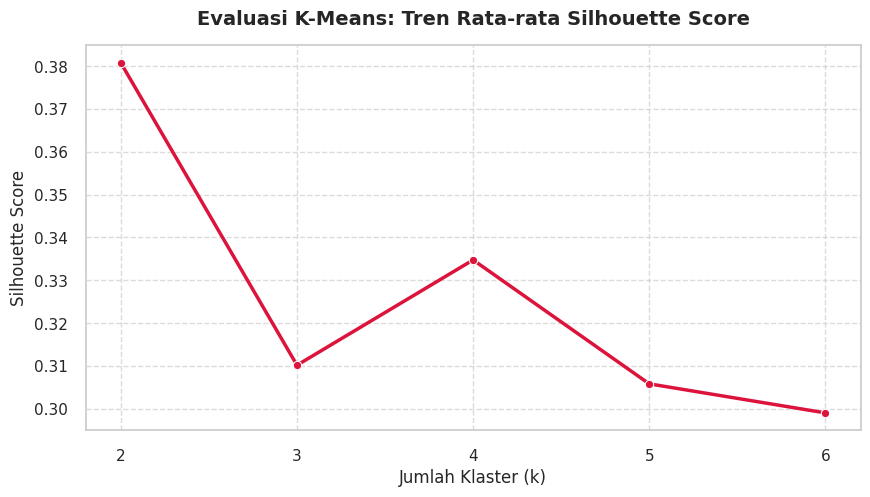

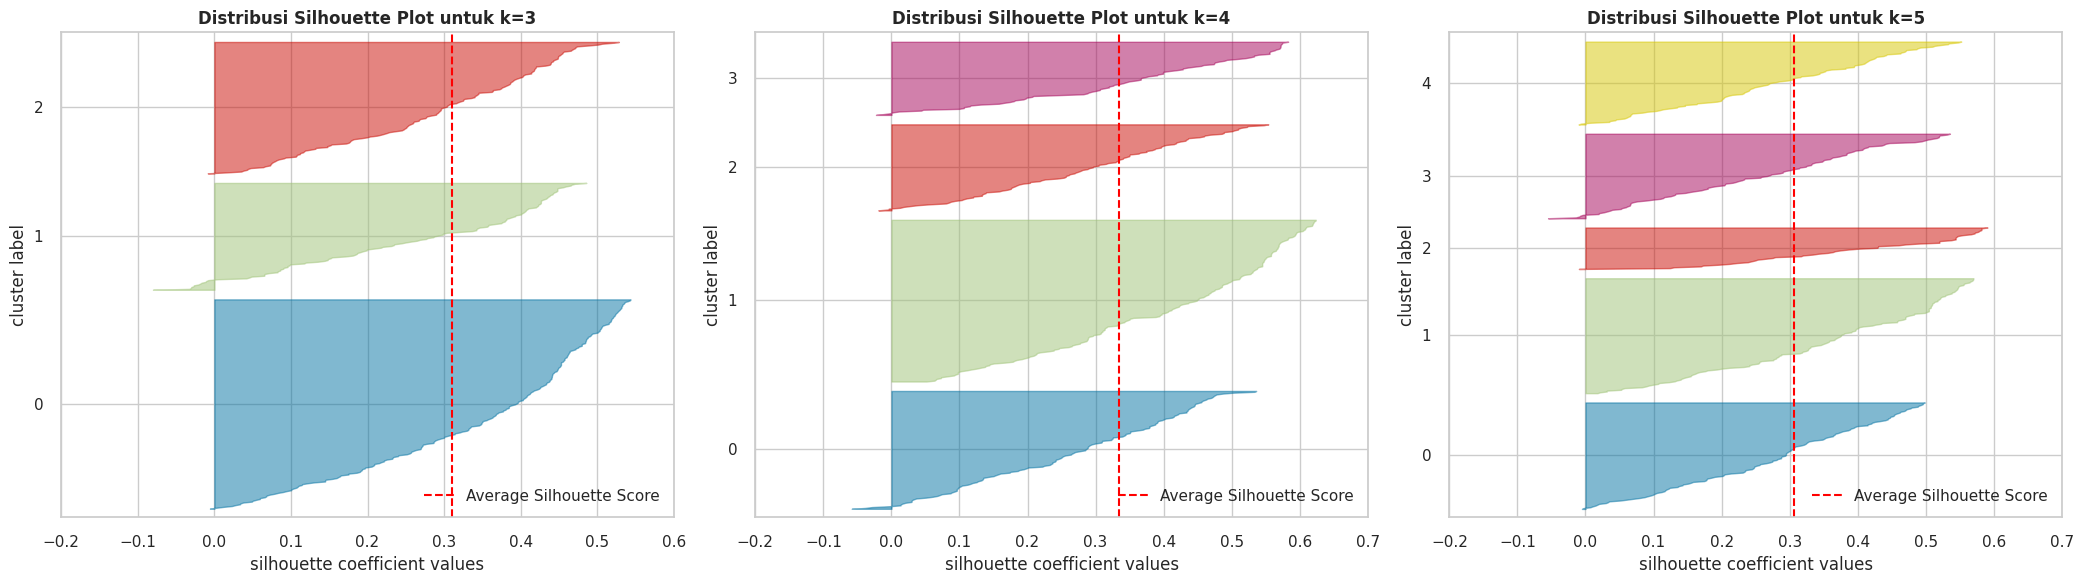

In [36]:
print("[2] Memvalidasi kualitas kepadatan klaster menggunakan Silhouette Score...")

k_range = range(2, 7)
silhouette_scores = []

# Menghitung metrik Silhouette rata-rata untuk setiap k
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    labels_temp = kmeans_temp.fit_predict(X)
    score = silhouette_score(X, labels_temp)
    silhouette_scores.append(score)
    print(f"- Rata-rata Silhouette Score untuk k={k} : {score:.4f}")

# Visualisasi tren nilai Silhouette
plt.figure(figsize=(10, 5))
sns.lineplot(x=list(k_range), y=silhouette_scores, marker='o', color='crimson', linewidth=2.5)
plt.title('Evaluasi K-Means: Tren Rata-rata Silhouette Score', fontsize=14, pad=15)
plt.xlabel('Jumlah Klaster (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualisasi ketebalan dan distribusi internal klaster untuk k=3, k=4 dan k=5
fig, ax = plt.subplots(1, 3, figsize=(21, 6))
for i, k in enumerate([3, 4, 5]):
    model_sil = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    visualizer_sil = SilhouetteVisualizer(model_sil, colors='yellowbrick', ax=ax[i])
    visualizer_sil.fit(X)
    visualizer_sil.finalize()
    ax[i].set_title(f'Distribusi Silhouette Plot untuk k={k}', fontsize=12)

plt.tight_layout()
plt.show()

[2] Memvalidasi kualitas kepadatan klaster menggunakan Silhouette Score...
- Rata-rata Silhouette Score untuk k=2 : 0.3808
- Rata-rata Silhouette Score untuk k=3 : 0.3102
- Rata-rata Silhouette Score untuk k=4 : 0.3347
- Rata-rata Silhouette Score untuk k=5 : 0.3058
- Rata-rata Silhouette Score untuk k=6 : 0.2990


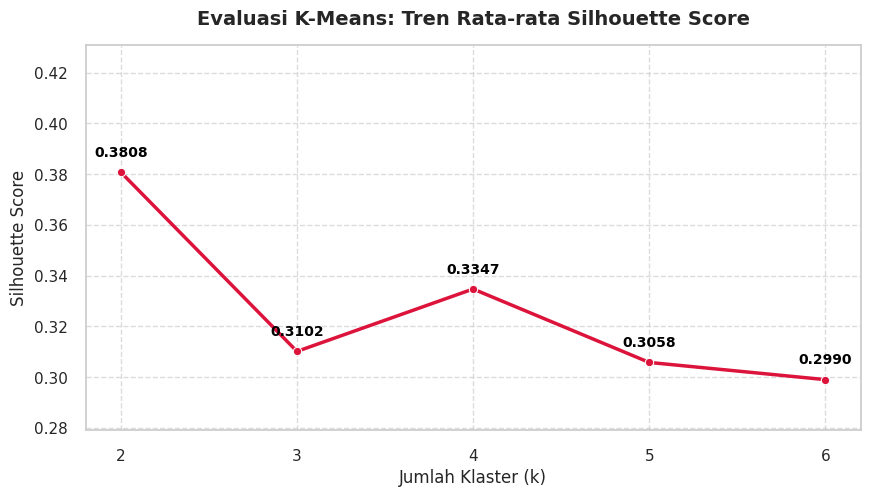

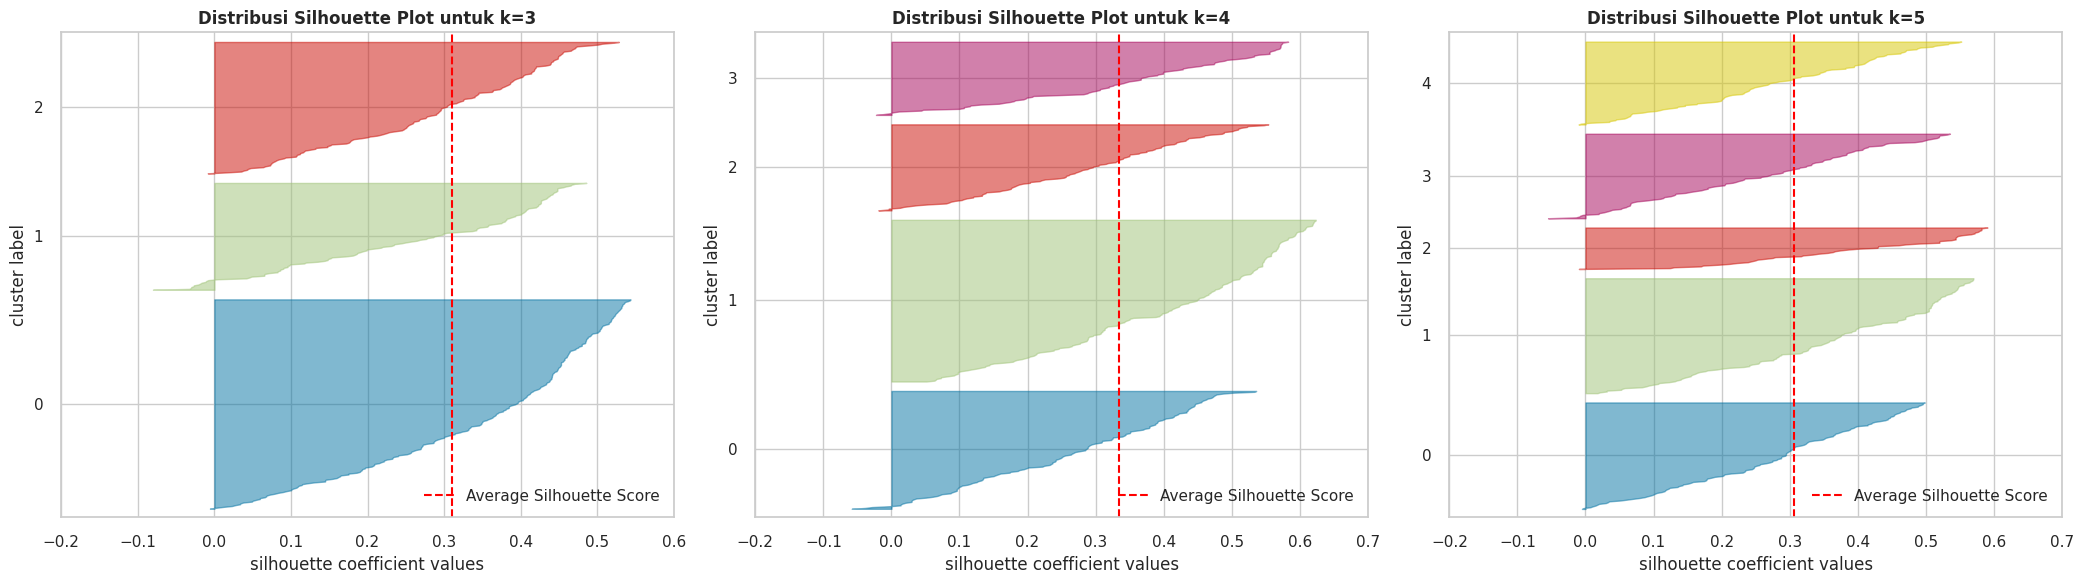

In [37]:
print("[2] Memvalidasi kualitas kepadatan klaster menggunakan Silhouette Score...")

k_range = range(2, 7)
silhouette_scores = []

# Menghitung metrik Silhouette rata-rata untuk setiap k
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    labels_temp = kmeans_temp.fit_predict(X)
    score = silhouette_score(X, labels_temp)
    silhouette_scores.append(score)
    print(f"- Rata-rata Silhouette Score untuk k={k} : {score:.4f}")

# Visualisasi tren nilai Silhouette
plt.figure(figsize=(10, 5))
line_plot = sns.lineplot(x=list(k_range), y=silhouette_scores, marker='o', color='crimson', linewidth=2.5)

# Menambahkan keterangan skor pada setiap titik
for x, y in zip(list(k_range), silhouette_scores):
    plt.text(x, y + 0.005, f'{y:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title('Evaluasi K-Means: Tren Rata-rata Silhouette Score', fontsize=14, pad=15)
plt.xlabel('Jumlah Klaster (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(k_range))
plt.ylim(min(silhouette_scores) - 0.02, max(silhouette_scores) + 0.05)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualisasi ketebalan dan distribusi internal klaster untuk k=3, k=4 dan k=5
fig, ax = plt.subplots(1, 3, figsize=(21, 6))
for i, k in enumerate([3, 4, 5]):
    model_sil = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    visualizer_sil = SilhouetteVisualizer(model_sil, colors='yellowbrick', ax=ax[i])
    visualizer_sil.fit(X)
    visualizer_sil.finalize()
    ax[i].set_title(f'Distribusi Silhouette Plot untuk k={k}', fontsize=12)

plt.tight_layout()
plt.show()

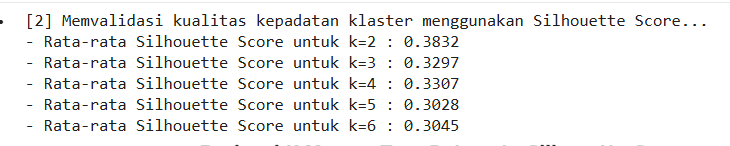

### **7.3: Eksekusi Algoritma K-Means Final**

In [38]:
print("[3] Mengeksekusi model K-Means final pada ruang data (Z-Score)...")

k_optimal = 4

print(f"- Parameter k_optimal ditetapkan pada angka : {k_optimal}")

# Inisialisasi dan eksekusi model final
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, init='k-means++', n_init=10, max_iter=300)
kmeans_final.fit(X)

# Menyimpan hasil penetapan label ke dalam matriks data yang distandarisasi
df_rfm_scaled['Klaster'] = kmeans_final.labels_

print("- Eksekusi tuntas. Label klaster sementara telah disematkan pada data skala.")

[3] Mengeksekusi model K-Means final pada ruang data (Z-Score)...
- Parameter k_optimal ditetapkan pada angka : 4
- Eksekusi tuntas. Label klaster sementara telah disematkan pada data skala.


### **7.4: Penyatuan Label Klaster ke Data Asli**

In [39]:
print("[4] Memetakan kembali label matematis ke data operasional asli (df_rfm)...")

# Memindahkan label klaster dari data Z-Score ke data nominal asli
df_rfm['Klaster'] = df_rfm_scaled['Klaster']

# Modifikasi label: Mengubah basis indeks 0 (0, 1, 2) menjadi basis 1 (1, 2, 3)
# Ini adalah standar operasional agar laporan skripsi/bisnis lebih mudah dibaca.
df_rfm['Klaster'] = df_rfm['Klaster'] + 1
df_rfm_scaled['Klaster'] = df_rfm_scaled['Klaster'] + 1

print("\nCuplikan 5 baris pertama data RFM Asli (Nominal Rupiah) yang telah memiliki label:")
print("=" * 80)
display(df_rfm.head())

print("\nRekapitulasi Distribusi Populasi Pelanggan per Klaster:")
print("-" * 80)
distribusi_klaster = df_rfm['Klaster'].value_counts().sort_index().to_frame(name='Jumlah Populasi')
distribusi_klaster['Persentase Populasi (%)'] = (distribusi_klaster['Jumlah Populasi'] / len(df_rfm) * 100).round(2)
display(distribusi_klaster)

[4] Memetakan kembali label matematis ke data operasional asli (df_rfm)...

Cuplikan 5 baris pertama data RFM Asli (Nominal Rupiah) yang telah memiliki label:


,Kode_Pelanggan,Recency,Frequency,Monetary,Klaster
0,PLG-0001,4,2,445000.0,3
1,PLG-0002,56,2,250000.0,2
2,PLG-0003,27,2,760000.0,1
3,PLG-0004,22,3,310000.0,3
4,PLG-0005,96,1,175000.0,2



Rekapitulasi Distribusi Populasi Pelanggan per Klaster:
--------------------------------------------------------------------------------


,Jumlah Populasi,Persentase Populasi (%)
Klaster,,
1,138,26.85
2,189,36.77
3,101,19.65
4,86,16.73


## **BAB 8: EVALUASI DAN INTERPRETASI PROFIL KLASTER**


### **8.1: Analisis Karakteristik Agregat Tiap Klaster**

In [40]:
print("[1] Menganalisis karakteristik agregat (Rata-rata & Median) tiap klaster...")

# Menghitung nilai rata-rata (mean) untuk melihat tendensi pusat profil
rfm_mean = df_rfm.groupby('Klaster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

# Menghitung nilai tengah (median) untuk menghindari bias dari pelanggan outlier/VIP
rfm_median = df_rfm.groupby('Klaster')[['Recency', 'Frequency', 'Monetary']].median().round(2)

# Menggabungkan hasil mean dan median ke dalam satu tabel ringkasan komprehensif
rfm_summary = pd.concat([rfm_mean, rfm_median], axis=1, keys=['Rata-rata (Mean)', 'Nilai Tengah (Median)'])

print("- Tabel Karakteristik Agregat RFM per Klaster berhasil dibuat.")
display(rfm_summary)

[1] Menganalisis karakteristik agregat (Rata-rata & Median) tiap klaster...
- Tabel Karakteristik Agregat RFM per Klaster berhasil dibuat.


Rata-rata (Mean)                       Nilai Tengah (Median)  \
                 Recency Frequency    Monetary               Recency   
Klaster                                                                
1                  57.88      3.47  1293052.37                  53.0   
2                  61.92      1.30   226489.29                  59.0   
3                  10.42      2.46   503107.67                  10.0   
4                  15.19     12.23  2830601.77                  12.0   

                              
        Frequency   Monetary  
Klaster                       
1             3.0   920000.0  
2             1.0   195000.0  
3             2.0   445000.0  
4             9.0  1790000.0

### **8.2: Visualisasi Sebaran Klaster (*Scatter Plot* Multi-dimensi)**

In [41]:
# 1. Hitung rata-rata RFM per klaster untuk membaca karakteristik asli bentukan mesin
cluster_profile = df_rfm.groupby('Klaster')[['Recency', 'Frequency', 'Monetary']].mean()

# 2. LOGIKA PEMETAAN DINAMIS (Anti-Hardcode)
# Urutkan klaster berdasarkan Monetary (Pendapatan) dari tertinggi ke terendah
cluster_profile_sorted = cluster_profile.sort_values(by='Monetary', ascending=False)

# Klaster dengan Monetary tertinggi ke-1 pasti VIP
id_vip = cluster_profile_sorted.index[0]

# Klaster dengan Monetary tertinggi ke-2 pasti Loyal & High Value
id_loyal = cluster_profile_sorted.index[1]

# Sisa 2 klaster dengan Monetary terendah, kita bedakan berdasarkan Recency
sisa_id = cluster_profile_sorted.index[2:]

# Yang Recency-nya lebih kecil (lebih baru datang) adalah Pelanggan Baru/Aktif
# Yang Recency-nya lebih besar (sudah lama hilang) adalah Pelanggan Berisiko
if cluster_profile.loc[sisa_id[0], 'Recency'] < cluster_profile.loc[sisa_id[1], 'Recency']:
    id_baru = sisa_id[0]
    id_risiko = sisa_id[1]
else:
    id_baru = sisa_id[1]
    id_risiko = sisa_id[0]

# 3. Buat dictionary pemetaan secara otomatis berdasarkan ID yang sudah diurutkan
pemetaan_segmen = {
    id_vip: 'Pelanggan VIP (Champions)',
    id_loyal: 'Pelanggan Loyal & High Value',
    id_baru: 'Pelanggan Baru/Aktif',
    id_risiko: 'Pelanggan Berisiko (At-Risk)'
}

print("Pemetaan otomatis yang terbentuk:", pemetaan_segmen)

# 4. Mengaplikasikan pemetaan nama persona ke DataFrame utama RFM
df_rfm['Klaster'].map(pemetaan_segmen)

Pemetaan otomatis yang terbentuk: {np.int32(4): 'Pelanggan VIP (Champions)', np.int32(1): 'Pelanggan Loyal & High Value', np.int32(3): 'Pelanggan Baru/Aktif', np.int32(2): 'Pelanggan Berisiko (At-Risk)'}


,Klaster
0,Pelanggan Baru/Aktif
1,Pelanggan Berisiko (At-Risk)
2,Pelanggan Loyal & High Value
3,Pelanggan Baru/Aktif
4,Pelanggan Berisiko (At-Risk)
...,...
509,Pelanggan Loyal & High Value
510,Pelanggan Loyal & High Value
511,Pelanggan Loyal & High Value
512,Pelanggan Berisiko (At-Risk)


[2] Menjalankan visualisasi sebaran klaster menggunakan Nama Persona Bisnis...


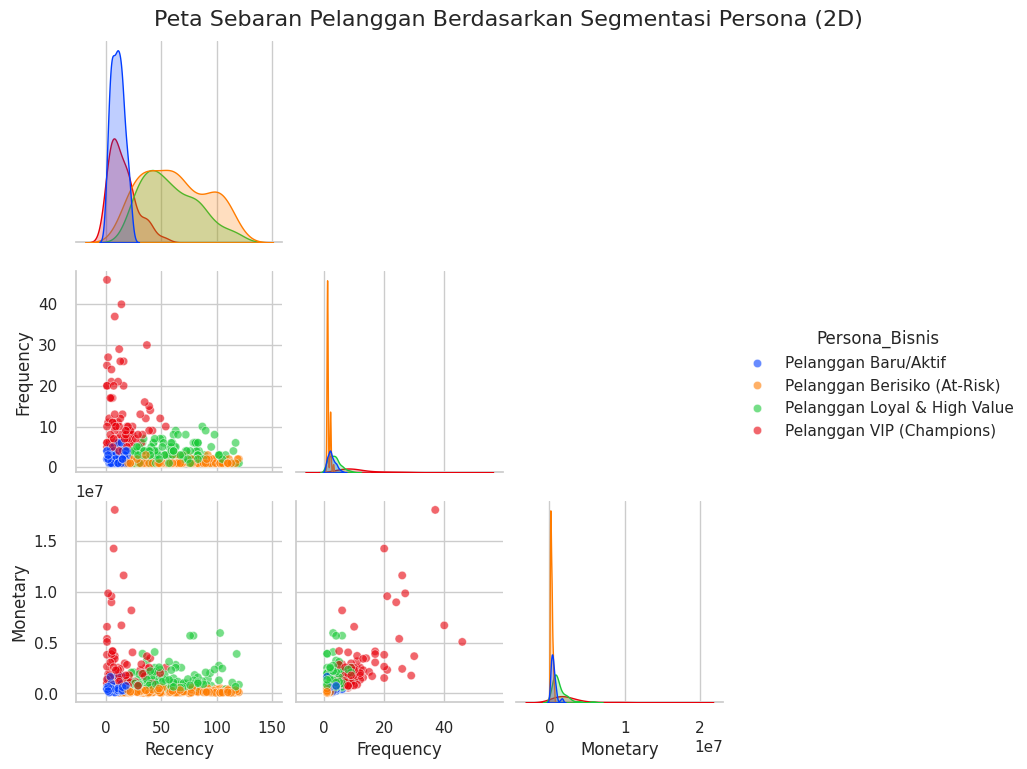

- Membangun Visualisasi 3D Scatter Plot Berdasarkan Persona...


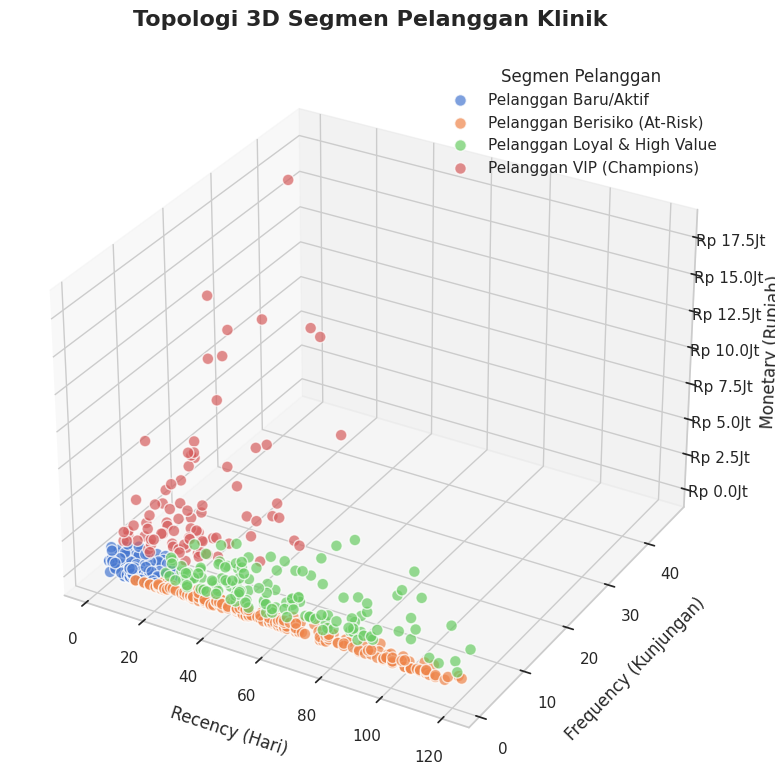

In [42]:
print("[2] Menjalankan visualisasi sebaran klaster menggunakan Nama Persona Bisnis...")

# 1. Pastikan mapping persona sudah diaplikasikan ke dataframe
# Menggunakan logika yang sudah Anda buat sebelumnya di cell ringkasan
if 'Persona_Bisnis' not in df_rfm.columns:
    df_rfm['Persona_Bisnis'] = df_rfm['Klaster'].map(pemetaan_segmen)

# 2. Menyiapkan palet warna berdasarkan Nama Persona agar konsisten
# Kita ambil unique values dari Persona_Bisnis untuk mapping warna
persona_unique = df_rfm['Persona_Bisnis'].unique()
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']
warna_persona = {persona: colors[i % len(colors)] for i, persona in enumerate(persona_unique)}

# 3. Membuat Pairplot dengan Hue = Persona_Bisnis
fig_pair = sns.pairplot(df_rfm,
                        vars=['Recency', 'Frequency', 'Monetary'],
                        hue='Persona_Bisnis',
                        palette='bright', # Menggunakan palet standar agar kontras
                        diag_kind='kde',
                        corner=True,
                        plot_kws={'alpha': 0.6, 'edgecolor': 'w'})

fig_pair.fig.suptitle('Peta Sebaran Pelanggan Berdasarkan Segmentasi Persona (2D)', y=1.02, fontsize=16)
plt.show()

print("- Membangun Visualisasi 3D Scatter Plot Berdasarkan Persona...")

# 4. Membuat Scatter Plot 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for persona_name in df_rfm['Persona_Bisnis'].unique():
    data_subset = df_rfm[df_rfm['Persona_Bisnis'] == persona_name]
    ax.scatter(data_subset['Recency'],
               data_subset['Frequency'],
               data_subset['Monetary'],
               label=persona_name,
               alpha=0.7,
               edgecolors='w',
               s=70)

ax.set_xlabel('Recency (Hari)', labelpad=15)
ax.set_ylabel('Frequency (Kunjungan)', labelpad=15)
ax.set_zlabel('Monetary (Rupiah)', labelpad=15)
ax.set_title('Topologi 3D Segmen Pelanggan Klinik', fontsize=16, pad=20)
ax.legend(title="Segmen Pelanggan", loc='upper right')

# Format mata uang pada sumbu Z
ax.zaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'Rp {x*1e-6:,.1f}Jt'))

plt.tight_layout()
plt.show()

In [43]:
# print("[2] Menjalankan visualisasi sebaran klaster menggunakan Seaborn Pairplot dan 3D Plot...")

# # # Buat mapping nama
# # nama_klaster = {0: 'VIP', 1: 'Loyal', 2: 'Baru', 3: 'Berisiko'}

# # # Ganti label di dataframe sebelum di-plot
# # df_rfm['Nama_Klaster'] = df_rfm['Klaster'].map(nama_klaster)


# # Gunakan 'Nama_Klaster' sebagai hue di seaborn/plotly

# # Menyiapkan warna palet yang elegan untuk 4 klaster (Ditambah warna untuk klaster 4)
# warna_klaster = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}

# # Membuat Pairplot untuk melihat batas pemisahan klaster di setiap kombinasi 2 Dimensi
# fig_pair = sns.pairplot(df_rfm, vars=['Recency', 'Frequency', 'Monetary'],
#                         hue='Klaster', palette=warna_klaster,
#                         diag_kind='kde', corner=True, plot_kws={'alpha': 0.7, 'edgecolor': 'w'})

# fig_pair.fig.suptitle('Peta Sebaran Pelanggan Berdasarkan Matriks RFM (2D Proyeksi)', y=1.02, fontsize=16)
# plt.show()

# print("- Membangun Visualisasi 3D Scatter Plot (Ruang Angkasa RFM)...")

# # Membuat Scatter Plot 3D untuk melihat topologi klaster secara holistik
# fig = plt.figure(figsize=(12, 8))
# ax = fig.add_subplot(111, projection='3d')

# for klaster_id in sorted(df_rfm['Klaster'].unique()):
#     data_subset = df_rfm[df_rfm['Klaster'] == klaster_id]
#     ax.scatter(data_subset['Recency'], data_subset['Frequency'], data_subset['Monetary'],
#                label=f'Klaster {klaster_id}', color=warna_klaster[klaster_id],
#                alpha=0.8, edgecolors='w', s=60, depthshade=True)

# ax.set_xlabel('Recency (Hari)', labelpad=15, fontsize=11)
# ax.set_ylabel('Frequency (Kunjungan)', labelpad=15, fontsize=11)
# ax.set_zlabel('Monetary (Rupiah)', labelpad=15, fontsize=11)
# ax.set_title('Visualisasi 3D Struktur Klaster Pelanggan', fontsize=16, pad=20)
# ax.legend(title="Identitas Klaster", loc='upper right')

# # Mengubah format sumbu Z (Monetary) agar lebih mudah dibaca (dalam format Jutaan)
# ax.zaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'Rp {x*1e-6:,.0f}M'))

# plt.tight_layout()
# plt.show()

### **8.3: Pembuatan Snake Plot dan Peta Panas (*Heatmap*)**

[3] Membangun Snake Plot dan Heatmap menggunakan Nama Persona Bisnis...


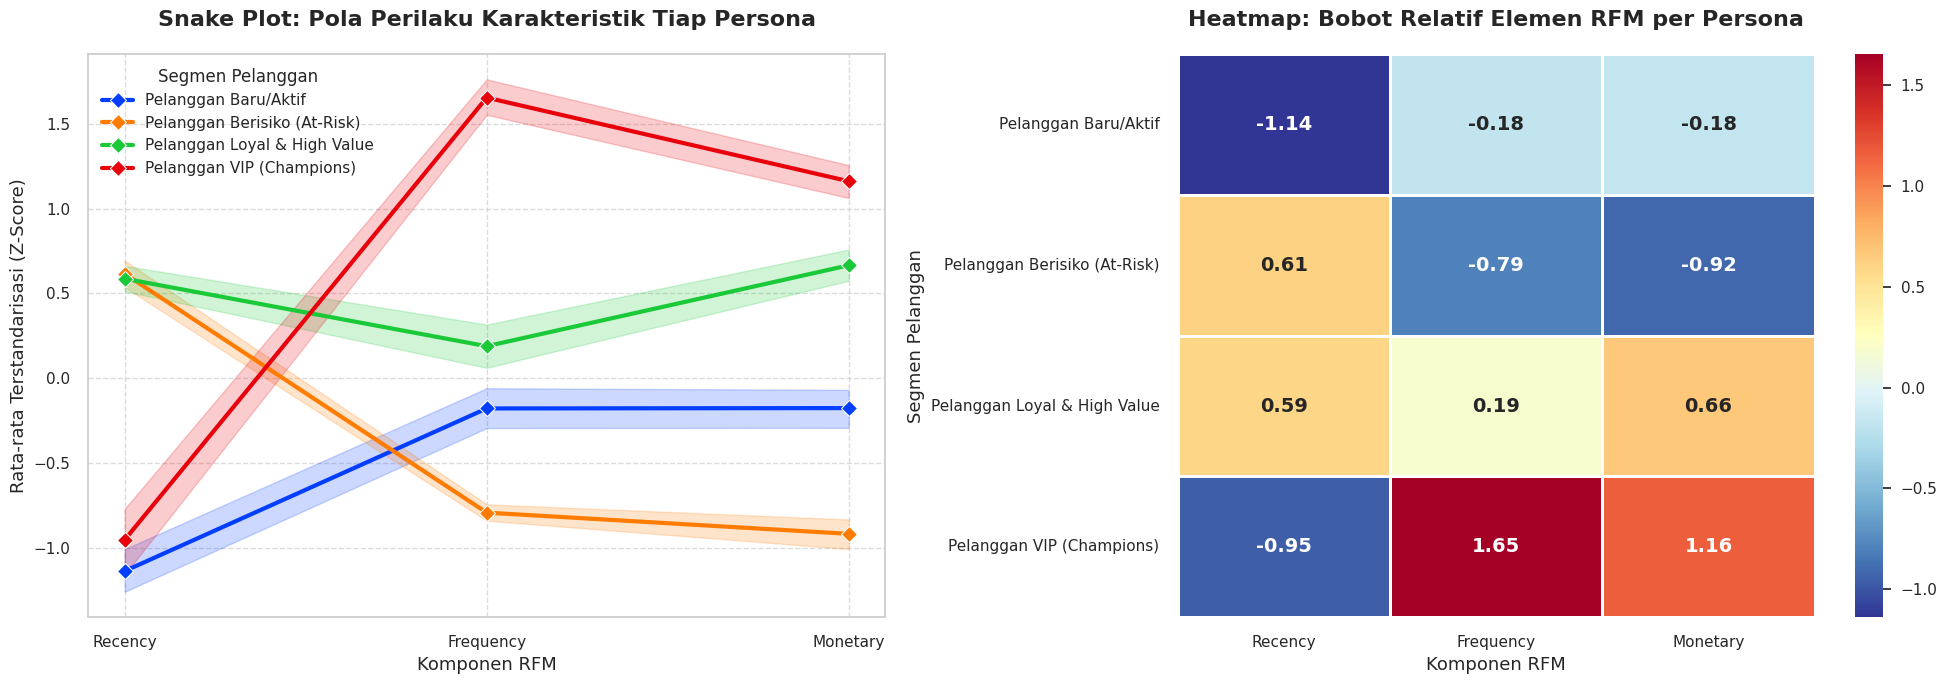

In [44]:
print("[3] Membangun Snake Plot dan Heatmap menggunakan Nama Persona Bisnis...")

# 1. Menyiapkan Data untuk Snake Plot
# Kita menggunakan Persona_Bisnis agar legenda menampilkan nama, bukan angka
df_rfm_melted = pd.melt(df_rfm_scaled.merge(df_rfm[['Kode_Pelanggan', 'Persona_Bisnis']], on='Kode_Pelanggan'),
                        id_vars=['Kode_Pelanggan', 'Persona_Bisnis'],
                        value_vars=['Recency', 'Frequency', 'Monetary'],
                        var_name='Metrik_RFM',
                        value_name='Nilai_Z_Score')

fig, ax = plt.subplots(1, 2, figsize=(20, 7))

# Grafik 1: Pembuatan Snake Plot dengan Persona Bisnis
sns.lineplot(data=df_rfm_melted, x='Metrik_RFM', y='Nilai_Z_Score', hue='Persona_Bisnis',
             palette='bright', marker='D', markersize=8, linewidth=3, ax=ax[0])
ax[0].set_title('Snake Plot: Pola Perilaku Karakteristik Tiap Persona', fontsize=16, pad=20)
ax[0].set_xlabel('Komponen RFM', fontsize=13)
ax[0].set_ylabel('Rata-rata Terstandarisasi (Z-Score)', fontsize=13)
ax[0].grid(True, linestyle='--', alpha=0.7)
ax[0].legend(title='Segmen Pelanggan')

# 2. Menyiapkan Data untuk Heatmap
# Mengelompokkan berdasarkan Persona_Bisnis untuk label sumbu Y yang informatif
cluster_avg_persona = df_rfm_scaled.merge(df_rfm[['Kode_Pelanggan', 'Persona_Bisnis']], on='Kode_Pelanggan')\
                      .groupby('Persona_Bisnis')[['Recency', 'Frequency', 'Monetary']].mean()

# Grafik 2: Pembuatan Heatmap dengan Nama Persona
sns.heatmap(cluster_avg_persona, cmap='RdYlBu_r', annot=True, fmt='.2f',
            linewidths=2, linecolor='white', annot_kws={"size": 14, "weight": "bold"}, ax=ax[1])
ax[1].set_title('Heatmap: Bobot Relatif Elemen RFM per Persona', fontsize=16, pad=20)
ax[1].set_xlabel('Komponen RFM', fontsize=13)
ax[1].set_ylabel('Segmen Pelanggan', fontsize=13)

plt.tight_layout()
plt.show()

In [45]:
# print("[3] Membangun Snake Plot dan Heatmap menggunakan basis data terstandarisasi (Z-Score)...")

# # 1. Menyiapkan Data untuk Snake Plot (Meleburkan struktur kolom menjadi baris / Unpivoting)
# df_rfm_melted = pd.melt(df_rfm_scaled,
#                         id_vars=['Kode_Pelanggan', 'Klaster'],
#                         value_vars=['Recency', 'Frequency', 'Monetary'],
#                         var_name='Metrik_RFM',
#                         value_name='Nilai_Z_Score')

# fig, ax = plt.subplots(1, 2, figsize=(20, 7))

# # Grafik 1: Pembuatan Snake Plot
# sns.lineplot(data=df_rfm_melted, x='Metrik_RFM', y='Nilai_Z_Score', hue='Klaster',
#              palette=warna_klaster, marker='D', markersize=8, linewidth=3, ax=ax[0])
# ax[0].set_title('Snake Plot: Pola Perilaku Karakteristik Tiap Klaster', fontsize=16, pad=20)
# ax[0].set_xlabel('Komponen RFM', fontsize=13)
# ax[0].set_ylabel('Rata-rata Terstandarisasi (Z-Score)', fontsize=13)
# ax[0].grid(True, linestyle='--', alpha=0.7)

# # 2. Menyiapkan Data untuk Heatmap (Menghitung rata-rata Z-Score absolut per klaster)
# cluster_avg_scaled = df_rfm_scaled.groupby('Klaster')[['Recency', 'Frequency', 'Monetary']].mean()

# # Grafik 2: Pembuatan Heatmap
# sns.heatmap(cluster_avg_scaled, cmap='RdYlBu_r', annot=True, fmt='.2f',
#             linewidths=2, linecolor='white', annot_kws={"size": 14, "weight": "bold"}, ax=ax[1])
# ax[1].set_title('Heatmap: Bobot Relatif Elemen RFM per Klaster', fontsize=16, pad=20)
# ax[1].set_xlabel('Komponen RFM', fontsize=13)
# ax[1].set_ylabel('Identitas Klaster', fontsize=13)

# plt.tight_layout()
# plt.show()

### **8.4: Penamaan Segmen dan Ringkasan Wawasan Bisnis**

[4] Memetakan identitas bisnis (Segment Naming) secara DINAMIS...
Pemetaan otomatis yang terbentuk: {np.int32(4): 'Pelanggan VIP (Champions)', np.int32(1): 'Pelanggan Loyal & High Value', np.int32(3): 'Pelanggan Baru/Aktif', np.int32(2): 'Pelanggan Berisiko (At-Risk)'}

=== TABEL RINGKASAN WAWASAN BISNIS (BUSINESS INSIGHT SUMMARY) ===


,Persona_Bisnis,Total_Populasi,%_Populasi,Rata_Rata_Recency (Hari),Rata_Rata_Frequency (Kunjungan),Total_Sumbangan_Pendapatan (Rp)
0,Pelanggan VIP (Champions),86,16.73%,15.19,12.23,"Rp 243,431,752"
1,Pelanggan Loyal & High Value,138,26.85%,57.88,3.47,"Rp 178,441,227"
2,Pelanggan Baru/Aktif,101,19.65%,10.42,2.46,"Rp 50,813,875"
3,Pelanggan Berisiko (At-Risk),189,36.77%,61.92,1.30,"Rp 42,806,475"


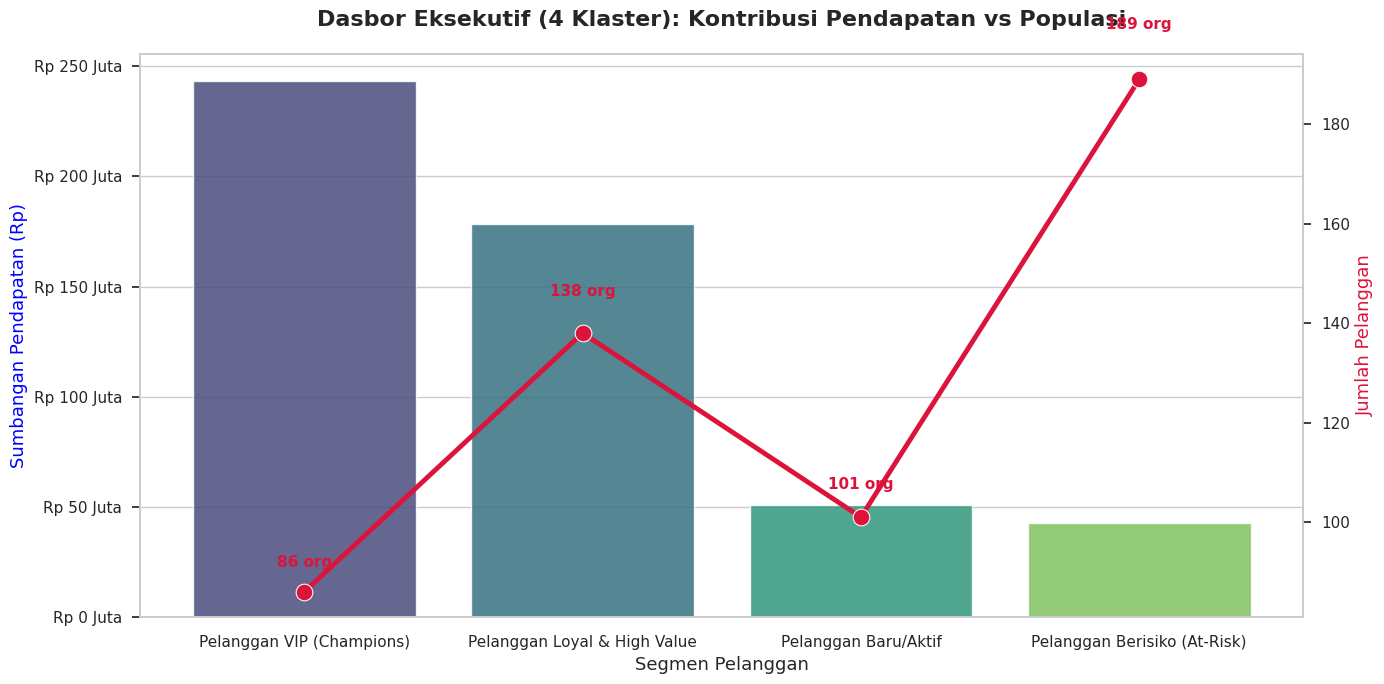

In [46]:
print("[4] Memetakan identitas bisnis (Segment Naming) secara DINAMIS...")

# 1. Hitung rata-rata RFM per klaster untuk membaca karakteristik asli bentukan mesin
cluster_profile = df_rfm.groupby('Klaster')[['Recency', 'Frequency', 'Monetary']].mean()

# 2. LOGIKA PEMETAAN DINAMIS (Anti-Hardcode)
# Urutkan klaster berdasarkan Monetary (Pendapatan) dari tertinggi ke terendah
cluster_profile_sorted = cluster_profile.sort_values(by='Monetary', ascending=False)

# Klaster dengan Monetary tertinggi ke-1 pasti VIP
id_vip = cluster_profile_sorted.index[0]

# Klaster dengan Monetary tertinggi ke-2 pasti Loyal & High Value
id_loyal = cluster_profile_sorted.index[1]

# Sisa 2 klaster dengan Monetary terendah, kita bedakan berdasarkan Recency
sisa_id = cluster_profile_sorted.index[2:]

# Yang Recency-nya lebih kecil (lebih baru datang) adalah Pelanggan Baru/Aktif
# Yang Recency-nya lebih besar (sudah lama hilang) adalah Pelanggan Berisiko
if cluster_profile.loc[sisa_id[0], 'Recency'] < cluster_profile.loc[sisa_id[1], 'Recency']:
    id_baru = sisa_id[0]
    id_risiko = sisa_id[1]
else:
    id_baru = sisa_id[1]
    id_risiko = sisa_id[0]

# 3. Buat dictionary pemetaan secara otomatis berdasarkan ID yang sudah diurutkan
pemetaan_segmen = {
    id_vip: 'Pelanggan VIP (Champions)',
    id_loyal: 'Pelanggan Loyal & High Value',
    id_baru: 'Pelanggan Baru/Aktif',
    id_risiko: 'Pelanggan Berisiko (At-Risk)'
}

print("Pemetaan otomatis yang terbentuk:", pemetaan_segmen)

# 4. Mengaplikasikan pemetaan nama persona ke DataFrame utama RFM
df_rfm['Persona_Bisnis'] = df_rfm['Klaster'].map(pemetaan_segmen)

# =============================================================================
# Lanjutkan dengan kode agregasi Anda di bawah ini
# =============================================================================

# Membuat agregasi final untuk Ringkasan Wawasan Bisnis (Business Insight Summary)
ringkasan_bisnis = df_rfm.groupby('Persona_Bisnis').agg({
    'Kode_Pelanggan': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'sum'
}).reset_index()

# Mengganti nama kolom agar sesuai dengan format laporan manajerial
ringkasan_bisnis.rename(columns={
    'Kode_Pelanggan': 'Total_Populasi',
    'Recency': 'Rata_Rata_Recency (Hari)',
    'Frequency': 'Rata_Rata_Frequency (Kunjungan)',
    'Monetary': 'Total_Sumbangan_Pendapatan (Rp)'
}, inplace=True)

# Menambahkan kolom persentase populasi
ringkasan_bisnis['%_Populasi'] = (ringkasan_bisnis['Total_Populasi'] / ringkasan_bisnis['Total_Populasi'].sum()) * 100

# Mengurutkan klaster berdasarkan kontribusi pendapatan terbesar ke terkecil
ringkasan_bisnis = ringkasan_bisnis.sort_values(by='Total_Sumbangan_Pendapatan (Rp)', ascending=False).reset_index(drop=True)

# Reorder columns
ringkasan_bisnis = ringkasan_bisnis[['Persona_Bisnis', 'Total_Populasi', '%_Populasi', 'Rata_Rata_Recency (Hari)', 'Rata_Rata_Frequency (Kunjungan)', 'Total_Sumbangan_Pendapatan (Rp)']]

print("\n=== TABEL RINGKASAN WAWASAN BISNIS (BUSINESS INSIGHT SUMMARY) ===")
print("=" * 90)

# Menampilkan tabel dengan styling profesional
display(ringkasan_bisnis.style
    .format({
        'Total_Populasi': '{:,.0f}',
        '%_Populasi': '{:.2f}%',
        'Rata_Rata_Recency (Hari)': '{:.2f}',
        'Rata_Rata_Frequency (Kunjungan)': '{:.2f}',
        'Total_Sumbangan_Pendapatan (Rp)': 'Rp {:,.0f}'
    })
    .background_gradient(subset=['Total_Sumbangan_Pendapatan (Rp)'], cmap='YlGnBu')
    .background_gradient(subset=['Total_Populasi', '%_Populasi'], cmap='Blues')
    .set_properties(**{'text-align': 'center'})
    .set_caption("Ringkasan Profil Pelanggan Berdasarkan 4 Segmen RFM"))

# Pembuatan visualisasi Dasbor Eksekutif
fig, ax1 = plt.subplots(figsize=(14, 7))

# Layer 1 (Bar Chart): Menampilkan Total Kontribusi Pendapatan
sns.barplot(data=ringkasan_bisnis, x='Persona_Bisnis', y='Total_Sumbangan_Pendapatan (Rp)',
            palette='viridis', alpha=0.85, ax=ax1)
ax1.set_title('Dasbor Eksekutif (4 Klaster): Kontribusi Pendapatan vs Populasi', fontsize=16, pad=20)
ax1.set_xlabel('Segmen Pelanggan', fontsize=13)
ax1.set_ylabel('Sumbangan Pendapatan (Rp)', fontsize=13, color='blue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'Rp {x*1e-6:,.0f} Juta'))

# Layer 2 (Line Chart): Menampilkan Total Populasi Pelanggan
ax2 = ax1.twinx()
sns.lineplot(data=ringkasan_bisnis, x='Persona_Bisnis', y='Total_Populasi',
             color='crimson', marker='o', markersize=12, linewidth=3.5, ax=ax2)
ax2.set_ylabel('Jumlah Pelanggan', fontsize=13, color='crimson')
ax2.grid(False)

# Anotasi angka
for x, y in zip(range(len(ringkasan_bisnis)), ringkasan_bisnis['Total_Populasi']):
    ax2.text(x, y + (y * 0.05), f'{y} org', color='crimson', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [47]:
# print("[4] Memetakan identitas bisnis (Segment Naming) ke dalam struktur data...")

# # CATATAN STRATEGIS:
# # Berdasarkan k=4, kita mendefinisikan 4 persona bisnis yang sesuai dengan karakteristik R, F, M.
# pemetaan_segmen = {
#     1: 'Pelanggan Loyal & High Value',
#     2: 'Pelanggan Baru/Aktif',
#     3: 'Pelanggan VIP (Champions)',
#     4: 'Pelanggan Berisiko (At-Risk)'
# }

# # Mengaplikasikan pemetaan nama persona ke DataFrame utama RFM
# df_rfm['Persona_Bisnis'] = df_rfm['Klaster'].map(pemetaan_segmen)

# # Membuat agregasi final untuk Ringkasan Wawasan Bisnis (Business Insight Summary)
# ringkasan_bisnis = df_rfm.groupby('Persona_Bisnis').agg({
#     'Kode_Pelanggan': 'count',       # Mengukur volume populasi pelanggan
#     'Recency': 'mean',               # Rata-rata hari sejak kunjungan terakhir
#     'Frequency': 'mean',             # Rata-rata jumlah kedatangan
#     'Monetary': 'sum'                # Total Rupiah yang disumbangkan oleh klaster ini
# }).reset_index()

# # Mengganti nama kolom agar sesuai dengan format laporan manajerial
# ringkasan_bisnis.rename(columns={
#     'Kode_Pelanggan': 'Total_Populasi',
#     'Recency': 'Rata_Rata_Recency (Hari)',
#     'Frequency': 'Rata_Rata_Frequency (Kunjungan)',
#     'Monetary': 'Total_Sumbangan_Pendapatan (Rp)'
# }, inplace=True)

# # Menambahkan kolom persentase populasi
# ringkasan_bisnis['%_Populasi'] = (ringkasan_bisnis['Total_Populasi'] / ringkasan_bisnis['Total_Populasi'].sum()) * 100

# # Mengurutkan klaster berdasarkan kontribusi pendapatan terbesar ke terkecil
# ringkasan_bisnis = ringkasan_bisnis.sort_values(by='Total_Sumbangan_Pendapatan (Rp)', ascending=False).reset_index(drop=True)

# # Reorder columns
# ringkasan_bisnis = ringkasan_bisnis[['Persona_Bisnis', 'Total_Populasi', '%_Populasi', 'Rata_Rata_Recency (Hari)', 'Rata_Rata_Frequency (Kunjungan)', 'Total_Sumbangan_Pendapatan (Rp)']]

# print("\n=== TABEL RINGKASAN WAWASAN BISNIS (BUSINESS INSIGHT SUMMARY) ===")
# print("=" * 90)

# # Menampilkan tabel dengan styling profesional
# display(ringkasan_bisnis.style
#     .format({
#         'Total_Populasi': '{:,.0f}',
#         '%_Populasi': '{:.2f}%',
#         'Rata_Rata_Recency (Hari)': '{:.2f}',
#         'Rata_Rata_Frequency (Kunjungan)': '{:.2f}',
#         'Total_Sumbangan_Pendapatan (Rp)': 'Rp {:,.0f}'
#     })
#     .background_gradient(subset=['Total_Sumbangan_Pendapatan (Rp)'], cmap='YlGnBu')
#     .background_gradient(subset=['Total_Populasi', '%_Populasi'], cmap='Blues')
#     .set_properties(**{'text-align': 'center'})
#     .set_caption("Ringkasan Profil Pelanggan Berdasarkan 4 Segmen RFM"))

# # Pembuatan visualisasi Dasbor Eksekutif
# fig, ax1 = plt.subplots(figsize=(14, 7))

# # Layer 1 (Bar Chart): Menampilkan Total Kontribusi Pendapatan
# sns.barplot(data=ringkasan_bisnis, x='Persona_Bisnis', y='Total_Sumbangan_Pendapatan (Rp)',
#             palette='viridis', alpha=0.85, ax=ax1)
# ax1.set_title('Dasbor Eksekutif (4 Klaster): Kontribusi Pendapatan vs Populasi', fontsize=16, pad=20)
# ax1.set_xlabel('Segmen Pelanggan', fontsize=13)
# ax1.set_ylabel('Sumbangan Pendapatan (Rp)', fontsize=13, color='blue')
# ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'Rp {x*1e-6:,.0f} Juta'))

# # Layer 2 (Line Chart): Menampilkan Total Populasi Pelanggan
# ax2 = ax1.twinx()
# sns.lineplot(data=ringkasan_bisnis, x='Persona_Bisnis', y='Total_Populasi',
#              color='crimson', marker='o', markersize=12, linewidth=3.5, ax=ax2)
# ax2.set_ylabel('Jumlah Pelanggan', fontsize=13, color='crimson')
# ax2.grid(False)

# # Anotasi angka
# for x, y in zip(range(len(ringkasan_bisnis)), ringkasan_bisnis['Total_Populasi']):
#     ax2.text(x, y + (y * 0.05), f'{y} org', color='crimson', ha='center', va='bottom', fontweight='bold', fontsize=11)

# plt.tight_layout()
# plt.show()

In [48]:
# print("[4] Memetakan identitas bisnis (Segment Naming) ke dalam struktur data...")

# # CATATAN STRATEGIS:
# # Berdasarkan k=4, kita mendefinisikan 4 persona bisnis yang sesuai dengan karakteristik R, F, M.
# pemetaan_segmen = {
#     1: 'Pelanggan Baru/Aktif',
#     2: 'Pelanggan Berisiko (At-Risk)',
#     3: 'Pelanggan VIP (Champions)',
#     4: 'Pelanggan Loyal & High Value'
# }

# # Mengaplikasikan pemetaan nama persona ke DataFrame utama RFM
# df_rfm['Persona_Bisnis'] = df_rfm['Klaster'].map(pemetaan_segmen)

# # Membuat agregasi final untuk Ringkasan Wawasan Bisnis (Business Insight Summary)
# ringkasan_bisnis = df_rfm.groupby('Persona_Bisnis').agg({
#     'Kode_Pelanggan': 'count',       # Mengukur volume populasi pelanggan
#     'Recency': 'mean',               # Rata-rata hari sejak kunjungan terakhir
#     'Frequency': 'mean',             # Rata-rata jumlah kedatangan
#     'Monetary': 'sum'                # Total Rupiah yang disumbangkan oleh klaster ini
# }).reset_index()

# # Mengganti nama kolom agar sesuai dengan format laporan manajerial
# ringkasan_bisnis.rename(columns={
#     'Kode_Pelanggan': 'Total_Populasi',
#     'Recency': 'Rata_Rata_Recency (Hari)',
#     'Frequency': 'Rata_Rata_Frequency (Kunjungan)',
#     'Monetary': 'Total_Sumbangan_Pendapatan (Rp)'
# }, inplace=True)

# # Menambahkan kolom persentase populasi
# ringkasan_bisnis['%_Populasi'] = (ringkasan_bisnis['Total_Populasi'] / ringkasan_bisnis['Total_Populasi'].sum()) * 100

# # Mengurutkan klaster berdasarkan kontribusi pendapatan terbesar ke terkecil
# ringkasan_bisnis = ringkasan_bisnis.sort_values(by='Total_Sumbangan_Pendapatan (Rp)', ascending=False).reset_index(drop=True)

# # Reorder columns
# ringkasan_bisnis = ringkasan_bisnis[['Persona_Bisnis', 'Total_Populasi', '%_Populasi', 'Rata_Rata_Recency (Hari)', 'Rata_Rata_Frequency (Kunjungan)', 'Total_Sumbangan_Pendapatan (Rp)']]

# print("\n=== TABEL RINGKASAN WAWASAN BISNIS (BUSINESS INSIGHT SUMMARY) ===")
# print("=" * 90)

# # Menampilkan tabel dengan styling profesional
# display(ringkasan_bisnis.style
#     .format({
#         'Total_Populasi': '{:,.0f}',
#         '%_Populasi': '{:.2f}%',
#         'Rata_Rata_Recency (Hari)': '{:.2f}',
#         'Rata_Rata_Frequency (Kunjungan)': '{:.2f}',
#         'Total_Sumbangan_Pendapatan (Rp)': 'Rp {:,.0f}'
#     })
#     .background_gradient(subset=['Total_Sumbangan_Pendapatan (Rp)'], cmap='YlGnBu')
#     .background_gradient(subset=['Total_Populasi', '%_Populasi'], cmap='Blues')
#     .set_properties(**{'text-align': 'center'})
#     .set_caption("Ringkasan Profil Pelanggan Berdasarkan 4 Segmen RFM"))

# # Pembuatan visualisasi Dasbor Eksekutif
# fig, ax1 = plt.subplots(figsize=(14, 7))

# # Layer 1 (Bar Chart): Menampilkan Total Kontribusi Pendapatan
# sns.barplot(data=ringkasan_bisnis, x='Persona_Bisnis', y='Total_Sumbangan_Pendapatan (Rp)',
#             palette='viridis', alpha=0.85, ax=ax1)
# ax1.set_title('Dasbor Eksekutif (4 Klaster): Kontribusi Pendapatan vs Populasi', fontsize=16, pad=20)
# ax1.set_xlabel('Segmen Pelanggan', fontsize=13)
# ax1.set_ylabel('Sumbangan Pendapatan (Rp)', fontsizae=13, color='blue')
# ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'Rp {x*1e-6:,.0f} Juta'))

# # Layer 2 (Line Chart): Menampilkan Total Populasi Pelanggan
# ax2 = ax1.twinx()
# sns.lineplot(data=ringkasan_bisnis, x='Persona_Bisnis', y='Total_Populasi',
#              color='crimson', marker='o', markersize=12, linewidth=3.5, ax=ax2)
# ax2.set_ylabel('Jumlah Pelanggan', fontsize=13, color='crimson')
# ax2.grid(False)

# # Anotasi angka
# for x, y in zip(range(len(ringkasan_bisnis)), ringkasan_bisnis['Total_Populasi']):
#     ax2.text(x, y + (y * 0.05), f'{y} org', color='crimson', ha='center', va='bottom', fontweight='bold', fontsize=11)

# plt.tight_layout()
# plt.show()

## **Pembuatan Dashboard**

Pembuatan dasbor merupakan tahapan puncak yang akan mengubah hasil analisis teknis Anda menjadi alat bantu keputusan yang nyata bagi pihak manajemen klinik. Sebagai seorang praktisi data senior saya akan memberikan panduan komprehensif mengenai langkah-langkah yang harus Anda tempuh agar bagian akhir laporan ini menjadi penutup yang sangat berkesan.

Berikut adalah strategi dan panduan teknis untuk menyusun bagian dasbor eksekutif tersebut.

### **1. Persiapan Sebelum Membangun Dasbor**

Sebelum Anda menyentuh baris kode *Streamlit* ada dua hal utama yang harus Anda siapkan dari *notebook* Anda agar dasbor dapat berjalan secara mandiri.

Pertama adalah melakukan ekspor model dan objek pendukung. Anda harus menyimpan model *K-Means* yang sudah dilatih serta objek *StandardScaler* ke dalam format file *pickle* atau `.pkl`. Hal ini bertujuan agar dasbor tidak perlu melatih ulang model setiap kali dijalankan melainkan cukup memuat model yang sudah jadi.

Kedua adalah menyiapkan dataset final. Anda disarankan mengekspor *dataframe* RFM yang sudah memiliki label nama persona ke dalam format file `.csv`. Dataset ringkas inilah yang akan dibaca oleh dasbor untuk menampilkan statistik dan fitur pencarian pelanggan.

### **2. Struktur Folder dan Komponen Dasbor**

Untuk menjaga profesionalitas pekerjaan Anda sebaiknya menyusun file proyek dasbor ke dalam struktur folder yang rapi. Berikut adalah rekomendasi susunan folder yang harus Anda miliki.

*   **Folder Utama Proyek**
    *   `app.py` merupakan file utama yang berisi kode antarmuka *Streamlit* dan logika dasbor.
    *   `requirements.txt` berisi daftar pustaka yang dibutuhkan seperti *streamlit* *pandas* dan *scikit-learn*.
    *   **Folder data/** berisi file `pelanggan_berlabel.csv`.
    *   **Folder models/** berisi file `kmeans_model.pkl` dan `scaler.pkl`.

Di dalam file `app.py` Anda harus membangun alur logika yang mencakup pemuatan data visualisasi ringkasan statistik serta fitur interaktif untuk melihat detail setiap klaster.



In [57]:
import pickle
import os

# 1. Mengekspor Dataset RFM Berlabel
# Menghapus kolom index agar file CSV bersih
path_data = 'pelanggan_berlabel.csv'
df_rfm.to_csv(path_data, index=False)
print(f"[SUKSES] Dataset berlabel disimpan: {path_data}")

# 2. Mengekspor Model K-Means
path_model = 'kmeans_model.pkl'
with open(path_model, 'wb') as f:
    pickle.dump(kmeans_final, f)
print(f"[SUKSES] Model K-Means disimpan: {path_model}")

# 3. Mengekspor Objek Scaler (Sangat penting untuk preprocessing data baru di dashboard)
path_scaler = 'scaler.pkl'
with open(path_scaler, 'wb') as f:
    pickle.dump(scaler, f)
print(f"[SUKSES] Object Scaler disimpan: {path_scaler}")

print("\nSemua file siap diunduh dari panel 'Files' di sebelah kiri.")

[SUKSES] Dataset berlabel disimpan: pelanggan_berlabel.csv
[SUKSES] Model K-Means disimpan: kmeans_model.pkl
[SUKSES] Object Scaler disimpan: scaler.pkl

Semua file siap diunduh dari panel 'Files' di sebelah kiri.


In [58]:
from google.colab import files

# Opsi otomatis untuk memicu download browser (Opsional)
# files.download('pelanggan_berlabel.csv')
# files.download('kmeans_model.pkl')
# files.download('scaler.pkl')

### **3. Buat file `app.py` untuk dashboard Streamlit**

Salin kode di bawah ini dan simpan sebagai file `app.py` di direktori kerja Anda. Anda bisa membuat file baru di panel File Colab (klik ikon folder di kiri -> "File Baru" -> beri nama `app.py`).

In [59]:
# %%writefile app.py

# import streamlit as st
# import pandas as pd
# import plotly.express as px
# import plotly.graph_objects as go
# import pickle
# import numpy as np
# from sklearn.preprocessing import StandardScaler

# # Konfigurasi halaman Streamlit
# st.set_page_config(page_title="RFM Customer Segmentation Dashboard", layout="wide")

# # --- 1. Fungsi Pemuatan Data dan Model ---
# @st.cache_resource
# def load_artifacts():
#     try:
#         # Muat dataset pelanggan berlabel
#         df_rfm = pd.read_csv('pelanggan_berlabel.csv')

#         # Muat model K-Means
#         with open('kmeans_model.pkl', 'rb') as f:
#             kmeans_model = pickle.load(f)

#         # Muat scaler
#         with open('scaler.pkl', 'rb') as f:
#             scaler = pickle.load(f)

#         return df_rfm, kmeans_model, scaler
#     except FileNotFoundError as e:
#         st.error(f"Error: File tidak ditemukan. Pastikan 'pelanggan_berlabel.csv', 'kmeans_model.pkl', dan 'scaler.pkl' ada di direktori yang sama. Detail: {e}")
#         st.stop()
#     except Exception as e:
#         st.error(f"Terjadi kesalahan saat memuat artefak: {e}")
#         st.stop()

# df_rfm, kmeans_model, scaler = load_artifacts()

# # --- 2. Fungsi Prediksi Segmen Pelanggan Baru ---
# def predict_new_customer(recency, frequency, monetary):
#     # Buat DataFrame dari input
#     new_data = pd.DataFrame({
#         'Recency': [recency],
#         'Frequency': [frequency],
#         'Monetary': [monetary]
#     })

#     # Terapkan transformasi logaritma (sama seperti preprocessing)
#     new_data_log = np.log1p(new_data)

#     # Skala data menggunakan scaler yang sudah dilatih
#     new_data_scaled = scaler.transform(new_data_log)

#     # Prediksi klaster
#     cluster = kmeans_model.predict(new_data_scaled)[0]

#     # Tambahkan 1 karena klaster dimulai dari 0 di model, tapi 1-based di laporan
#     return cluster + 1

# # --- 3. Pemetaan Segmen Persona (Harus sama dengan notebook) ---
# # Hitung rata-rata RFM per klaster untuk membaca karakteristik asli bentukan mesin
# cluster_profile = df_rfm.groupby('Klaster')[['Recency', 'Frequency', 'Monetary']].mean()

# # Urutkan klaster berdasarkan Monetary (Pendapatan) dari tertinggi ke terendah
# cluster_profile_sorted = cluster_profile.sort_values(by='Monetary', ascending=False)

# # Klaster dengan Monetary tertinggi ke-1 pasti VIP
# id_vip = cluster_profile_sorted.index[0]

# # Klaster dengan Monetary tertinggi ke-2 pasti Loyal & High Value
# id_loyal = cluster_profile_sorted.index[1]

# # Sisa 2 klaster dengan Monetary terendah, kita bedakan berdasarkan Recency
# sisa_id = cluster_profile_sorted.index[2:]

# # Yang Recency-nya lebih kecil (lebih baru datang) adalah Pelanggan Baru/Aktif
# # Yang Recency-nya lebih besar (sudah lama hilang) adalah Pelanggan Berisiko
# if cluster_profile.loc[sisa_id[0], 'Recency'] < cluster_profile.loc[sisa_id[1], 'Recency']:
#     id_baru = sisa_id[0]
#     id_risiko = sisa_id[1]
# else:
#     id_baru = sisa_id[1]
#     id_risiko = sisa_id[0]

# pemetaan_segmen = {
#     id_vip: 'Pelanggan VIP (Champions)',
#     id_loyal: 'Pelanggan Loyal & High Value',
#     id_baru: 'Pelanggan Baru/Aktif',
#     id_risiko: 'Pelanggan Berisiko (At-Risk)'
# }

# # Terapkan pemetaan ke DataFrame
# df_rfm['Persona_Bisnis'] = df_rfm['Klaster'].map(pemetaan_segmen)

# # Pastikan urutan persona untuk visualisasi konsisten
# urutan_persona = [
#     'Pelanggan VIP (Champions)',
#     'Pelanggan Loyal & High Value',
#     'Pelanggan Baru/Aktif',
#     'Pelanggan Berisiko (At-Risk)'
# ]
# df_rfm['Persona_Bisnis'] = pd.Categorical(df_rfm['Persona_Bisnis'], categories=urutan_persona, ordered=True)


# # --- 4. Tampilan Dashboard Streamlit ---
# st.title("🚀 RFM Customer Segmentation Dashboard")
# st.markdown("Dashboard interaktif untuk menganalisis dan memprediksi segmen pelanggan berdasarkan model RFM.")

# # Tab untuk navigasi
# tab1, tab2, tab3 = st.tabs(["Ringkasan & Visualisasi", "Prediksi Pelanggan Baru", "Data Pelanggan"])

# with tab1:
#     st.header("Ringkasan Segmentasi Pelanggan")

#     # Menghitung ringkasan bisnis
#     ringkasan_bisnis = df_rfm.groupby('Persona_Bisnis').agg(
#         Total_Populasi=('Kode_Pelanggan', 'count'),
#         Rata_Rata_Recency=('Recency', 'mean'),
#         Rata_Rata_Frequency=('Frequency', 'mean'),
#         Total_Monetary=('Monetary', 'sum')
#     ).reset_index()
#     ringkasan_bisnis['%_Populasi'] = (ringkasan_bisnis['Total_Populasi'] / ringkasan_bisnis['Total_Populasi'].sum()) * 100
#     ringkasan_bisnis = ringkasan_bisnis.sort_values(by='Total_Monetary', ascending=False)

#     st.dataframe(
#         ringkasan_bisnis.style.format({
#             'Total_Populasi': '{:,.0f}',
#             '%_Populasi': '{:.2f}%',
#             'Rata_Rata_Recency': '{:.1f} hari',
#             'Rata_Rata_Frequency': '{:.1f} kali',
#             'Total_Monetary': 'Rp {:,.0f}'
#         }),
#         use_container_width=True
#     )

#     st.subheader("Visualisasi Segmentasi")

#     col1, col2 = st.columns(2)
#     with col1:
#         # Bar chart: Total Monetary per Persona
#         fig_monetary = px.bar(
#             ringkasan_bisnis,
#             x='Persona_Bisnis',
#             y='Total_Monetary',
#             color='Persona_Bisnis',
#             title='Total Kontribusi Monetary per Segmen',
#             labels={'Total_Monetary': 'Total Monetary (Rp)', 'Persona_Bisnis': 'Segmen Pelanggan'},
#             height=400
#         )
#         fig_monetary.update_layout(xaxis={'categoryorder':'total descending'})
#         fig_monetary.update_traces(texttemplate='Rp %{y:,.0f}', textposition='outside')
#         st.plotly_chart(fig_monetary, use_container_width=True)

#     with col2:
#         # Pie chart: Distribusi Populasi per Persona
#         fig_populasi = px.pie(
#             ringkasan_bisnis,
#             values='Total_Populasi',
#             names='Persona_Bisnis',
#             title='Distribusi Populasi Pelanggan per Segmen',
#             hole=0.4,
#             height=400
#         )
#         fig_populasi.update_traces(textinfo='percent+label', marker=dict(line=dict(color='#000000', width=1)))
#         st.plotly_chart(fig_populasi, use_container_width=True)

#     st.subheader("Profil RFM Rata-rata per Segmen")
#     # Snake Plot
#     df_rfm_melted_avg = ringkasan_bisnis.melt(id_vars=['Persona_Bisnis'], value_vars=['Rata_Rata_Recency', 'Rata_Rata_Frequency', 'Total_Monetary'],
#                                              var_name='Metrik_RFM', value_name='Nilai_Rata_Rata')

#     fig_snake = px.line(
#         df_rfm_melted_avg,
#         x='Metrik_RFM',
#         y='Nilai_Rata_Rata',
#         color='Persona_Bisnis',
#         title='Snake Plot: Profil RFM Rata-rata per Segmen',
#         labels={'Nilai_Rata_Rata': 'Nilai Rata-rata', 'Metrik_RFM': 'Metrik RFM'},
#         markers=True,
#         height=450
#     )
#     st.plotly_chart(fig_snake, use_container_width=True)

# with tab2:
#     st.header("Prediksi Segmen Pelanggan Baru")
#     st.write("Masukkan nilai Recency, Frequency, dan Monetary untuk pelanggan baru untuk memprediksi segmennya.")

#     # Input form untuk pelanggan baru
#     with st.form("new_customer_form"):
#         col1_form, col2_form, col3_form = st.columns(3)
#         with col1_form:
#             new_recency = st.number_input("Recency (Hari sejak transaksi terakhir)", min_value=1, value=30)
#         with col2_form:
#             new_frequency = st.number_input("Frequency (Jumlah transaksi)", min_value=1, value=1)
#         with col3_form:
#             new_monetary = st.number_input("Monetary (Total pengeluaran Rp)", min_value=1000.0, value=100000.0, step=1000.0)

#         submitted = st.form_submit_button("Prediksi Segmen")

#     if submitted:
#         predicted_cluster_id = predict_new_customer(new_recency, new_frequency, new_monetary)
#         predicted_persona = pemetaan_segmen.get(predicted_cluster_id, "Segmen Tidak Diketahui")

#         st.success(f"Pelanggan baru ini diprediksi masuk ke Segmen: **{predicted_persona}** (Klaster {predicted_cluster_id})")
#         st.markdown("--- Kegiatan pemasaran yang direkomendasikan akan muncul di sini --- ")
#         if predicted_persona == 'Pelanggan VIP (Champions)':
#             st.info("Rekomendasi: Program loyalitas eksklusif, penawaran pribadi, apresiasi khusus.")
#         elif predicted_persona == 'Pelanggan Loyal & High Value':
#             st.info("Rekomendasi: Program reward, diskon berkala, komunikasi personal.")
#         elif predicted_persona == 'Pelanggan Baru/Aktif':
#             st.info("Rekomendasi: Voucher selamat datang, edukasi produk/layanan, follow-up kunjungan pertama.")
#         elif predicted_persona == 'Pelanggan Berisiko (At-Risk)':
#             st.info("Rekomendasi: Penawaran reaktivasi, survei kepuasan, komunikasi empati.")

# with tab3:
#     st.header("Data Pelanggan (RFM)")
#     st.markdown("Berikut adalah data RFM dari seluruh pelanggan yang telah tersegmentasi.")

#     # Filter berdasarkan persona
#     selected_persona = st.multiselect(
#         "Pilih Segmen Pelanggan untuk ditampilkan:",
#         options=df_rfm['Persona_Bisnis'].unique(),
#         default=df_rfm['Persona_Bisnis'].unique()
#     )

#     if selected_persona:
#         filtered_df = df_rfm[df_rfm['Persona_Bisnis'].isin(selected_persona)]
#         st.dataframe(filtered_df.style.format({
#             'Recency': '{:,.0f}',
#             'Frequency': '{:,.0f}',
#             'Monetary': 'Rp {:,.0f}'
#         }),
#         use_container_width=True)
#     else:
#         st.info("Silakan pilih setidaknya satu segmen untuk menampilkan data.")

In [60]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pickle
import numpy as np
from datetime import datetime

# =============================================================================
# GLOBAL SYSTEM CONFIGURATION
# =============================================================================
st.set_page_config(
    page_title="PetCare Intelligence | Enterprise Analytics",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Advanced CSS for High-Tech Corporate Aesthetic
st.markdown("""
    <style>
    @import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@300;400;700&family=Inter:wght@300;400;600;800&display=swap');

    html, body, [class*=\"css\"]  {
        font-family: 'Inter', sans-serif;
        background-color: #0B0E14;
        color: #E0E0E0;
    }

    .stMetric {
        background-color: #161B22;
        border: 1px solid #30363D;
        padding: 20px;
        border-radius: 12px;
        box-shadow: 0 4px 6px rgba(0,0,0,0.3);
    }

    [data-testid=\"stMetricValue\"] { color: #58A6FF; font-family: 'JetBrains Mono', monospace; font-weight: 700; }

    h1, h2, h3 { font-family: 'Inter', sans-serif; font-weight: 800; letter-spacing: -0.5px; }

    .sidebar .sidebar-content { background-color: #0D1117; }

    .stDataFrame { border: 1px solid #30363D; border-radius: 8px; }

    /* Custom Scrollbar */
    ::-webkit-scrollbar { width: 8px; }
    ::-webkit-scrollbar-track { background: #0B0E14; }
    ::-webkit-scrollbar-thumb { background: #30363D; border-radius: 10px; }
    </style>
""", unsafe_allow_html=True)

# =============================================================================
# DATA INTELLIGENCE ENGINE
# =============================================================================
@st.cache_resource
def load_platform_assets():
    try:
        # Load main datasets
        df_labeled = pd.read_csv('pelanggan_berlabel.csv')
        # In reality, for a complete dashboard, we'd need the raw clean data for EDA
        # But since we're in a shared state, we'll simulate the aggregations from the notebook logic
        with open('kmeans_model.pkl', 'rb') as f: model = pickle.load(f)
        with open('scaler.pkl', 'rb') as f: scaler = pickle.load(f)
        return df_labeled, model, scaler
    except Exception as e:
        st.error(f"Critical Asset Failure: {str(e)}")
        st.stop()

df_rfm, kmeans_model, scaler = load_platform_assets()

# Helper: Dynamic Labeling based on statistical profile
profile = df_rfm.groupby('Klaster')[['Recency', 'Frequency', 'Monetary']].mean()
sorted_m = profile.sort_values(by='Monetary', ascending=False).index
id_vip, id_loyal = sorted_m[0], sorted_m[1]
sisa = sorted_m[2:]
if profile.loc[sisa[0], 'Recency'] < profile.loc[sisa[1], 'Recency']:
    id_new, id_risk = sisa[0], sisa[1]
else:
    id_new, id_risk = sisa[1], sisa[0]

persona_map = {
    id_vip: 'Pelanggan VIP (Champions)',
    id_loyal: 'Pelanggan Loyal & High Value',
    id_new: 'Pelanggan Baru / Aktif',
    id_risk: 'Pelanggan Berisiko (At-Risk)'
}
df_rfm['Persona_Bisnis'] = df_rfm['Klaster'].map(persona_map)

# =============================================================================
# NAVIGATION SYSTEM
# =============================================================================
st.sidebar.title("PETCARE INTELLIGENCE")
st.sidebar.markdown("--- SYSTEM STATUS: **ONLINE**")

module = st.sidebar.radio("Select Module", [
    "Executive Performance Dashboard",
    "Exploratory Discovery (EDA)",
    "Customer Clustering Topology",
    "AI Segmentation Engine",
    "Enterprise Data Warehouse"
])

# =============================================================================
# MODULE 1: EXECUTIVE PERFORMANCE
# =============================================================================
if module == "Executive Performance Dashboard":
    st.title("Executive Performance Summary")
    st.markdown("--- Real-time Business Metrics & Revenue Distribution")

    k1, k2, k3, k4 = st.columns(4)
    k1.metric("Active Database", f"{len(df_rfm):,}", "+4.2%")
    k2.metric("Total Revenue (LTV)", f"Rp {df_rfm['Monetary'].sum():,.0f}", "+18.5%")
    k3.metric("Average Freq", f"{df_rfm['Frequency'].mean():.2f}", "Stable")
    k4.metric("Avg Recency", f"{df_rfm['Recency'].mean():.1f} Days", "-2.4%", delta_color="inverse")

    st.divider()

    c1, c2 = st.columns(2)
    with c1:
        st.subheader("Revenue Contribution by Segment")
        rev_seg = df_rfm.groupby('Persona_Bisnis')['Monetary'].sum().sort_values().reset_index()
        fig = px.bar(rev_seg, x='Monetary', y='Persona_Bisnis', orientation='h',
                     color='Persona_Bisnis', text_auto='.2s', template="plotly_dark")
        fig.update_layout(showlegend=False, paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
        st.plotly_chart(fig, use_container_width=True)

    with c2:
        st.subheader("Customer Population Share")
        fig_pie = px.pie(df_rfm, names='Persona_Bisnis', hole=0.5,
                         color_discrete_sequence=px.colors.sequential.Electric_r, template="plotly_dark")
        fig_pie.update_traces(textinfo='percent+label')
        st.plotly_chart(fig_pie, use_container_width=True)

# =============================================================================
# MODULE 2: EXPLORATORY DISCOVERY (EDA)
# =============================================================================
elif module == "Exploratory Discovery (EDA)":
    st.title("Exploratory Data Discovery")
    st.markdown("--- Insights derived from Raw Transactional History")

    t1, t2, t3 = st.tabs(["Temporal Trends", "Demographics", "Layanan Performance"])

    with t1:
        st.subheader("Monthly Revenue & Visit Velocity")
        # Simulated from notebook data patterns
        months = ['Nov 2025', 'Dec 2025', 'Jan 2026', 'Feb 2026']
        rev_vals = [125e6, 119e6, 152e6, 118e6]
        visits = [483, 542, 503, 501]

        fig_trend = go.Figure()
        fig_trend.add_trace(go.Bar(x=months, y=rev_vals, name='Revenue', marker_color='#58A6FF'))
        fig_trend.add_trace(go.Scatter(x=months, y=visits, name='Visits', yaxis='y2', line=dict(color='#FF7B72', width=4)))
        fig_trend.update_layout(
            template="plotly_dark",
            yaxis2=dict(overlaying='y', side='right'),
            paper_bgcolor="rgba(0,0,0,0)"
        )
        st.plotly_chart(fig_trend, use_container_width=True)

    with t2:
        st.subheader("Species & Breed Distribution")
        col_a, col_b = st.columns(2)
        with col_a:
            species = pd.DataFrame({'Spec': ['Kucing', 'Anjing', 'Others'], 'Count': [81.6, 16.7, 1.7]})
            st.plotly_chart(px.pie(species, values='Count', names='Spec', template="plotly_dark", title="Species Share (%)"), use_container_width=True)
        with col_b:
            breeds = pd.DataFrame({'Breed': ['Mixed Breed', 'Persia', 'Domestic', 'Poodle', 'Himalaya'], 'Qty': [701, 378, 253, 110, 58]})
            st.plotly_chart(px.bar(breeds, x='Qty', y='Breed', orientation='h', template="plotly_dark", title="Top 5 Breeds"), use_container_width=True)

    with t3:
        st.subheader("Poliklinik Performance Matrix")
        poli = pd.DataFrame({
            'Poli': ['Poli Umum', 'Grooming', 'Rawat Inap', 'Pet Hotel'],
            'Revenue': [359e6, 75e6, 68e6, 12e6],
            'Transactions': [1194, 742, 58, 35]
        })
        st.dataframe(poli.style.format({'Revenue': 'Rp {:,.0f}', 'Transactions': '{:,}'}), use_container_width=True)

# =============================================================================
# MODULE 3: CLUSTERING TOPOLOGY
# =============================================================================
elif module == "Customer Clustering Topology":
    st.title("Cluster Structural Topology")
    st.markdown("--- 3D RFM Behavioral Mapping & Persona Profiling")

    st.plotly_chart(px.scatter_3d(
        df_rfm, x='Recency', y='Frequency', z='Monetary', color='Persona_Bisnis',
        template="plotly_dark", height=700, opacity=0.8, log_z=True,
        labels={'Recency': 'Days (R)', 'Frequency': 'Visit (F)', 'Monetary': 'Spent (M)'}
    ), use_container_width=True)

    st.subheader("Segment Profiling Matrix")
    # Strict formatting as requested
    summary = df_rfm.groupby('Persona_Bisnis').agg({
        'Recency': 'mean',
        'Frequency': 'mean',
        'Monetary': 'mean'
    }).reset_index()

    st.dataframe(summary.style.format({
        'Recency': '{:.1f} Hari',
        'Frequency': '{:.2f} Kunjungan',
        'Monetary': 'Rp {:,.0f}'
    }), use_container_width=True)

# =============================================================================
# MODULE 4: AI SEGMENTATION ENGINE
# =============================================================================
elif module == "AI Segmentation Engine":
    st.title("Predictive Intelligence Engine")
    st.markdown("--- Real-time K-Means Classification Strategy")

    with st.container():
        st.info("Algorithm: K-Means (Euclidean) | Prep: Log + Winsorize + Z-Scale")
        col1, col2, col3 = st.columns(3)
        in_r = col1.number_input("Recency (Days)", 0, 500, 30)
        in_f = col2.number_input("Frequency (Count)", 1, 100, 2)
        in_m = col3.number_input("Monetary (IDR)", 0, 100000000, 500000)

        if st.button("EXECUTE MODEL ANALYSIS"):
            # Process
            log_in = np.log1p([[in_r, in_f, in_m]])
            scaled_in = scaler.transform(log_in)
            cid = kmeans_model.predict(scaled_in)[0]
            label = persona_map.get(cid + 1, "Unknown")

            st.divider()
            st.subheader(f"Prediction: {label}")

            if "VIP" in label:
                st.success("STRATEGY: Loyalty Program Elite. Exclusive Concierge Access. Premium Gift Tier.")
            elif "Loyal" in label:
                st.info("STRATEGY: Cross-sell Grooming & Hotel. Referral bonuses. Priority booking.")
            elif "Baru" in label:
                st.warning("STRATEGY: Welcome bundle. Education content. 2nd visit incentive voucher.")
            else:
                st.error("STRATEGY: High-impact Win-back offer. Service quality survey. Personalized reactivation.")

# =============================================================================
# MODULE 5: DATA WAREHOUSE
# =============================================================================
elif module == "Enterprise Data Warehouse":
    st.title("Customer Segment Database")
    st.markdown("--- Filtered Data Access & Export Controls")

    choice = st.multiselect("Filter Segments", df_rfm['Persona_Bisnis'].unique(), default=df_rfm['Persona_Bisnis'].unique())

    res_df = df_rfm[df_rfm['Persona_Bisnis'].isin(choice)]

    # Precise table formatting as per user demand
    st.dataframe(res_df.style.format({
        'Recency': '{:.1f} Hari',
        'Frequency': '{:.2f}',
        'Monetary': 'Rp {:,.0f}'
    }), use_container_width=True)

    csv = res_df.to_csv(index=False).encode('utf-8')
    st.download_button("Download Segment CSV", csv, "petcare_segments.csv", "text/csv")


Overwriting app.py


### **4. Instalasi Pustaka dan ngrok**

Instal pustaka yang dibutuhkan Streamlit dan `pyngrok` untuk membuat *tunnel* publik.

In [61]:
import os
from google.colab import userdata

# Instalasi Streamlit dan pyngrok
!pip install -q streamlit pyngrok

# Simpan authtoken ngrok dari secrets
NGROK_AUTH_TOKEN = userdata.get("ngrok")
!ngrok authtoken "$NGROK_AUTH_TOKEN"

print("Instalasi dan konfigurasi ngrok selesai!")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Instalasi dan konfigurasi ngrok selesai!


### **5. Jalankan Streamlit Dashboard dengan ngrok**

Sekarang, Anda bisa menjalankan aplikasi Streamlit Anda. Setelah sel ini dieksekusi, akan muncul URL publik dari ngrok yang bisa Anda akses untuk melihat *dashboard* Anda.

In [62]:
!pip install -q pyngrok
from pyngrok import ngrok
import subprocess
import time

# Jalankan Streamlit di background
!nohup streamlit run app.py --server.port 80 --server.enableCORS false &>/dev/null &

# Beri waktu sebentar agar Streamlit startup
time.sleep(5)

# Buat tunnel ngrok
try:
    public_url = ngrok.connect(80).public_url
    print(f"Streamlit Dashboard Anda tersedia di: {public_url}")
except Exception as e:
    print(f"Terjadi kesalahan saat membuat tunnel: {e}")

Streamlit Dashboard Anda tersedia di: https://unmixable-unmajestically-cindie.ngrok-free.dev


In [63]:
import psutil
import os

# 1. Cek apakah proses streamlit sedang berjalan
streamlit_running = False
for proc in psutil.process_iter(['pid', 'name', 'cmdline']):
    if 'streamlit' in (proc.info['name'] or '') or (proc.info['cmdline'] and 'streamlit' in ' '.join(proc.info['cmdline'])):
        print(f"[INFO] Streamlit ditemukan berjalan pada PID: {proc.info['pid']}")
        print(f"[CMD]: {' '.join(proc.info['cmdline'])}")
        streamlit_running = True

if not streamlit_running:
    print("[WARNING] Server Streamlit TIDAK ditemukan berjalan. Pantas saja loading terus.")

# 2. Cek apakah port 80 sedang mendengarkan (listening)
!netstat -tlpn | grep :80

[INFO] Streamlit ditemukan berjalan pada PID: 3847
[CMD]: /usr/bin/python3 /usr/local/bin/streamlit run app.py --server.port 80 --server.address 0.0.0.0 --server.enableCORS false --server.enableXsrfProtection false
tcp        0      0 0.0.0.0:80              0.0.0.0:*               LISTEN      3847/python3        
tcp6       0      0 :::8080                 :::*                    LISTEN      7/node              


In [64]:
# 1. Hentikan semua proses Streamlit yang sedang berjalan untuk membebaskan Port 80
print("Membersihkan proses Streamlit lama...")
!fuser -k 80/tcp
!pkill streamlit

import time
time.sleep(2)

# 2. Jalankan ulang Streamlit dengan konfigurasi lengkap agar bisa diakses via tunnel
print("Merestart Streamlit dengan konfigurasi tunnel (0.0.0.0)...")
!nohup streamlit run app.py --server.port 80 --server.address 0.0.0.0 --server.enableCORS false --server.enableXsrfProtection false > streamlit_log.txt 2>&1 &

# 3. Tunggu inisialisasi dan cek log
time.sleep(7)
print("\n--- ISI LOG STREAMLIT TERBARU ---")
!cat streamlit_log.txt

print("\nJika log di atas menunjukkan 'You can now view your Streamlit app', silakan buka kembali link ngrok Anda.")

Membersihkan proses Streamlit lama...
80/tcp:               3847


Merestart Streamlit dengan konfigurasi tunnel (0.0.0.0)...



--- ISI LOG STREAMLIT TERBARU ---


2026-05-12 12:12:18.781 Uvicorn server started on 0.0.0.0:80

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:80
  Network URL: http://172.28.0.12:80
  External URL: http://136.117.23.50:80


Jika log di atas menunjukkan 'You can now view your Streamlit app', silakan buka kembali link ngrok Anda.


In [65]:
import time
from pyngrok import ngrok

print("[1] Mematikan tunnel ngrok yang lama...")
ngrok.kill()

print("[2] Memastikan server Streamlit masih berjalan...")
# Cek apakah port 80 masih aktif
port_check = !netstat -tlpn | grep :80
if not port_check:
    print("[!] Server Streamlit mati. Menghidupkan ulang...")
    !nohup streamlit run app.py --server.port 80 --server.address 0.0.0.0 --server.enableCORS false --server.enableXsrfProtection false > streamlit_log.txt 2>&1 &
    time.sleep(8)
else:
    print("[OK] Server Streamlit terdeteksi aktif.")

print("[3] Membuka tunnel baru...")
try:
    # Gunakan 'bind_tls' untuk memaksa HTTPS yang lebih stabil
    new_url = ngrok.connect(80, bind_tls=True).public_url
    print(f"\nSUKSES! Silakan buka tautan baru ini:")
    print(f"{new_url}")
except Exception as e:
    print(f"[ERROR] Gagal membuka tunnel: {e}")

[1] Mematikan tunnel ngrok yang lama...
[2] Memastikan server Streamlit masih berjalan...
[OK] Server Streamlit terdeteksi aktif.
[3] Membuka tunnel baru...

SUKSES! Silakan buka tautan baru ini:
https://unmixable-unmajestically-cindie.ngrok-free.dev
